In [1]:

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pyod") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "pyod", "combo"
    ])
else:
    print("PyOD is already installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.8/418.8 kB 10.0 MB/s eta 0:00:00


In [2]:

import copy
import inspect
import math
import os
import random
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.special import logsumexp
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import OneClassSVM
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
BENIGN_CLASS = 2
FAULT_CLASS = 1
ATTACK_CLASS = 0

BENIGN_TRAIN_FRACTION = 0.80
BENIGN_VALIDATION_FRACTION = 0.10
BENIGN_TEST_FRACTION = 0.10
TARGET_BENIGN_FPR = 0.10

BATCH_SIZE = 64
DEEP_EPOCHS = 150
ANFIS_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 20
LEARNING_RATE = 1e-3

N_FUZZY_RULES = 5
N_TOP_RULES_FOR_SCORE = 2

MIN_PREMISE_UNIQUE_VALUES = 20
MIN_PREMISE_STD = 1e-4
MIN_PREMISE_IQR = 1e-4

MIN_SIGMA = 1e-3
FIRING_TEMPERATURE = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
print("Device:", DEVICE)


Device: cpu


In [3]:

DATA_DIR = Path("/kaggle/input/datasets/emadefati/power-ssytem-data/triple")
TARGET_COLUMN = "marker"
EXPECTED_FILES = [f"data{i}.csv" for i in range(1, 16)]


def resolve_data_directory(preferred_dir, expected_files):
    preferred_dir = Path(preferred_dir)
    if all((preferred_dir / name).exists() for name in expected_files):
        return preferred_dir

    search_roots = [Path("/kaggle/input"), Path("/mnt/data"), Path.cwd()]
    for root in search_roots:
        if not root.exists():
            continue
        first_file = expected_files[0]
        for candidate in root.rglob(first_file):
            candidate_dir = candidate.parent
            if all((candidate_dir / name).exists() for name in expected_files):
                return candidate_dir

    raise FileNotFoundError(
        "Could not find data1.csv ... data15.csv. Set DATA_DIR to the folder "
        "containing the 15 CSV files."
    )


DATA_DIR = resolve_data_directory(DATA_DIR, EXPECTED_FILES)
print("Using data directory:", DATA_DIR)

parts = []
for filename in EXPECTED_FILES:
    part = pd.read_csv(DATA_DIR / filename)
    part["__source_file__"] = filename
    part["__source_row_in_file__"] = np.arange(len(part), dtype=int)
    parts.append(part)
    print(f"Loaded {filename}: {part.shape}")

raw_df = pd.concat(parts, ignore_index=True)
raw_df["__source_row__"] = np.arange(len(raw_df), dtype=int)

print("\nCombined shape:", raw_df.shape)
print("Target values:")
print(raw_df[TARGET_COLUMN].value_counts(dropna=False))

Using data directory: /kaggle/input/datasets/emadefati/power-ssytem-data/triple
Loaded data1.csv: (4966, 131)
Loaded data2.csv: (5069, 131)
Loaded data3.csv: (5415, 131)
Loaded data4.csv: (5202, 131)
Loaded data5.csv: (5161, 131)
Loaded data6.csv: (4967, 131)
Loaded data7.csv: (5236, 131)
Loaded data8.csv: (5315, 131)
Loaded data9.csv: (5340, 131)
Loaded data10.csv: (5569, 131)
Loaded data11.csv: (5251, 131)
Loaded data12.csv: (5224, 131)
Loaded data13.csv: (5271, 131)
Loaded data14.csv: (5115, 131)
Loaded data15.csv: (5276, 131)

Combined shape: (78377, 132)
Target values:
marker
Attack      55663
Natural     18309
NoEvents     4405
Name: count, dtype: int64


In [4]:

if TARGET_COLUMN not in raw_df.columns:
    raise KeyError(f"Target column '{TARGET_COLUMN}' was not found.")

metadata_columns = ["__source_file__", "__source_row_in_file__", "__source_row__"]
feature_columns_raw = [
    column for column in raw_df.columns
    if column not in [TARGET_COLUMN, *metadata_columns]
]

clean_df = raw_df.copy()
clean_df[feature_columns_raw] = clean_df[feature_columns_raw].replace(
    [np.inf, -np.inf], np.nan
)
clean_df = clean_df.dropna(subset=[TARGET_COLUMN, *feature_columns_raw]).reset_index(drop=True)


def encode_target(series):
    if pd.api.types.is_numeric_dtype(series):
        numeric = pd.to_numeric(series, errors="raise").astype(int)
        observed = set(numeric.unique().tolist())
        if not observed.issubset({ATTACK_CLASS, FAULT_CLASS, BENIGN_CLASS}):
            raise ValueError(
                "Numeric target values must use Attack=0, Natural Fault=1, NoEvents=2. "
                f"Observed values: {sorted(observed)}"
            )
        return numeric

    aliases = {
        "attack": ATTACK_CLASS,
        "attacks": ATTACK_CLASS,
        "natural": FAULT_CLASS,
        "natural fault": FAULT_CLASS,
        "natural faults": FAULT_CLASS,
        "fault": FAULT_CLASS,
        "faults": FAULT_CLASS,
        "noevents": BENIGN_CLASS,
        "no events": BENIGN_CLASS,
        "noevent": BENIGN_CLASS,
        "benign": BENIGN_CLASS,
        "normal": BENIGN_CLASS,
    }
    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[_\-]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
    )
    encoded = normalized.map(aliases)
    if encoded.isna().any():
        unknown = sorted(normalized[encoded.isna()].unique().tolist())
        raise ValueError(f"Unrecognized target labels: {unknown}")
    return encoded.astype(int)


clean_df["__label__"] = encode_target(clean_df[TARGET_COLUMN])

benign_rows = clean_df.index[clean_df["__label__"] == BENIGN_CLASS].to_numpy()
fault_rows = clean_df.index[clean_df["__label__"] == FAULT_CLASS].to_numpy()
attack_rows = clean_df.index[clean_df["__label__"] == ATTACK_CLASS].to_numpy()

benign_train_rows, benign_holdout_rows = train_test_split(
    benign_rows,
    test_size=BENIGN_VALIDATION_FRACTION + BENIGN_TEST_FRACTION,
    random_state=SEED,
    shuffle=True,
)

relative_test_fraction = (
    BENIGN_TEST_FRACTION
    / (BENIGN_VALIDATION_FRACTION + BENIGN_TEST_FRACTION)
)
benign_validation_rows, benign_test_rows = train_test_split(
    benign_holdout_rows,
    test_size=relative_test_fraction,
    random_state=SEED,
    shuffle=True,
)

assert set(benign_train_rows).isdisjoint(benign_validation_rows)
assert set(benign_train_rows).isdisjoint(benign_test_rows)
assert set(benign_validation_rows).isdisjoint(benign_test_rows)
assert len(benign_train_rows) + len(benign_validation_rows) + len(benign_test_rows) == len(benign_rows)

print("Rows after cleaning:", len(clean_df))
print("Features before preprocessing:", len(feature_columns_raw))
print("Benign training:", len(benign_train_rows))
print("Benign validation:", len(benign_validation_rows))
print("Benign testing:", len(benign_test_rows))
print("Natural faults:", len(fault_rows))
print("Attacks:", len(attack_rows))

Rows after cleaning: 72073
Features before preprocessing: 128
Benign training: 3524
Benign validation: 440
Benign testing: 441
Natural faults: 16223
Attacks: 51445


In [5]:

X_raw = clean_df[feature_columns_raw].copy()

categorical_columns = X_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_columns = [column for column in feature_columns_raw if column not in categorical_columns]

ordinal_encoder = None
X_encoded = pd.DataFrame(index=X_raw.index, columns=feature_columns_raw, dtype=float)

if numeric_columns:
    X_encoded[numeric_columns] = X_raw[numeric_columns].astype(float)

if categorical_columns:
    ordinal_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        dtype=np.float64,
    )
    ordinal_encoder.fit(X_raw.loc[benign_train_rows, categorical_columns])
    X_encoded[categorical_columns] = ordinal_encoder.transform(X_raw[categorical_columns])

X_encoded = X_encoded[feature_columns_raw].astype(float)

scaler = StandardScaler()
scaler.fit(X_encoded.loc[benign_train_rows, feature_columns_raw])

X_scaled_all = pd.DataFrame(
    scaler.transform(X_encoded[feature_columns_raw]),
    columns=feature_columns_raw,
    index=X_encoded.index,
)

feature_names = feature_columns_raw.copy()
INPUT_DIM = len(feature_names)

X_benign_train = X_scaled_all.loc[benign_train_rows].copy()
X_benign_validation = X_scaled_all.loc[benign_validation_rows].copy()
X_benign_test = X_scaled_all.loc[benign_test_rows].copy()
X_fault = X_scaled_all.loc[fault_rows].copy()
X_attack = X_scaled_all.loc[attack_rows].copy()

X_test = pd.concat([X_benign_test, X_fault, X_attack], axis=0)
y_test = pd.Series(
    np.concatenate([
        np.full(len(X_benign_test), BENIGN_CLASS, dtype=int),
        np.full(len(X_fault), FAULT_CLASS, dtype=int),
        np.full(len(X_attack), ATTACK_CLASS, dtype=int),
    ]),
    name="label",
)

test_clean_row = pd.Series(
    np.concatenate([benign_test_rows, fault_rows, attack_rows]),
    name="clean_row_index",
)

permutation = np.random.RandomState(SEED).permutation(len(X_test))
X_test = X_test.iloc[permutation].reset_index(drop=True)
y_test = y_test.iloc[permutation].reset_index(drop=True)
test_clean_row = test_clean_row.iloc[permutation].reset_index(drop=True)

X_benign_train_np = X_benign_train.to_numpy(dtype=np.float32)
X_benign_validation_np = X_benign_validation.to_numpy(dtype=np.float32)
X_benign_test_np = X_benign_test.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

y_true_binary = (y_test.to_numpy() != BENIGN_CLASS).astype(int)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_benign_train_np, dtype=torch.float32)),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    TensorDataset(torch.tensor(X_benign_validation_np, dtype=torch.float32)),
    batch_size=256,
    shuffle=False,
)

X_benign_train_encoded = X_encoded.loc[benign_train_rows, feature_names].reset_index(drop=True)

assert np.all(clean_df.loc[benign_train_rows, "__label__"].to_numpy() == BENIGN_CLASS)
assert np.all(clean_df.loc[benign_validation_rows, "__label__"].to_numpy() == BENIGN_CLASS)
assert scaler.n_samples_seen_ == len(benign_train_rows)
assert np.isfinite(X_benign_train_np).all()
assert np.isfinite(X_benign_validation_np).all()
assert np.isfinite(X_test_np).all()
assert np.max(np.abs(X_benign_train_np.mean(axis=0))) < 1e-4

print("Input dimension used by every method:", INPUT_DIM)
print("Categorical features:", len(categorical_columns))
print("Numeric features:", len(numeric_columns))
print("Mixed test shape:", X_test_np.shape)
print("Mixed test counts:")
print(y_test.value_counts().sort_index())

Input dimension used by every method: 128
Categorical features: 0
Numeric features: 128
Mixed test shape: (68109, 128)
Mixed test counts:
label
0    51445
1    16223
2      441
Name: count, dtype: int64


In [6]:

method_registry = {}
score_store = {}
threshold_store = {}
prediction_store = {}


def validation_quantile_threshold(benign_validation_scores, target_fpr=TARGET_BENIGN_FPR):
    scores = np.asarray(benign_validation_scores, dtype=float).ravel()
    if not np.isfinite(scores).all():
        raise ValueError("Validation scores contain NaN or infinity.")
    quantile = 1.0 - target_fpr
    try:
        return float(np.quantile(scores, quantile, method="higher"))
    except TypeError:
        return float(np.quantile(scores, quantile, interpolation="higher"))


def stage_method(method, family, representation, validation_scores, test_scores):
    validation_scores = np.asarray(validation_scores, dtype=float).ravel()
    test_scores = np.asarray(test_scores, dtype=float).ravel()
    if len(validation_scores) != len(X_benign_validation_np):
        raise ValueError(f"{method}: validation score length is inconsistent.")
    if len(test_scores) != len(X_test_np):
        raise ValueError(f"{method}: test score length is inconsistent.")
    if not np.isfinite(validation_scores).all() or not np.isfinite(test_scores).all():
        raise ValueError(f"{method}: scores contain NaN or infinity.")

    threshold = validation_quantile_threshold(validation_scores)
    prediction = (test_scores > threshold).astype(int)
    method_registry[method] = {
        "family": family,
        "representation": representation,
        "validation_scores": validation_scores,
        "test_scores": test_scores,
        "threshold": threshold,
        "prediction": prediction,
    }
    score_store[method] = test_scores
    threshold_store[method] = threshold
    prediction_store[method] = prediction
    print(f"Staged {method}: benign-validation threshold={threshold:.6f}")
    return threshold


def metric_record(method, family, representation, validation_scores, test_scores):
    validation_scores = np.asarray(validation_scores, dtype=float).ravel()
    test_scores = np.asarray(test_scores, dtype=float).ravel()
    threshold = validation_quantile_threshold(validation_scores)
    prediction = (test_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_binary, prediction, labels=[0, 1]).ravel()

    fault_mask = y_test.to_numpy() == FAULT_CLASS
    attack_mask = y_test.to_numpy() == ATTACK_CLASS

    record = {
        "Method": method,
        "Family": family,
        "Representation": representation,
        "Threshold": threshold,
        "ROC-AUC": roc_auc_score(y_true_binary, test_scores),
        "PR-AUC": average_precision_score(y_true_binary, test_scores),
        "Precision": precision_score(y_true_binary, prediction, zero_division=0),
        "Recall": recall_score(y_true_binary, prediction, zero_division=0),
        "F1": f1_score(y_true_binary, prediction, zero_division=0),
        "Specificity": tn / max(tn + fp, 1),
        "Benign FPR": fp / max(tn + fp, 1),
        "Fault recall": float(prediction[fault_mask].mean()),
        "Attack recall": float(prediction[attack_mask].mean()),
    }
    return record, prediction


In [7]:

train_unique_counts = X_benign_train_encoded.nunique(dropna=False)
train_scaled_df = pd.DataFrame(X_benign_train_np, columns=feature_names)
train_iqr = train_scaled_df.quantile(0.75) - train_scaled_df.quantile(0.25)
train_std = train_scaled_df.std(ddof=0)

premise_features = [
    feature
    for feature in feature_names
    if train_unique_counts[feature] >= MIN_PREMISE_UNIQUE_VALUES
    and train_std[feature] > MIN_PREMISE_STD
    and train_iqr[feature] > MIN_PREMISE_IQR
]

if len(premise_features) < 2:
    raise RuntimeError(
        "Fewer than two non-degenerate premise variables were found. "
        "Inspect the benign-training data and feature types."
    )

premise_indices = np.array(
    [feature_names.index(feature) for feature in premise_features],
    dtype=int,
)

excluded_premise_features = [
    feature for feature in feature_names if feature not in premise_features
]

print("Premise variables used for fuzzy-regime learning:", len(premise_features))
print("Variables excluded only from Gaussian premises:", len(excluded_premise_features))
print("All variables used for reconstruction and probabilistic scoring:", INPUT_DIM)
print("\nPremise variables:")
print(premise_features)


Premise variables used for fuzzy-regime learning: 76
Variables excluded only from Gaussian premises: 52
All variables used for reconstruction and probabilistic scoring: 128

Premise variables:
['R1-PA1:VH', 'R1-PM1:V', 'R1-PA2:VH', 'R1-PM2:V', 'R1-PA3:VH', 'R1-PM3:V', 'R1-PA4:IH', 'R1-PM4:I', 'R1-PA5:IH', 'R1-PM5:I', 'R1-PA6:IH', 'R1-PM6:I', 'R1-PA7:VH', 'R1-PM7:V', 'R1-PA10:IH', 'R1-PM10:I', 'R1:F', 'R1-PA:Z', 'R1-PA:ZH', 'R2-PA1:VH', 'R2-PM1:V', 'R2-PA2:VH', 'R2-PM2:V', 'R2-PA3:VH', 'R2-PM3:V', 'R2-PA4:IH', 'R2-PM4:I', 'R2-PA5:IH', 'R2-PM5:I', 'R2-PA6:IH', 'R2-PM6:I', 'R2-PA7:VH', 'R2-PM7:V', 'R2-PA10:IH', 'R2-PM10:I', 'R2:F', 'R2-PA:Z', 'R2-PA:ZH', 'R3-PA1:VH', 'R3-PM1:V', 'R3-PA2:VH', 'R3-PM2:V', 'R3-PA3:VH', 'R3-PM3:V', 'R3-PA4:IH', 'R3-PM4:I', 'R3-PA5:IH', 'R3-PM5:I', 'R3-PA6:IH', 'R3-PM6:I', 'R3-PA7:VH', 'R3-PM7:V', 'R3-PA10:IH', 'R3-PM10:I', 'R3:F', 'R3-PA:Z', 'R3-PA:ZH', 'R4-PA1:VH', 'R4-PM1:V', 'R4-PA2:VH', 'R4-PM2:V', 'R4-PA3:VH', 'R4-PM3:V', 'R4-PA4:IH', 'R4-PM4:I', 'R4-PA5

In [8]:


def inverse_softplus(value):
    value = torch.as_tensor(value)
    return torch.log(torch.expm1(value).clamp_min(1e-12))


class StableANFISReconstructor(nn.Module):
    def __init__(
        self,
        n_inputs,
        premise_indices,
        n_rules=5,
        min_sigma=1e-3,
        firing_temperature=1.0,
    ):
        super().__init__()

        self.n_inputs = int(n_inputs)
        self.n_rules = int(n_rules)
        self.min_sigma = float(min_sigma)
        self.firing_temperature = float(firing_temperature)

        premise_indices = torch.as_tensor(premise_indices, dtype=torch.long)
        self.register_buffer("premise_indices", premise_indices)
        n_premise = len(premise_indices)

        self.centers = nn.Parameter(torch.zeros(n_rules, n_premise))
        self.raw_sigmas = nn.Parameter(torch.zeros(n_rules, n_premise))

        self.rule_linear = nn.Linear(
            n_inputs,
            n_rules * n_inputs,
            bias=True,
        )

    def sigmas(self):
        return self.min_sigma + F.softplus(self.raw_sigmas)

    def firing_strengths(self, x):
        premise_x = x.index_select(1, self.premise_indices)
        difference = premise_x.unsqueeze(1) - self.centers.unsqueeze(0)
        standardized = difference / self.sigmas().unsqueeze(0)

        log_strength = -0.5 * standardized.square().sum(dim=-1)

        return torch.softmax(
            log_strength / self.firing_temperature,
            dim=1,
        )

    def forward(self, x):
        batch_size = x.shape[0]
        firing = self.firing_strengths(x)

        rule_output = self.rule_linear(x).view(
            batch_size,
            self.n_rules,
            self.n_inputs,
        )

        reconstruction = torch.sum(
            firing.unsqueeze(-1) * rule_output,
            dim=1,
        )

        return reconstruction, firing


def initialize_anfis(model, X_train_np):
    premise_train = np.asarray(
        X_train_np[:, premise_indices],
        dtype=np.float64,
    )

    unique_premise_rows = np.unique(
        np.round(premise_train, decimals=8),
        axis=0,
    )
    if len(unique_premise_rows) < model.n_rules:
        raise RuntimeError(
            f"Only {len(unique_premise_rows)} distinct premise patterns are "
            f"available for {model.n_rules} fuzzy rules. Reduce N_FUZZY_RULES."
        )

    kmeans = KMeans(
        n_clusters=model.n_rules,
        random_state=SEED,
        n_init=20,
    )
    kmeans.fit(premise_train)

    global_sigma = np.std(premise_train, axis=0, ddof=0)
    global_sigma = np.maximum(global_sigma, 1e-2)
    sigma_initial = np.tile(
        global_sigma[None, :],
        (model.n_rules, 1),
    )

    with torch.no_grad():
        model.centers.copy_(
            torch.tensor(
                kmeans.cluster_centers_,
                dtype=torch.float32,
                device=DEVICE,
            )
        )

        positive_sigma_part = np.maximum(
            sigma_initial - model.min_sigma,
            1e-6,
        )
        model.raw_sigmas.copy_(
            inverse_softplus(
                torch.tensor(
                    positive_sigma_part,
                    dtype=torch.float32,
                    device=DEVICE,
                )
            )
        )

    return kmeans, sigma_initial


set_seed()
model = StableANFISReconstructor(
    n_inputs=INPUT_DIM,
    premise_indices=premise_indices,
    n_rules=N_FUZZY_RULES,
    min_sigma=MIN_SIGMA,
    firing_temperature=FIRING_TEMPERATURE,
).to(DEVICE)

anfis_kmeans, initial_rule_sigmas = initialize_anfis(
    model,
    X_benign_train_np,
)

print(model)


StableANFISReconstructor(
  (rule_linear): Linear(in_features=128, out_features=640, bias=True)
)


In [9]:


def train_anfis_fixed_epochs(
    model,
    train_loader,
    validation_loader,
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-6,
    )

    history = []

    for epoch in range(ANFIS_EPOCHS):
        model.train()
        training_losses = []

        for (batch_x,) in train_loader:
            batch_x = batch_x.to(DEVICE)

            optimizer.zero_grad()
            reconstruction, _ = model(batch_x)

            reconstruction_loss = F.mse_loss(
                reconstruction,
                batch_x,
            )
            reconstruction_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )
            optimizer.step()

            training_losses.append(
                float(reconstruction_loss.detach().cpu())
            )

        model.eval()
        validation_losses = []

        with torch.no_grad():
            for (validation_x,) in validation_loader:
                validation_x = validation_x.to(DEVICE)
                validation_reconstruction, _ = model(validation_x)

                validation_losses.append(
                    float(
                        F.mse_loss(
                            validation_reconstruction,
                            validation_x,
                        ).cpu()
                    )
                )

        train_loss = float(np.mean(training_losses))
        validation_loss = float(np.mean(validation_losses))

        history.append({
            "epoch": epoch + 1,
            "train_reconstruction_mse": train_loss,
            "validation_reconstruction_mse": validation_loss,
        })

        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
            or epoch + 1 == ANFIS_EPOCHS
        ):
            print(
                f"Epoch {epoch + 1:03d}/{ANFIS_EPOCHS} | "
                f"train MSE={train_loss:.6f} | "
                f"validation MSE={validation_loss:.6f}"
            )

    return pd.DataFrame(history)


anfis_history = train_anfis_fixed_epochs(
    model,
    train_loader,
    validation_loader,
)


def get_anfis_outputs(
    model,
    X_np,
    batch_size=256,
):
    loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_np,
                dtype=torch.float32,
            )
        ),
        batch_size=batch_size,
        shuffle=False,
    )

    reconstruction_errors = []
    firings = []
    reconstructions = []

    model.eval()

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(DEVICE)
            batch_reconstruction, batch_firing = model(batch_x)

            batch_error = torch.mean(
                (batch_reconstruction - batch_x).square(),
                dim=1,
            )

            reconstruction_errors.append(
                batch_error.cpu().numpy()
            )
            firings.append(
                batch_firing.cpu().numpy()
            )
            reconstructions.append(
                batch_reconstruction.cpu().numpy()
            )

    return (
        np.concatenate(reconstruction_errors),
        np.vstack(firings),
        np.vstack(reconstructions),
    )


train_reconstruction_error, train_firing, train_reconstruction = (
    get_anfis_outputs(
        model,
        X_benign_train_np,
    )
)

validation_reconstruction_error, validation_firing, validation_reconstruction = (
    get_anfis_outputs(
        model,
        X_benign_validation_np,
    )
)

test_reconstruction_error, test_firing, test_reconstruction = (
    get_anfis_outputs(
        model,
        X_test_np,
    )
)

assert np.allclose(
    train_firing.sum(axis=1),
    1.0,
    atol=1e-6,
)
assert np.isfinite(train_firing).all()
assert np.isfinite(validation_firing).all()
assert np.isfinite(test_firing).all()

average_training_firing = train_firing.mean(axis=0)
effective_number_of_rules = (
    1.0 / np.sum(average_training_firing ** 2)
)

print(
    "\nAverage benign-training rule firing:",
    np.round(average_training_firing, 4),
)
print(
    "Effective number of used rules:",
    round(float(effective_number_of_rules), 4),
)
print(
    "Final training reconstruction MSE:",
    round(
        float(
            anfis_history[
                "train_reconstruction_mse"
            ].iloc[-1]
        ),
        6,
    ),
)
print(
    "Final validation reconstruction MSE:",
    round(
        float(
            anfis_history[
                "validation_reconstruction_mse"
            ].iloc[-1]
        ),
        6,
    ),
)

if (
    average_training_firing.max() > 0.95
    or np.sum(average_training_firing > 0.01) < 2
):
    print(
        "NOTE: benign operation is concentrated in a small number of rules. "
        "Inspect the learned regimes, but do not force uniform usage solely "
        "to improve this diagnostic."
    )


Epoch 001/150 | train MSE=0.427521 | validation MSE=0.200432
Epoch 010/150 | train MSE=0.034571 | validation MSE=0.042876
Epoch 020/150 | train MSE=0.012199 | validation MSE=0.021561
Epoch 030/150 | train MSE=0.006638 | validation MSE=0.013833
Epoch 040/150 | train MSE=0.004104 | validation MSE=0.009296
Epoch 050/150 | train MSE=0.002838 | validation MSE=0.006297
Epoch 060/150 | train MSE=0.002019 | validation MSE=0.004289
Epoch 070/150 | train MSE=0.001414 | validation MSE=0.003151
Epoch 080/150 | train MSE=0.001120 | validation MSE=0.002580
Epoch 090/150 | train MSE=0.001022 | validation MSE=0.002265
Epoch 100/150 | train MSE=0.000816 | validation MSE=0.002018
Epoch 110/150 | train MSE=0.000950 | validation MSE=0.002138
Epoch 120/150 | train MSE=0.000655 | validation MSE=0.001687
Epoch 130/150 | train MSE=0.001155 | validation MSE=0.002122
Epoch 140/150 | train MSE=0.000569 | validation MSE=0.001454
Epoch 150/150 | train MSE=0.000813 | validation MSE=0.001447

Average benign-training

In [10]:

def firing_diagnostics(name, firing_matrix):
    firing_matrix = np.asarray(firing_matrix, dtype=np.float64)

    positive = firing_matrix[firing_matrix > 0.0]
    row_entropy = -np.sum(
        firing_matrix * np.log(np.clip(firing_matrix, 1e-300, None)),
        axis=1,
    )
    sorted_firing = np.sort(firing_matrix, axis=1)

    return {
        "Partition": name,
        "Samples": len(firing_matrix),
        "Exact-zero fraction": float(np.mean(firing_matrix == 0.0)),
        "Fraction below 1e-12": float(np.mean(firing_matrix < 1e-12)),
        "Smallest positive firing": (
            float(positive.min()) if positive.size else np.nan
        ),
        "Mean maximum firing": float(np.mean(firing_matrix.max(axis=1))),
        "Mean top-2 retained mass": float(
            np.mean(sorted_firing[:, -min(2, firing_matrix.shape[1]):].sum(axis=1))
        ),
        "Mean rule entropy": float(np.mean(row_entropy)),
        "Maximum row-sum error": float(
            np.max(np.abs(firing_matrix.sum(axis=1) - 1.0))
        ),
    }


firing_diagnostics_df = pd.DataFrame([
    firing_diagnostics("Benign training", train_firing),
    firing_diagnostics("Benign validation", validation_firing),
    firing_diagnostics("Mixed test", test_firing),
])

print(firing_diagnostics_df.to_string(index=False))
print(
    "\nImplementation note: Gaussian membership products are never formed "
    "directly. Their logarithms are summed and normalised with softmax."
)

assert firing_diagnostics_df["Maximum row-sum error"].max() < 1e-5
assert np.isfinite(
    firing_diagnostics_df["Mean maximum firing"].to_numpy()
).all()


        Partition  Samples  Exact-zero fraction  Fraction below 1e-12  Smallest positive firing  Mean maximum firing  Mean top-2 retained mass  Mean rule entropy  Maximum row-sum error
  Benign training     3524             0.064869              0.674972              1.401298e-45             0.988755                  0.999818           0.026915           1.401979e-07
Benign validation      440             0.062727              0.664545              1.401298e-45             0.983543                  0.999959           0.037890           1.190615e-07
       Mixed test    68109             0.081787              0.660283              1.401298e-45             0.988271                  0.999939           0.028917           1.733892e-07

Implementation note: Gaussian membership products are never formed directly. Their logarithms are summed and normalised with softmax.


In [11]:

categorical_position = {column: i for i, column in enumerate(categorical_columns)}


def inverse_scaled_numeric(feature_index, scaled_value):
    return float(scaled_value * scaler.scale_[feature_index] + scaler.mean_[feature_index])


def display_feature_value(feature, scaled_value):
    feature_index = feature_names.index(feature)
    encoded_value = inverse_scaled_numeric(feature_index, scaled_value)
    if feature in categorical_position and ordinal_encoder is not None:
        category_index = int(round(encoded_value))
        categories = ordinal_encoder.categories_[categorical_position[feature]]
        if 0 <= category_index < len(categories):
            return str(categories[category_index])
        if category_index == -1:
            return "<unseen category>"
    return f"{encoded_value:.6g}"


def extract_readable_rules(model, n_dominant=2, n_conditions=8):
    with torch.no_grad():
        centers = model.centers.detach().cpu().numpy()
        sigmas = model.sigmas().detach().cpu().numpy()

    average_firing = train_firing.mean(axis=0)
    dominant_rules = np.argsort(average_firing)[::-1][:n_dominant]
    rule_summaries = []

    print("=" * 88)
    print(f"ANFIS IF-THEN RULES — top {n_dominant} dominant benign regimes")
    print("=" * 88)

    for rank, rule in enumerate(dominant_rules, start=1):
        other_center = np.mean(np.delete(centers, rule, axis=0), axis=0)
        distinctiveness = np.abs(centers[rule] - other_center) / (sigmas[rule] + 1e-8)
        condition_positions = np.argsort(distinctiveness)[::-1][:n_conditions]

        conditions = []
        print(f"\nRule R{rule + 1} [rank {rank}] — average firing={average_firing[rule]:.4f}")
        print("IF")
        for premise_position in condition_positions:
            global_feature_index = int(premise_indices[premise_position])
            feature = feature_names[global_feature_index]
            center_scaled = float(centers[rule, premise_position])
            sigma_scaled = float(sigmas[rule, premise_position])
            center_original = inverse_scaled_numeric(global_feature_index, center_scaled)
            sigma_original = abs(sigma_scaled * scaler.scale_[global_feature_index])
            lower_original = center_original - sigma_original
            upper_original = center_original + sigma_original
            conditions.append({
                "feature": feature,
                "center_scaled": center_scaled,
                "sigma_scaled": sigma_scaled,
                "center_original": center_original,
                "sigma_original": sigma_original,
                "lower_original": lower_original,
                "upper_original": upper_original,
                "distinctiveness": float(distinctiveness[premise_position]),
            })
            print(
                f"  {feature:28s} is approximately in "
                f"[{lower_original:.6g}, {upper_original:.6g}] "
                f"(center={center_original:.6g}, sigma={sigma_original:.6g})"
            )
        print("THEN reconstruct the complete observation using the rule-specific linear consequent.")
        rule_summaries.append({
            "rule_id": int(rule),
            "average_firing": float(average_firing[rule]),
            "conditions": conditions,
        })

    return rule_summaries


rule_summaries = extract_readable_rules(model, n_dominant=5, n_conditions=8)

ANFIS IF-THEN RULES — top 5 dominant benign regimes

Rule R3 [rank 1] — average firing=0.2268
IF
  R3-PM7:V                     is approximately in [127399, 129923] (center=128661, sigma=1261.6)
  R3-PM2:V                     is approximately in [127374, 129899] (center=128637, sigma=1262.22)
  R3-PM1:V                     is approximately in [127401, 129925] (center=128663, sigma=1262.34)
  R2-PM7:V                     is approximately in [127838, 130373] (center=129106, sigma=1267.35)
  R2-PM3:V                     is approximately in [127940, 130477] (center=129209, sigma=1268.19)
  R2-PM1:V                     is approximately in [127860, 130395] (center=129128, sigma=1267.72)
  R2-PM2:V                     is approximately in [127716, 130248] (center=128982, sigma=1266.06)
  R3-PM3:V                     is approximately in [127426, 129951] (center=128688, sigma=1262.47)
THEN reconstruct the complete observation using the rule-specific linear consequent.

Rule R2 [rank 2] — average

In [12]:

with torch.no_grad():
    diagnostic_centers = model.centers.detach().cpu().numpy().astype(np.float64)
    diagnostic_sigmas = model.sigmas().detach().cpu().numpy().astype(np.float64)

    consequent_weight = (
        model.rule_linear.weight.detach().cpu().numpy()
        .reshape(model.n_rules, model.n_inputs, model.n_inputs)
        .astype(np.float64)
    )
    consequent_bias = (
        model.rule_linear.bias.detach().cpu().numpy()
        .reshape(model.n_rules, model.n_inputs)
        .astype(np.float64)
    )

top_condition_sets = {
    int(summary["rule_id"]): {
        condition["feature"] for condition in summary["conditions"]
    }
    for summary in rule_summaries
}

hard_assignment_counts = np.bincount(
    np.argmax(train_firing, axis=1),
    minlength=model.n_rules,
)

pairwise_rule_rows = []

for left_rule in range(model.n_rules):
    for right_rule in range(left_rule + 1, model.n_rules):
        pooled_sigma = np.sqrt(
            0.5 * (
                diagnostic_sigmas[left_rule] ** 2
                + diagnostic_sigmas[right_rule] ** 2
            )
        )

        standardized_center_distance = float(
            np.sqrt(
                np.mean(
                    (
                        (
                            diagnostic_centers[left_rule]
                            - diagnostic_centers[right_rule]
                        )
                        / np.clip(pooled_sigma, 1e-12, None)
                    ) ** 2
                )
            )
        )

        log_sigma_distance = float(
            np.sqrt(
                np.mean(
                    (
                        np.log(np.clip(diagnostic_sigmas[left_rule], 1e-12, None))
                        - np.log(np.clip(diagnostic_sigmas[right_rule], 1e-12, None))
                    ) ** 2
                )
            )
        )

        left_consequent = np.concatenate([
            consequent_weight[left_rule].ravel(),
            consequent_bias[left_rule].ravel(),
        ])
        right_consequent = np.concatenate([
            consequent_weight[right_rule].ravel(),
            consequent_bias[right_rule].ravel(),
        ])

        denominator = max(
            0.5 * (
                np.linalg.norm(left_consequent)
                + np.linalg.norm(right_consequent)
            ),
            1e-12,
        )
        relative_consequent_distance = float(
            np.linalg.norm(left_consequent - right_consequent) / denominator
        )

        left_features = top_condition_sets.get(left_rule, set())
        right_features = top_condition_sets.get(right_rule, set())
        union = left_features | right_features
        jaccard_overlap = (
            len(left_features & right_features) / len(union)
            if union else np.nan
        )

        pairwise_rule_rows.append({
            "Rule pair": f"R{left_rule + 1}–R{right_rule + 1}",
            "Average firing R-left": float(average_training_firing[left_rule]),
            "Average firing R-right": float(average_training_firing[right_rule]),
            "Hard assignments R-left": int(hard_assignment_counts[left_rule]),
            "Hard assignments R-right": int(hard_assignment_counts[right_rule]),
            "Top-condition Jaccard": float(jaccard_overlap),
            "Standardised centre distance": standardized_center_distance,
            "Log-sigma distance": log_sigma_distance,
            "Relative consequent distance": relative_consequent_distance,
        })

rule_distinction_df = pd.DataFrame(pairwise_rule_rows)

print(
    rule_distinction_df.sort_values(
        "Standardised centre distance",
        ascending=False,
    ).round(4).to_string(index=False)
)

diagnostic_output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path.cwd()
)
rule_distinction_path = diagnostic_output_dir / "rule_distinction_diagnostics.csv"
rule_distinction_df.to_csv(rule_distinction_path, index=False)
print("\nSaved:", rule_distinction_path)


Rule pair  Average firing R-left  Average firing R-right  Hard assignments R-left  Hard assignments R-right  Top-condition Jaccard  Standardised centre distance  Log-sigma distance  Relative consequent distance
    R3–R4                 0.2268                  0.1676                      802                       584                 0.0000                        1.3621              0.0499                        0.9748
    R2–R5                 0.2264                  0.1610                      799                       563                 0.0667                        1.3236              0.1100                        1.0856
    R1–R2                 0.2182                  0.2264                      776                       799                 0.0000                        1.2282              0.0983                        1.0317
    R1–R3                 0.2182                  0.2268                      776                       802                 0.0000                        1.

In [13]:

MIN_RULE_REFERENCE_SAMPLES = max(50, INPUT_DIM + 5)
TOP_CONTINUOUS_INVARIANTS = 10
CONTINUOUS_LOW_QUANTILE = 0.01
CONTINUOUS_HIGH_QUANTILE = 0.99
MAX_DISCRETE_UNIQUE_VALUES = 10
DISCRETE_MODE_SUPPORT = 0.95
COVARIANCE_REGULARIZATION = 1e-6

train_scaled_frame = pd.DataFrame(
    X_benign_train_np,
    columns=feature_names,
)
train_unique = X_benign_train_encoded.nunique(
    dropna=False
)

continuous_invariant_candidates = [
    feature
    for feature in feature_names
    if train_unique[feature] > MAX_DISCRETE_UNIQUE_VALUES
    and train_scaled_frame[feature].std(ddof=0) > 1e-4
]

discrete_invariant_candidates = [
    feature
    for feature in feature_names
    if train_unique[feature] <= MAX_DISCRETE_UNIQUE_VALUES
]

dominant_training_rule = np.argmax(
    train_firing,
    axis=1,
)

rule_invariants = {}
rule_gaussians = []

for rule in range(model.n_rules):
    firing_for_rule = train_firing[:, rule]

    reference_mask = dominant_training_rule == rule

    if reference_mask.sum() < MIN_RULE_REFERENCE_SAMPLES:
        top_count = min(
            len(firing_for_rule),
            MIN_RULE_REFERENCE_SAMPLES,
        )
        top_indices = np.argsort(
            firing_for_rule
        )[-top_count:]

        reference_mask = np.zeros(
            len(firing_for_rule),
            dtype=bool,
        )
        reference_mask[top_indices] = True

    local_frame = train_scaled_frame.loc[
        reference_mask
    ].copy()
    local_np = local_frame.to_numpy(
        dtype=np.float64
    )

    local_std = local_frame[
        continuous_invariant_candidates
    ].std(ddof=0)

    global_std_series = train_scaled_frame[
        continuous_invariant_candidates
    ].std(ddof=0)

    stability_ratio = (
        local_std
        / global_std_series.clip(lower=1e-6)
    )

    eligible_stability = stability_ratio[
        (local_std > 0.02)
        & np.isfinite(stability_ratio)
    ].sort_values()

    selected_continuous = (
        eligible_stability
        .head(TOP_CONTINUOUS_INVARIANTS)
        .index
        .tolist()
    )

    continuous_bounds = {}

    for feature in selected_continuous:
        lower = float(
            local_frame[feature].quantile(
                CONTINUOUS_LOW_QUANTILE
            )
        )
        upper = float(
            local_frame[feature].quantile(
                CONTINUOUS_HIGH_QUANTILE
            )
        )

        if upper > lower:
            continuous_bounds[feature] = (
                lower,
                upper,
            )

    discrete_constraints = {}

    for feature in discrete_invariant_candidates:
        frequencies = (
            local_frame[feature]
            .value_counts(
                normalize=True,
                dropna=False,
            )
        )

        if frequencies.empty:
            continue

        expected_value = float(
            frequencies.index[0]
        )
        support = float(
            frequencies.iloc[0]
        )

        if support >= DISCRETE_MODE_SUPPORT:
            discrete_constraints[feature] = {
                "expected_scaled_value": expected_value,
                "support": support,
            }

    rule_invariants[rule] = {
        "reference_count": int(
            reference_mask.sum()
        ),
        "used_fallback": bool(
            np.sum(dominant_training_rule == rule)
            < MIN_RULE_REFERENCE_SAMPLES
        ),
        "continuous_bounds": continuous_bounds,
        "discrete_constraints": discrete_constraints,
    }

    mean = local_np.mean(axis=0)
    covariance = np.cov(
        local_np,
        rowvar=False,
        ddof=0,
    )

    covariance = (
        covariance
        + COVARIANCE_REGULARIZATION
        * np.eye(INPUT_DIM)
    )

    try:
        precision = np.linalg.inv(covariance)
    except np.linalg.LinAlgError:
        precision = np.linalg.pinv(
            covariance,
            hermitian=True,
        )

    rule_gaussians.append({
        "mean": mean,
        "covariance": covariance,
        "precision": precision,
        "reference_count": int(
            reference_mask.sum()
        ),
    })

print("Rule-local models:")
for rule in range(model.n_rules):
    fallback_text = (
        " [top-firing fallback]"
        if rule_invariants[rule]["used_fallback"]
        else ""
    )
    print(
        f"R{rule + 1}: "
        f"reference={rule_invariants[rule]['reference_count']}"
        f"{fallback_text}, "
        f"continuous invariants="
        f"{len(rule_invariants[rule]['continuous_bounds'])}, "
        f"discrete invariants="
        f"{len(rule_invariants[rule]['discrete_constraints'])}"
    )


Rule-local models:
R1: reference=776, continuous invariants=10, discrete invariants=32
R2: reference=799, continuous invariants=10, discrete invariants=32
R3: reference=802, continuous invariants=10, discrete invariants=32
R4: reference=584, continuous invariants=10, discrete invariants=32
R5: reference=563, continuous invariants=10, discrete invariants=32


In [14]:


def rule_mahalanobis_squared(X_np, gaussian):
    X64 = np.asarray(
        X_np,
        dtype=np.float64,
    )
    difference = X64 - gaussian["mean"]

    distance = np.einsum(
        "ni,ij,nj->n",
        difference,
        gaussian["precision"],
        difference,
    )

    return np.maximum(distance, 0.0)


def fuzzy_probabilistic_scores(
    X_np,
    firing_matrix,
    top_k=N_TOP_RULES_FOR_SCORE,
):
    X64 = np.asarray(
        X_np,
        dtype=np.float64,
    )
    firing_matrix = np.asarray(
        firing_matrix,
        dtype=np.float64,
    )

    rule_distances = np.column_stack([
        rule_mahalanobis_squared(
            X64,
            gaussian,
        )
        for gaussian in rule_gaussians
    ])

    scores = np.empty(
        len(X64),
        dtype=np.float64,
    )

    retained_rule_count = min(
        top_k,
        model.n_rules,
    )

    for sample_index in range(len(X64)):
        selected_rules = np.argsort(
            firing_matrix[sample_index]
        )[-retained_rule_count:]

        selected_weights = np.clip(
            firing_matrix[
                sample_index,
                selected_rules,
            ],
            1e-300,
            None,
        )

        log_components = (
            np.log(selected_weights)
            - 0.5
            * rule_distances[
                sample_index,
                selected_rules,
            ]
        )

        scores[sample_index] = -logsumexp(
            log_components
        )

    return scores


proposed_validation_scores = fuzzy_probabilistic_scores(
    X_benign_validation_np,
    validation_firing,
)

proposed_test_scores = fuzzy_probabilistic_scores(
    X_test_np,
    test_firing,
)

proposed_threshold = stage_method(
    method="ANFIS fuzzy probabilistic invariants",
    family="Proposed",
    representation="Hard rule-local Mahalanobis compatibility",
    validation_scores=proposed_validation_scores,
    test_scores=proposed_test_scores,
)

proposed_prediction = prediction_store[
    "ANFIS fuzzy probabilistic invariants"
]

print(
    "Validation score range:",
    proposed_validation_scores.min(),
    proposed_validation_scores.max(),
)
print(
    "Test score range:",
    proposed_test_scores.min(),
    proposed_test_scores.max(),
)

assert np.isfinite(
    proposed_validation_scores
).all()
assert np.isfinite(
    proposed_test_scores
).all()
assert (
    np.unique(
        np.round(
            proposed_test_scores,
            decimals=8,
        )
    ).size
    > 100
), (
    "The score appears numerically saturated. "
    "Inspect the log-domain implementation."
)


Staged ANFIS fuzzy probabilistic invariants: benign-validation threshold=68.028602
Validation score range: 6.910049024851091 1849.1720159959011
Test score range: 8.00366285938101 1.5015357602338816e+17


In [16]:

LEGACY_SCORE_EPSILON = 1e-8
legacy_saturation_value = -np.log(LEGACY_SCORE_EPSILON)


def legacy_fuzzy_scores(X_np, firing_matrix, top_k=N_TOP_RULES_FOR_SCORE):
    X64 = np.asarray(X_np, dtype=np.float64)
    firing_matrix = np.asarray(firing_matrix, dtype=np.float64)

    rule_distances = np.column_stack([
        rule_mahalanobis_squared(X64, gaussian)
        for gaussian in rule_gaussians
    ])

    scores = np.empty(len(X64), dtype=np.float64)
    retained_rule_count = min(top_k, model.n_rules)

    for sample_index in range(len(X64)):
        selected_rules = np.argsort(
            firing_matrix[sample_index]
        )[-retained_rule_count:]

        compatibility = np.sum(
            firing_matrix[sample_index, selected_rules]
            * np.exp(
                -0.5
                * rule_distances[sample_index, selected_rules]
            )
        )

        scores[sample_index] = -np.log(
            compatibility + LEGACY_SCORE_EPSILON
        )

    return scores


legacy_test_scores = legacy_fuzzy_scores(
    X_test_np,
    test_firing,
)

legacy_saturated_mask = np.isclose(
    legacy_test_scores,
    legacy_saturation_value,
    rtol=0.0,
    atol=1e-10,
)

anomaly_mask = y_true_binary == 1
new_anomaly_scores = proposed_test_scores[anomaly_mask]

rounded_new_scores = np.round(new_anomaly_scores, decimals=8)
_, rounded_counts = np.unique(rounded_new_scores, return_counts=True)

saturation_diagnostics_df = pd.DataFrame([{
    "Legacy saturation value": legacy_saturation_value,
    "Legacy saturation fraction, all test": float(
        legacy_saturated_mask.mean()
    ),
    "Legacy saturation fraction, anomalies": float(
        legacy_saturated_mask[anomaly_mask].mean()
    ),
    "Unique legacy anomaly scores": int(
        np.unique(np.round(legacy_test_scores[anomaly_mask], 8)).size
    ),
    "Unique current anomaly scores": int(
        np.unique(rounded_new_scores).size
    ),
    "Largest current rounded tie group": int(
        rounded_counts.max()
    ),
    "Current anomaly-score count": int(
        len(new_anomaly_scores)
    ),
}])

print(saturation_diagnostics_df.to_string(index=False))

assert np.isfinite(proposed_test_scores).all()
assert np.unique(np.round(proposed_test_scores, 8)).size > 100


 Legacy saturation value  Legacy saturation fraction, all test  Legacy saturation fraction, anomalies  Unique legacy anomaly scores  Unique current anomaly scores  Largest current rounded tie group  Current anomaly-score count
               18.420681                              0.960563                               0.965818                          1587                          67616                                 10                        67668


In [17]:

from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from pyod.models.feature_bagging import FeatureBagging
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.lof import LOF


def make_feature_bagging():
    base_lof = LOF(n_neighbors=20, contamination=TARGET_BENIGN_FPR)
    signature = inspect.signature(FeatureBagging.__init__)
    parameters = signature.parameters
    kwargs = {
        "n_estimators": 10,
        "contamination": TARGET_BENIGN_FPR,
        "random_state": SEED,
    }
    if "base_estimator" in parameters:
        kwargs["base_estimator"] = base_lof
    elif "estimator" in parameters:
        kwargs["estimator"] = base_lof
    elif "estimator_list" in parameters:
        kwargs["estimator_list"] = [
            LOF(n_neighbors=20, contamination=TARGET_BENIGN_FPR)
            for _ in range(10)
        ]
    return FeatureBagging(**kwargs)


classical_models = {
    "ABOD": ABOD(
        n_neighbors=20,
        method="fast",
        contamination=TARGET_BENIGN_FPR,
    ),
    "KNNOD": KNN(
        n_neighbors=20,
        method="largest",
        contamination=TARGET_BENIGN_FPR,
    ),
    "Feature Bagging": make_feature_bagging(),
    "LOF": LOF(
        n_neighbors=20,
        contamination=TARGET_BENIGN_FPR,
    ),
    "CBLOF": CBLOF(
        n_clusters=8,
        alpha=0.90,
        beta=5,
        contamination=TARGET_BENIGN_FPR,
        random_state=SEED,
        check_estimator=False,
    ),
    "HBOS": HBOS(
        n_bins=50,
        contamination=TARGET_BENIGN_FPR,
    ),
}

for method_name, detector in classical_models.items():
    print(f"\nFitting {method_name}...")
    detector.fit(X_benign_train_np)
    validation_scores = detector.decision_function(X_benign_validation_np).ravel()
    test_scores = detector.decision_function(X_test_np).ravel()
    stage_method(
        method=method_name,
        family="Classical one-class",
        representation="All preprocessed features",
        validation_scores=validation_scores,
        test_scores=test_scores,
    )

print("\nFitting Isolation Forest...")
isolation_forest = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
)
isolation_forest.fit(X_benign_train_np)
isolation_validation_scores = -isolation_forest.decision_function(X_benign_validation_np)
isolation_test_scores = -isolation_forest.decision_function(X_test_np)
stage_method(
    method="Isolation Forest",
    family="Classical one-class",
    representation="All preprocessed features",
    validation_scores=isolation_validation_scores,
    test_scores=isolation_test_scores,
)

print("\nFitting One-Class SVM...")
one_class_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=TARGET_BENIGN_FPR,
)
one_class_svm.fit(X_benign_train_np)
ocsvm_validation_scores = -one_class_svm.decision_function(X_benign_validation_np).ravel()
ocsvm_test_scores = -one_class_svm.decision_function(X_test_np).ravel()
stage_method(
    method="One-Class SVM",
    family="Classical one-class",
    representation="All preprocessed features",
    validation_scores=ocsvm_validation_scores,
    test_scores=ocsvm_test_scores,
)


Fitting ABOD...
Staged ABOD: benign-validation threshold=-0.002696

Fitting KNNOD...
Staged KNNOD: benign-validation threshold=6.687259

Fitting Feature Bagging...
Staged Feature Bagging: benign-validation threshold=1.639318

Fitting LOF...
Staged LOF: benign-validation threshold=1.653254

Fitting CBLOF...
Staged CBLOF: benign-validation threshold=8.817654

Fitting HBOS...
Staged HBOS: benign-validation threshold=202.313325

Fitting Isolation Forest...
Staged Isolation Forest: benign-validation threshold=-0.012545

Fitting One-Class SVM...
Staged One-Class SVM: benign-validation threshold=-0.061933


-0.061932906469792215

In [18]:

class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, code_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, code_dim, bias=False),
        )
        self.decoder = nn.Sequential(
            nn.Linear(code_dim, hidden_dim, bias=False),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, input_dim, bias=False),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent


def train_autoencoder(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-6)
    best_state = None
    best_validation_loss = float("inf")
    stale_epochs = 0

    for epoch in range(DEEP_EPOCHS):
        model.train()
        training_losses = []
        for (batch_x,) in train_loader:
            batch_x = batch_x.to(DEVICE)
            optimizer.zero_grad()
            reconstruction, _ = model(batch_x)
            loss = F.mse_loss(reconstruction, batch_x)
            loss.backward()
            optimizer.step()
            training_losses.append(float(loss.detach().cpu()))

        model.eval()
        validation_losses = []
        with torch.no_grad():
            for (batch_x,) in validation_loader:
                batch_x = batch_x.to(DEVICE)
                reconstruction, _ = model(batch_x)
                validation_losses.append(float(F.mse_loss(reconstruction, batch_x).cpu()))
        validation_loss = float(np.mean(validation_losses))

        if validation_loss < best_validation_loss - 1e-7:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(
                f"DAE epoch {epoch + 1:03d} | train={np.mean(training_losses):.6f} | "
                f"validation={validation_loss:.6f}"
            )
        if stale_epochs >= EARLY_STOPPING_PATIENCE:
            print("DAE early stopping at epoch", epoch + 1)
            break

    if best_state is None:
        raise RuntimeError("The autoencoder did not produce a valid state.")
    model.load_state_dict(best_state)
    return model


def autoencoder_outputs(model, X_np, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.tensor(X_np, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )
    scores, latents = [], []
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(DEVICE)
            reconstruction, latent = model(batch_x)
            scores.append(torch.mean((reconstruction - batch_x).square(), dim=1).cpu().numpy())
            latents.append(latent.cpu().numpy())
    return np.concatenate(scores), np.vstack(latents)


set_seed()
deep_autoencoder = DeepAutoencoder(INPUT_DIM, hidden_dim=64, code_dim=32).to(DEVICE)
deep_autoencoder = train_autoencoder(deep_autoencoder)

dae_train_scores, dae_train_latent = autoencoder_outputs(deep_autoencoder, X_benign_train_np)
dae_validation_scores, dae_validation_latent = autoencoder_outputs(
    deep_autoencoder, X_benign_validation_np
)
dae_test_scores, dae_test_latent = autoencoder_outputs(deep_autoencoder, X_test_np)

stage_method(
    method="Deep Autoencoder",
    family="Deep unsupervised",
    representation="Reconstruction error",
    validation_scores=dae_validation_scores,
    test_scores=dae_test_scores,
)

DAE epoch 001 | train=0.480417 | validation=0.247029
DAE epoch 010 | train=0.031255 | validation=0.029798
DAE epoch 020 | train=0.015281 | validation=0.014889
DAE epoch 030 | train=0.011029 | validation=0.011287
DAE epoch 040 | train=0.008375 | validation=0.009238
DAE epoch 050 | train=0.006275 | validation=0.007288
DAE epoch 060 | train=0.005410 | validation=0.006274
DAE epoch 070 | train=0.004852 | validation=0.005670
DAE epoch 080 | train=0.004224 | validation=0.005097
DAE epoch 090 | train=0.003957 | validation=0.004707
DAE epoch 100 | train=0.003867 | validation=0.005361
DAE epoch 110 | train=0.003027 | validation=0.003886
DAE epoch 120 | train=0.002929 | validation=0.003986
DAE epoch 130 | train=0.004679 | validation=0.004070
DAE epoch 140 | train=0.002404 | validation=0.003722
DAE epoch 150 | train=0.002199 | validation=0.003339
Staged Deep Autoencoder: benign-validation threshold=0.003114


0.003113717306405306

In [19]:

class DeepSVDDEncoder(nn.Module):
    def __init__(self, pretrained_encoder):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)

    def forward(self, x):
        return self.encoder(x)


def compute_svdd_center(model, X_np, epsilon=0.10):
    loader = DataLoader(
        TensorDataset(torch.tensor(X_np, dtype=torch.float32)),
        batch_size=256,
        shuffle=False,
    )
    representations = []
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            representations.append(model(batch_x.to(DEVICE)).cpu())
    center = torch.cat(representations, dim=0).mean(dim=0)
    small_positive = (center.abs() < epsilon) & (center >= 0)
    small_negative = (center.abs() < epsilon) & (center < 0)
    center[small_positive] = epsilon
    center[small_negative] = -epsilon
    return center.to(DEVICE)


def svdd_scores(model, center, X_np):
    loader = DataLoader(
        TensorDataset(torch.tensor(X_np, dtype=torch.float32)),
        batch_size=256,
        shuffle=False,
    )
    scores = []
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            representation = model(batch_x.to(DEVICE))
            scores.append(torch.sum((representation - center).square(), dim=1).cpu().numpy())
    return np.concatenate(scores)


def train_deep_svdd(model, center):
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-6)
    best_state = None
    best_validation_objective = float("inf")
    stale_epochs = 0

    for epoch in range(DEEP_EPOCHS):
        model.train()
        training_objectives = []
        for (batch_x,) in train_loader:
            batch_x = batch_x.to(DEVICE)
            optimizer.zero_grad()
            representation = model(batch_x)
            objective = torch.mean(torch.sum((representation - center).square(), dim=1))
            objective.backward()
            optimizer.step()
            training_objectives.append(float(objective.detach().cpu()))

        validation_objective = float(np.mean(svdd_scores(
            model, center, X_benign_validation_np
        )))
        if validation_objective < best_validation_objective - 1e-7:
            best_validation_objective = validation_objective
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(
                f"Deep SVDD epoch {epoch + 1:03d} | "
                f"train={np.mean(training_objectives):.6f} | "
                f"validation={validation_objective:.6f}"
            )
        if stale_epochs >= EARLY_STOPPING_PATIENCE:
            print("Deep SVDD early stopping at epoch", epoch + 1)
            break

    if best_state is None:
        raise RuntimeError("Deep SVDD did not produce a valid model state.")
    model.load_state_dict(best_state)
    return model


set_seed()
deep_svdd = DeepSVDDEncoder(deep_autoencoder.encoder).to(DEVICE)
svdd_center = compute_svdd_center(deep_svdd, X_benign_train_np)
deep_svdd = train_deep_svdd(deep_svdd, svdd_center)

svdd_validation_scores = svdd_scores(deep_svdd, svdd_center, X_benign_validation_np)
svdd_test_scores = svdd_scores(deep_svdd, svdd_center, X_test_np)

stage_method(
    method="Deep SVDD",
    family="Deep unsupervised",
    representation="Distance to benign hypersphere",
    validation_scores=svdd_validation_scores,
    test_scores=svdd_test_scores,
)

Deep SVDD epoch 001 | train=23.929809 | validation=9.100779
Deep SVDD epoch 010 | train=0.290069 | validation=0.263346
Deep SVDD epoch 020 | train=0.076473 | validation=0.073138
Deep SVDD epoch 030 | train=0.034045 | validation=0.035135
Deep SVDD epoch 040 | train=0.019853 | validation=0.021741
Deep SVDD epoch 050 | train=0.012526 | validation=0.015368
Deep SVDD epoch 060 | train=0.008617 | validation=0.011262
Deep SVDD epoch 070 | train=0.006323 | validation=0.008588
Deep SVDD epoch 080 | train=0.004308 | validation=0.006339
Deep SVDD epoch 090 | train=0.007466 | validation=0.021399
Deep SVDD epoch 100 | train=0.002822 | validation=0.005952
Deep SVDD epoch 110 | train=0.003304 | validation=0.005648
Deep SVDD epoch 120 | train=0.012215 | validation=0.009216
Deep SVDD epoch 130 | train=0.001278 | validation=0.002663
Deep SVDD epoch 140 | train=0.001247 | validation=0.003560
Deep SVDD epoch 150 | train=0.001251 | validation=0.002397
Staged Deep SVDD: benign-validation threshold=0.002381


0.0023814523592591286

In [20]:

from sklearn.cluster import KMeans
from sklearn.covariance import LedoitWolf
from sklearn.mixture import GaussianMixture



def fit_standalone_kmeans_mahalanobis(
    X_train_np,
    random_state=SEED,
):
    """
    Standalone K-means + local Mahalanobis detector.

    KMeans uses sklearn defaults except random_state.

    Each cluster receives its own Ledoit-Wolf shrinkage
    covariance estimator.

    No ANFIS-specific covariance ridge, rule count,
    firing strength, fallback, or fuzzy information is used.
    """

    X64 = np.asarray(
        X_train_np,
        dtype=np.float64,
    )

    kmeans = KMeans(
        random_state=random_state,
    )

    cluster_labels = kmeans.fit_predict(
        X64
    )

    local_covariance_models = []
    cluster_counts = []


    for cluster in range(
        kmeans.n_clusters
    ):

        reference_indices = np.flatnonzero(
            cluster_labels == cluster
        )

        if len(reference_indices) == 0:
            raise RuntimeError(
                f"K-means produced empty cluster {cluster}."
            )

        local_X = X64[
            reference_indices
        ]


        covariance_model = LedoitWolf().fit(
            local_X
        )

        local_covariance_models.append(
            covariance_model
        )

        cluster_counts.append(
            int(
                len(reference_indices)
            )
        )

    return (
        kmeans,
        local_covariance_models,
        cluster_counts,
    )


def standalone_kmeans_mahalanobis_scores(
    kmeans,
    local_covariance_models,
    X_np,
):
    """
    Assign each observation to its nearest K-means cluster
    and return its squared Mahalanobis distance under that
    cluster's independently estimated Ledoit-Wolf covariance.
    """

    X64 = np.asarray(
        X_np,
        dtype=np.float64,
    )

    assigned_clusters = kmeans.predict(
        X64
    )

    scores = np.empty(
        len(X64),
        dtype=np.float64,
    )

    for cluster, covariance_model in enumerate(
        local_covariance_models
    ):

        mask = (
            assigned_clusters == cluster
        )

        if not np.any(mask):
            continue

        cluster_scores = (
            covariance_model.mahalanobis(
                X64[mask]
            )
        )

        scores[mask] = np.maximum(
            cluster_scores,
            0.0,
        )

    if not np.isfinite(
        scores
    ).all():
        raise RuntimeError(
            "K-means + local Mahalanobis produced "
            "non-finite anomaly scores."
        )

    return scores


print(
    "=" * 80
)

print(
    "Fitting standalone K-means + "
    "local Mahalanobis with Ledoit-Wolf covariance"
)

print(
    "=" * 80
)


(
    kmeans_baseline,
    kmeans_local_covariance_models,
    kmeans_reference_counts,
) = fit_standalone_kmeans_mahalanobis(
    X_benign_train_np,
    random_state=SEED,
)



print(
    "\nK-means parameters actually used:"
)

kmeans_params = (
    kmeans_baseline.get_params()
)

for parameter in [
    "n_clusters",
    "init",
    "n_init",
    "max_iter",
    "tol",
    "algorithm",
    "random_state",
]:

    print(
        f"  {parameter}: "
        f"{kmeans_params[parameter]}"
    )


print(
    "\nK-means cluster sizes:"
)

for cluster, count in enumerate(
    kmeans_reference_counts,
    start=1,
):

    print(
        f"  Cluster {cluster}: "
        f"{count}"
    )


print(
    "\nMinimum cluster size:",
    min(
        kmeans_reference_counts
    ),
)

print(
    "Maximum cluster size:",
    max(
        kmeans_reference_counts
    ),
)



print(
    "\nLedoit-Wolf shrinkage values:"
)

for cluster, covariance_model in enumerate(
    kmeans_local_covariance_models,
    start=1,
):

    print(
        f"  Cluster {cluster}: "
        f"{covariance_model.shrinkage_:.8f}"
    )



kmeans_validation_scores = (
    standalone_kmeans_mahalanobis_scores(
        kmeans_baseline,
        kmeans_local_covariance_models,
        X_benign_validation_np,
    )
)

kmeans_test_scores = (
    standalone_kmeans_mahalanobis_scores(
        kmeans_baseline,
        kmeans_local_covariance_models,
        X_test_np,
    )
)


stage_method(
    method="K-means + local Mahalanobis",
    family="Standalone cluster baseline",
    representation=(
        "Default sklearn K-means + "
        "cluster-local Ledoit-Wolf "
        "Mahalanobis distance"
    ),
    validation_scores=(
        kmeans_validation_scores
    ),
    test_scores=(
        kmeans_test_scores
    ),
)


print(
    "\nK-means validation score range:",
    float(
        kmeans_validation_scores.min()
    ),
    "to",
    float(
        kmeans_validation_scores.max()
    ),
)

print(
    "K-means test score range:",
    float(
        kmeans_test_scores.min()
    ),
    "to",
    float(
        kmeans_test_scores.max()
    ),
)




print(
    "\n" + "=" * 80
)

print(
    "Fitting standalone default Gaussian Mixture Model"
)

print(
    "=" * 80
)



gmm_baseline = GaussianMixture(n_components=5,
    random_state=SEED,
)



gmm_baseline.fit(
    X_benign_train_np
)



print(
    "\nGMM parameters actually used:"
)

gmm_params = (
    gmm_baseline.get_params()
)

for parameter in [
    "n_components",
    "covariance_type",
    "tol",
    "reg_covar",
    "max_iter",
    "n_init",
    "init_params",
    "random_state",
]:

    print(
        f"  {parameter}: "
        f"{gmm_params[parameter]}"
    )


print(
    "\nGMM converged:",
    gmm_baseline.converged_,
)

print(
    "GMM iterations:",
    gmm_baseline.n_iter_,
)



gmm_validation_scores = (
    -gmm_baseline.score_samples(
        X_benign_validation_np
    )
)

gmm_test_scores = (
    -gmm_baseline.score_samples(
        X_test_np
    )
)



if not np.isfinite(
    gmm_validation_scores
).all():

    raise RuntimeError(
        "GMM validation scores contain "
        "non-finite values."
    )


if not np.isfinite(
    gmm_test_scores
).all():

    raise RuntimeError(
        "GMM test scores contain "
        "non-finite values."
    )



stage_method(
    method="Gaussian Mixture Model",
    family="Standalone Gaussian baseline",
    representation=(
        "Default sklearn full-covariance "
        "Gaussian-mixture negative log-likelihood"
    ),
    validation_scores=(
        gmm_validation_scores
    ),
    test_scores=(
        gmm_test_scores
    ),
)



print(
    "\nGMM validation score range:",
    float(
        gmm_validation_scores.min()
    ),
    "to",
    float(
        gmm_validation_scores.max()
    ),
)

print(
    "GMM test score range:",
    float(
        gmm_test_scores.min()
    ),
    "to",
    float(
        gmm_test_scores.max()
    ),
)



print(
    "\n" + "=" * 80
)

print(
    "GMM INDEPENDENCE CHECK"
)

print(
    "=" * 80
)

print(
    "ANFIS fuzzy rules:",
    N_FUZZY_RULES,
)

print(
    "Default GMM components:",
    gmm_baseline.n_components,
)

print(
    "ANFIS covariance ridge:",
    COVARIANCE_REGULARIZATION,
)

print(
    "GMM sklearn-default reg_covar:",
    gmm_baseline.reg_covar,
)


print(
    "\nNo GMM hyperparameter optimization "
    "or model selection was performed."
)

print(
    "The GMM was fitted using benign "
    "training data only."
)

print(
    "Benign validation data were used "
    "only for anomaly-threshold calibration."
)

print(
    "No fault observations, attack observations, "
    "or test labels were used for GMM fitting."
)

Fitting standalone K-means + local Mahalanobis with Ledoit-Wolf covariance

K-means parameters actually used:
  n_clusters: 8
  init: k-means++
  n_init: auto
  max_iter: 300
  tol: 0.0001
  algorithm: lloyd
  random_state: 42

K-means cluster sizes:
  Cluster 1: 760
  Cluster 2: 624
  Cluster 3: 477
  Cluster 4: 90
  Cluster 5: 41
  Cluster 6: 427
  Cluster 7: 645
  Cluster 8: 460

Minimum cluster size: 41
Maximum cluster size: 760

Ledoit-Wolf shrinkage values:
  Cluster 1: 0.02900643
  Cluster 2: 0.05296619
  Cluster 3: 0.19801008
  Cluster 4: 0.04361628
  Cluster 5: 0.09395821
  Cluster 6: 0.02475867
  Cluster 7: 0.21116123
  Cluster 8: 0.15597587
Staged K-means + local Mahalanobis: benign-validation threshold=48.366782

K-means validation score range: 1.6553018733969582 to 1100.846284268889
K-means test score range: 1.1462568689120856 to 18462653073273.85

Fitting standalone default Gaussian Mixture Model

GMM parameters actually used:
  n_components: 5
  covariance_type: full
  t

In [21]:

results_rows = []
for method, entry in method_registry.items():
    record, prediction = metric_record(
        method=method,
        family=entry["family"],
        representation=entry["representation"],
        validation_scores=entry["validation_scores"],
        test_scores=entry["test_scores"],
    )
    results_rows.append(record)
    prediction_store[method] = prediction

comparison_columns = [
    "Method",
    "Family",
    "Representation",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Benign FPR",
    "Fault recall",
    "Attack recall",
]

comparison_df = (
    pd.DataFrame(results_rows)
    .sort_values(["ROC-AUC", "F1"], ascending=False)
    .reset_index(drop=True)
)

print(comparison_df[comparison_columns].round(4).to_string(index=False))

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
comparison_path = OUTPUT_DIR / "common_protocol_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("\nSaved:", comparison_path)

print("\nLaTeX table body:")
print(
    comparison_df[comparison_columns].to_latex(
        index=False,
        float_format="%.4f",
        escape=True,
    )
)


                              Method                       Family                                                           Representation  ROC-AUC  PR-AUC  Precision  Recall     F1  Specificity  Benign FPR  Fault recall  Attack recall
ANFIS fuzzy probabilistic invariants                     Proposed                                Hard rule-local Mahalanobis compatibility   0.9773  0.9998     0.9994  0.9265 0.9616       0.9138      0.0862        0.9339         0.9242
              Gaussian Mixture Model Standalone Gaussian baseline Default sklearn full-covariance Gaussian-mixture negative log-likelihood   0.9722  0.9997     0.9993  0.9203 0.9582       0.9048      0.0952        0.9278         0.9180
                    Deep Autoencoder            Deep unsupervised                                                     Reconstruction error   0.9519  0.9996     0.9994  0.8737 0.9323       0.9206      0.0794        0.8751         0.8733
                           Deep SVDD            Deep uns

In [22]:

anomaly_prevalence = float(y_true_binary.mean())
benign_prevalence = 1.0 - anomaly_prevalence

imbalance_rows = []

for method, entry in method_registry.items():
    scores = np.asarray(entry["test_scores"], dtype=float)

    anomaly_ap = average_precision_score(
        y_true_binary,
        scores,
    )

    benign_ap = average_precision_score(
        1 - y_true_binary,
        -scores,
    )

    headroom = max(1.0 - anomaly_prevalence, 1e-12)

    imbalance_rows.append({
        "Method": method,
        "Anomaly prevalence / no-skill AP": anomaly_prevalence,
        "Anomaly PR-AUC": anomaly_ap,
        "Absolute AP gain over prevalence": (
            anomaly_ap - anomaly_prevalence
        ),
        "Normalised gain over available headroom": (
            anomaly_ap - anomaly_prevalence
        ) / headroom,
        "Benign prevalence / no-skill AP": benign_prevalence,
        "Benign-positive PR-AUC": benign_ap,
    })

pr_imbalance_df = (
    pd.DataFrame(imbalance_rows)
    .sort_values("Anomaly PR-AUC", ascending=False)
    .reset_index(drop=True)
)

print(
    "Anomalies are the positive class in the primary PR-AUC.\n"
    f"Anomaly prevalence (no-skill PR-AUC): {anomaly_prevalence:.6f}\n"
    f"Benign prevalence: {benign_prevalence:.6f}\n"
)

print(pr_imbalance_df.round(6).to_string(index=False))

pr_imbalance_path = OUTPUT_DIR / "pr_auc_prevalence_analysis.csv"
pr_imbalance_df.to_csv(pr_imbalance_path, index=False)
print("\nSaved:", pr_imbalance_path)


Anomalies are the positive class in the primary PR-AUC.
Anomaly prevalence (no-skill PR-AUC): 0.993525
Benign prevalence: 0.006475

                              Method  Anomaly prevalence / no-skill AP  Anomaly PR-AUC  Absolute AP gain over prevalence  Normalised gain over available headroom  Benign prevalence / no-skill AP  Benign-positive PR-AUC
ANFIS fuzzy probabilistic invariants                          0.993525        0.999817                          0.006292                                 0.971768                         0.006475                0.293904
              Gaussian Mixture Model                          0.993525        0.999747                          0.006222                                 0.960988                         0.006475                0.244036
                    Deep Autoencoder                          0.993525        0.999602                          0.006077                                 0.938524                         0.006475                0

In [23]:

N_CLUSTER_BOOTSTRAP = 1000
BOOTSTRAP_CONFIDENCE = 0.95

proposed_method_name = "ANFIS fuzzy probabilistic invariants"

non_proposed_results = comparison_df[
    comparison_df["Method"] != proposed_method_name
].copy()

strongest_baseline_name = (
    non_proposed_results
    .sort_values("ROC-AUC", ascending=False)
    .iloc[0]["Method"]
)

proposed_scores_boot = np.asarray(
    method_registry[proposed_method_name]["test_scores"],
    dtype=float,
)
baseline_scores_boot = np.asarray(
    method_registry[strongest_baseline_name]["test_scores"],
    dtype=float,
)

proposed_predictions_boot = np.asarray(
    prediction_store[proposed_method_name],
    dtype=int,
)
baseline_predictions_boot = np.asarray(
    prediction_store[strongest_baseline_name],
    dtype=int,
)

test_source_files = clean_df.loc[
    test_clean_row.to_numpy(),
    "__source_file__",
].to_numpy()

unique_source_files = np.unique(test_source_files)
source_to_indices = {
    source: np.flatnonzero(test_source_files == source)
    for source in unique_source_files
}

rng = np.random.default_rng(SEED + 1602)

bootstrap_rows = []

for bootstrap_index in range(N_CLUSTER_BOOTSTRAP):
    sampled_sources = rng.choice(
        unique_source_files,
        size=len(unique_source_files),
        replace=True,
    )

    sampled_indices = np.concatenate([
        source_to_indices[source]
        for source in sampled_sources
    ])

    y_boot = y_true_binary[sampled_indices]

    if np.unique(y_boot).size < 2:
        continue

    proposed_auc = roc_auc_score(
        y_boot,
        proposed_scores_boot[sampled_indices],
    )
    baseline_auc = roc_auc_score(
        y_boot,
        baseline_scores_boot[sampled_indices],
    )

    proposed_f1 = f1_score(
        y_boot,
        proposed_predictions_boot[sampled_indices],
        zero_division=0,
    )
    baseline_f1 = f1_score(
        y_boot,
        baseline_predictions_boot[sampled_indices],
        zero_division=0,
    )

    bootstrap_rows.append({
        "Proposed ROC-AUC": proposed_auc,
        "Baseline ROC-AUC": baseline_auc,
        "ROC-AUC difference": proposed_auc - baseline_auc,
        "Proposed F1": proposed_f1,
        "Baseline F1": baseline_f1,
        "F1 difference": proposed_f1 - baseline_f1,
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)

alpha = 1.0 - BOOTSTRAP_CONFIDENCE
lower_q = alpha / 2.0
upper_q = 1.0 - alpha / 2.0


def percentile_interval(values):
    values = np.asarray(values, dtype=float)
    return (
        float(np.quantile(values, lower_q)),
        float(np.quantile(values, upper_q)),
    )


auc_difference_ci = percentile_interval(
    bootstrap_df["ROC-AUC difference"]
)
f1_difference_ci = percentile_interval(
    bootstrap_df["F1 difference"]
)

auc_two_sided_p = min(
    1.0,
    2.0 * min(
        float(np.mean(
            bootstrap_df["ROC-AUC difference"] <= 0.0
        )),
        float(np.mean(
            bootstrap_df["ROC-AUC difference"] >= 0.0
        )),
    ),
)

uncertainty_summary_df = pd.DataFrame([
    {
        "Comparison": (
            f"{proposed_method_name} vs {strongest_baseline_name}"
        ),
        "Valid bootstrap replicates": len(bootstrap_df),
        "Proposed ROC-AUC point": roc_auc_score(
            y_true_binary,
            proposed_scores_boot,
        ),
        "Proposed ROC-AUC 95% lower": percentile_interval(
            bootstrap_df["Proposed ROC-AUC"]
        )[0],
        "Proposed ROC-AUC 95% upper": percentile_interval(
            bootstrap_df["Proposed ROC-AUC"]
        )[1],
        "Baseline ROC-AUC point": roc_auc_score(
            y_true_binary,
            baseline_scores_boot,
        ),
        "Baseline ROC-AUC 95% lower": percentile_interval(
            bootstrap_df["Baseline ROC-AUC"]
        )[0],
        "Baseline ROC-AUC 95% upper": percentile_interval(
            bootstrap_df["Baseline ROC-AUC"]
        )[1],
        "ROC-AUC difference point": (
            roc_auc_score(y_true_binary, proposed_scores_boot)
            - roc_auc_score(y_true_binary, baseline_scores_boot)
        ),
        "ROC-AUC difference 95% lower": auc_difference_ci[0],
        "ROC-AUC difference 95% upper": auc_difference_ci[1],
        "Bootstrap two-sided p": auc_two_sided_p,
        "F1 difference point": (
            f1_score(
                y_true_binary,
                proposed_predictions_boot,
                zero_division=0,
            )
            - f1_score(
                y_true_binary,
                baseline_predictions_boot,
                zero_division=0,
            )
        ),
        "F1 difference 95% lower": f1_difference_ci[0],
        "F1 difference 95% upper": f1_difference_ci[1],
    }
])

print(uncertainty_summary_df.round(6).to_string(index=False))

uncertainty_path = OUTPUT_DIR / "paired_cluster_bootstrap_uncertainty.csv"
uncertainty_summary_df.to_csv(uncertainty_path, index=False)
print("\nSaved:", uncertainty_path)


                                                    Comparison  Valid bootstrap replicates  Proposed ROC-AUC point  Proposed ROC-AUC 95% lower  Proposed ROC-AUC 95% upper  Baseline ROC-AUC point  Baseline ROC-AUC 95% lower  Baseline ROC-AUC 95% upper  ROC-AUC difference point  ROC-AUC difference 95% lower  ROC-AUC difference 95% upper  Bootstrap two-sided p  F1 difference point  F1 difference 95% lower  F1 difference 95% upper
ANFIS fuzzy probabilistic invariants vs Gaussian Mixture Model                        1000                0.977339                    0.971276                    0.982573                0.972203                    0.964749                    0.978588                  0.005136                       0.00219                      0.008556                    0.0             0.003377                 0.002025                 0.004991

Saved: /kaggle/working/paired_cluster_bootstrap_uncertainty.csv


In [24]:

THRESHOLD_QUANTILES = [
    0.85,
    0.875,
    0.90,
    0.925,
    0.95,
    0.975,
    0.99,
]
threshold_sensitivity_rows = []

fault_mask = y_test.to_numpy() == FAULT_CLASS
attack_mask = y_test.to_numpy() == ATTACK_CLASS

for quantile in THRESHOLD_QUANTILES:
    try:
        candidate_threshold = float(
            np.quantile(
                proposed_validation_scores,
                quantile,
                method="higher",
            )
        )
    except TypeError:
        candidate_threshold = float(
            np.quantile(
                proposed_validation_scores,
                quantile,
                interpolation="higher",
            )
        )

    candidate_prediction = (
        proposed_test_scores > candidate_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        candidate_prediction,
        labels=[0, 1],
    ).ravel()

    threshold_sensitivity_rows.append({
        "Benign-validation quantile": quantile,
        "Target validation FPR": 1.0 - quantile,
        "Threshold": candidate_threshold,
        "Precision": precision_score(
            y_true_binary,
            candidate_prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true_binary,
            candidate_prediction,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true_binary,
            candidate_prediction,
            zero_division=0,
        ),
        "Observed benign-test FPR": fp / max(tn + fp, 1),
        "Fault recall": float(
            candidate_prediction[fault_mask].mean()
        ),
        "Attack recall": float(
            candidate_prediction[attack_mask].mean()
        ),
    })

threshold_sensitivity_df = pd.DataFrame(
    threshold_sensitivity_rows
)

print(
    threshold_sensitivity_df
    .round(6)
    .to_string(index=False)
)

threshold_sensitivity_path = (
    OUTPUT_DIR / "threshold_sensitivity.csv"
)
threshold_sensitivity_df.to_csv(
    threshold_sensitivity_path,
    index=False,
)
print("\nSaved:", threshold_sensitivity_path)


 Benign-validation quantile  Target validation FPR  Threshold  Precision   Recall       F1  Observed benign-test FPR  Fault recall  Attack recall
                      0.850                  0.150  40.116135   0.998962 0.967444 0.982951                  0.154195      0.981015       0.963165
                      0.875                  0.125  55.243154   0.999219 0.945395 0.971562                  0.113379      0.956235       0.941977
                      0.900                  0.100  68.028602   0.999394 0.926538 0.961588                  0.086168      0.933921       0.924210
                      0.925                  0.075  79.014486   0.999514 0.912174 0.953849                  0.068027      0.917401       0.910526
                      0.950                  0.050 126.211081   0.999780 0.871860 0.931448                  0.029478      0.869630       0.872563
                      0.975                  0.025 250.725189   0.999893 0.830452 0.907330                  0.013605      0.

In [25]:

proposed_row = (
    comparison_df[
        comparison_df["Method"]
        == "ANFIS fuzzy probabilistic invariants"
    ]
    .iloc[0]
)

canonical_metrics = {
    "ROCAUC": float(proposed_row["ROC-AUC"]),
    "PRAUC": float(proposed_row["PR-AUC"]),
    "Precision": float(proposed_row["Precision"]),
    "Recall": float(proposed_row["Recall"]),
    "FOne": float(proposed_row["F1"]),
    "Specificity": float(proposed_row["Specificity"]),
    "BenignFPR": float(proposed_row["Benign FPR"]),
    "FaultRecall": float(proposed_row["Fault recall"]),
    "AttackRecall": float(proposed_row["Attack recall"]),
    "Threshold": float(proposed_row["Threshold"]),
}

latex_macro_lines = [
    rf"\newcommand{{\Proposed{name}}}{{{value:.4f}}}"
    for name, value in canonical_metrics.items()
]

latex_macro_text = "\n".join(latex_macro_lines)

print(latex_macro_text)

canonical_metrics_path = (
    OUTPUT_DIR / "canonical_manuscript_metrics.tex"
)

canonical_metrics_path.write_text(
    latex_macro_text + "\n",
    encoding="utf-8",
)

print("\nSaved:", canonical_metrics_path)


\newcommand{\ProposedROCAUC}{0.9773}
\newcommand{\ProposedPRAUC}{0.9998}
\newcommand{\ProposedPrecision}{0.9994}
\newcommand{\ProposedRecall}{0.9265}
\newcommand{\ProposedFOne}{0.9616}
\newcommand{\ProposedSpecificity}{0.9138}
\newcommand{\ProposedBenignFPR}{0.0862}
\newcommand{\ProposedFaultRecall}{0.9339}
\newcommand{\ProposedAttackRecall}{0.9242}
\newcommand{\ProposedThreshold}{68.0286}

Saved: /kaggle/working/canonical_manuscript_metrics.tex


In [26]:

from sklearn.metrics import balanced_accuracy_score



imbalance_metric_rows = []
confusion_rows = []

for method_name in method_registry:
    if method_name not in prediction_store:
        raise KeyError(
            f"No staged prediction was found for '{method_name}'. "
            "Run the final evaluation cell before Cell 16E."
        )

    prediction = np.asarray(
        prediction_store[method_name],
        dtype=int,
    ).ravel()

    if len(prediction) != len(y_true_binary):
        raise ValueError(
            f"{method_name}: prediction length "
            f"{len(prediction)} does not match "
            f"the test-label length {len(y_true_binary)}."
        )

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        prediction,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / max(tp + fn, 1)
    )

    specificity = (
        tn / max(tn + fp, 1)
    )

    benign_fpr = (
        fp / max(fp + tn, 1)
    )

    false_negative_rate = (
        fn / max(fn + tp, 1)
    )

    balanced_accuracy = (
        0.5
        * (
            sensitivity
            + specificity
        )
    )

    sklearn_balanced_accuracy = (
        balanced_accuracy_score(
            y_true_binary,
            prediction,
        )
    )

    if not np.isclose(
        balanced_accuracy,
        sklearn_balanced_accuracy,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"Balanced-accuracy mismatch for {method_name}."
        )

    if not np.isclose(
        specificity + benign_fpr,
        1.0,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"Specificity/FPR inconsistency for {method_name}."
        )

    if not np.isclose(
        sensitivity + false_negative_rate,
        1.0,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"Sensitivity/FNR inconsistency for {method_name}."
        )

    imbalance_metric_rows.append({
        "Method": method_name,
        "Balanced accuracy": balanced_accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Benign FPR": benign_fpr,
        "False-negative rate": false_negative_rate,
    })

    confusion_rows.append({
        "Method": method_name,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Total benign": int(tn + fp),
        "Total anomalies": int(tp + fn),
    })


imbalance_metrics_df = pd.DataFrame(
    imbalance_metric_rows
)

confusion_matrix_df = pd.DataFrame(
    confusion_rows
)



duplicate_suffix_columns = [
    column
    for column in comparison_df.columns
    if (
        column.endswith("_x")
        or column.endswith("_y")
    )
]

if duplicate_suffix_columns:
    print(
        "Removing columns left by a previous merge:",
        duplicate_suffix_columns,
    )

    comparison_df = comparison_df.drop(
        columns=duplicate_suffix_columns,
        errors="ignore",
    )



imbalance_metrics_indexed = (
    imbalance_metrics_df
    .set_index("Method")
)

columns_to_update = [
    "Balanced accuracy",
    "Sensitivity",
    "Specificity",
    "Benign FPR",
    "False-negative rate",
]

for column in columns_to_update:
    comparison_df[column] = (
        comparison_df["Method"]
        .map(
            imbalance_metrics_indexed[
                column
            ]
        )
    )


missing_metric_rows = comparison_df[
    columns_to_update
].isna().any(axis=1)

if missing_metric_rows.any():
    missing_methods = comparison_df.loc[
        missing_metric_rows,
        "Method",
    ].tolist()

    raise RuntimeError(
        "Imbalance-aware metrics were not found for: "
        f"{missing_methods}"
    )



extended_columns = [
    "Method",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Balanced accuracy",
    "Sensitivity",
    "Specificity",
    "Benign FPR",
    "False-negative rate",
    "Fault recall",
    "Attack recall",
]

print("Imbalance-aware comparison:")

print(
    comparison_df[
        extended_columns
    ]
    .round(6)
    .to_string(index=False)
)



print("\nComplete binary confusion matrices:")

print(
    confusion_matrix_df
    .to_string(index=False)
)



proposed_method_name = (
    "ANFIS fuzzy probabilistic invariants"
)

proposed_rows = confusion_matrix_df.loc[
    confusion_matrix_df["Method"]
    == proposed_method_name
]

if len(proposed_rows) != 1:
    raise RuntimeError(
        "Expected exactly one confusion-matrix row for "
        f"'{proposed_method_name}', but found "
        f"{len(proposed_rows)}."
    )

proposed_confusion = (
    proposed_rows.iloc[0]
)

proposed_confusion_matrix = np.array(
    [
        [
            int(proposed_confusion["TN"]),
            int(proposed_confusion["FP"]),
        ],
        [
            int(proposed_confusion["FN"]),
            int(proposed_confusion["TP"]),
        ],
    ],
    dtype=int,
)

print(
    "\nProposed detector confusion matrix"
)

print(
    "Rows: true benign, true anomaly"
)

print(
    "Columns: predicted benign, predicted anomaly"
)

print(
    proposed_confusion_matrix
)



proposed_extended_metrics = comparison_df.loc[
    comparison_df["Method"]
    == proposed_method_name,
    extended_columns,
]

print(
    "\nProposed detector imbalance-aware metrics:"
)

print(
    proposed_extended_metrics
    .round(6)
    .to_string(index=False)
)



extended_comparison_path = (
    OUTPUT_DIR
    / "common_protocol_comparison_extended.csv"
)

confusion_path = (
    OUTPUT_DIR
    / "binary_confusion_matrices.csv"
)

comparison_df.to_csv(
    extended_comparison_path,
    index=False,
)

confusion_matrix_df.to_csv(
    confusion_path,
    index=False,
)

print(
    "\nSaved:",
    extended_comparison_path,
)

print(
    "Saved:",
    confusion_path,
)

Imbalance-aware comparison:
                              Method  ROC-AUC   PR-AUC  Precision   Recall       F1  Balanced accuracy  Sensitivity  Specificity  Benign FPR  False-negative rate  Fault recall  Attack recall
ANFIS fuzzy probabilistic invariants 0.977339 0.999817   0.999394 0.926538 0.961588           0.920185     0.926538     0.913832    0.086168             0.073462      0.933921       0.924210
              Gaussian Mixture Model 0.972203 0.999747   0.999326 0.920346 0.958212           0.912554     0.920346     0.904762    0.095238             0.079654      0.927819       0.917990
                    Deep Autoencoder 0.951945 0.999602   0.999408 0.873692 0.932331           0.897164     0.873692     0.920635    0.079365             0.126308      0.875054       0.873263
                           Deep SVDD 0.947468 0.999592   0.999428 0.878081 0.934833           0.900492     0.878081     0.922902    0.077098             0.121919      0.874807       0.879114
         K-means 

In [27]:

from sklearn.metrics import matthews_corrcoef



test_composition_df = pd.DataFrame({
    "Class": [
        "Benign",
        "Natural fault",
        "Attack",
    ],
    "Count": [
        int(
            np.sum(
                y_test.to_numpy()
                == BENIGN_CLASS
            )
        ),
        int(
            np.sum(
                y_test.to_numpy()
                == FAULT_CLASS
            )
        ),
        int(
            np.sum(
                y_test.to_numpy()
                == ATTACK_CLASS
            )
        ),
    ],
})

test_composition_df[
    "Fraction"
] = (
    test_composition_df["Count"]
    / len(y_test)
)

anomaly_prevalence = float(
    np.mean(
        y_true_binary
    )
)

print(
    "Exact mixed-test composition:"
)

print(
    test_composition_df
    .round(6)
    .to_string(index=False)
)

print(
    "\nAnomaly-positive no-skill "
    f"PR-AUC: {anomaly_prevalence:.6f}"
)



mcc_map = {}

for method_name in method_registry:
    prediction = np.asarray(
        prediction_store[
            method_name
        ],
        dtype=int,
    )

    mcc_map[method_name] = (
        matthews_corrcoef(
            y_true_binary,
            prediction,
        )
    )

comparison_df["MCC"] = (
    comparison_df["Method"]
    .map(mcc_map)
)

if comparison_df["MCC"].isna().any():
    missing_methods = comparison_df.loc[
        comparison_df["MCC"].isna(),
        "Method",
    ].tolist()

    raise RuntimeError(
        "MCC was not calculated for: "
        f"{missing_methods}"
    )


display_columns = [
    "Method",
    "ROC-AUC",
    "PR-AUC",
    "Balanced accuracy",
    "MCC",
    "Specificity",
    "Benign FPR",
    "Recall",
    "F1",
]

print(
    "\nImbalance-aware comparison "
    "including MCC:"
)

print(
    comparison_df[
        display_columns
    ]
    .round(6)
    .to_string(index=False)
)


test_composition_df.to_csv(
    OUTPUT_DIR
    / "exact_test_composition.csv",
    index=False,
)

comparison_df.to_csv(
    OUTPUT_DIR
    / "comparison_with_mcc.csv",
    index=False,
)

Exact mixed-test composition:
        Class  Count  Fraction
       Benign    441  0.006475
Natural fault  16223  0.238192
       Attack  51445  0.755333

Anomaly-positive no-skill PR-AUC: 0.993525

Imbalance-aware comparison including MCC:
                              Method  ROC-AUC   PR-AUC  Balanced accuracy      MCC  Specificity  Benign FPR   Recall       F1
ANFIS fuzzy probabilistic invariants 0.977339 0.999817           0.920185 0.250022     0.913832    0.086168 0.926538 0.961588
              Gaussian Mixture Model 0.972203 0.999747           0.912554 0.237305     0.904762    0.095238 0.920346 0.958212
                    Deep Autoencoder 0.951945 0.999602           0.897164 0.188550     0.920635    0.079365 0.873692 0.932331
                           Deep SVDD 0.947468 0.999592           0.900492 0.192871     0.922902    0.077098 0.878081 0.934833
         K-means + local Mahalanobis 0.945564 0.999584           0.895012 0.182472     0.925170    0.074830 0.864855 0.927288
   

In [28]:

proposed_prediction = prediction_store[
    "ANFIS fuzzy probabilistic invariants"
]


def fit_regularized_global_gaussian(X_np):
    X64 = np.asarray(
        X_np,
        dtype=np.float64,
    )

    mean = X64.mean(axis=0)
    covariance = np.cov(
        X64,
        rowvar=False,
        ddof=0,
    )
    covariance = (
        covariance
        + COVARIANCE_REGULARIZATION
        * np.eye(X64.shape[1])
    )

    try:
        precision = np.linalg.inv(
            covariance
        )
    except np.linalg.LinAlgError:
        precision = np.linalg.pinv(
            covariance,
            hermitian=True,
        )

    return {
        "mean": mean,
        "covariance": covariance,
        "precision": precision,
    }


def negative_log_mahalanobis_kernel(
    X_np,
    gaussian,
):
    return 0.5 * rule_mahalanobis_squared(
        X_np,
        gaussian,
    )


def hard_rule_gaussian_scores(
    X_np,
    firing_matrix,
):
    scores = np.empty(
        len(X_np),
        dtype=float,
    )

    dominant_rule = np.argmax(
        firing_matrix,
        axis=1,
    )

    for rule in range(model.n_rules):
        mask = dominant_rule == rule
        if mask.any():
            scores[mask] = (
                negative_log_mahalanobis_kernel(
                    X_np[mask],
                    rule_gaussians[rule],
                )
            )

    return scores


def explicit_invariant_violation_scores(
    X_np,
    firing_matrix,
):
    X_frame = pd.DataFrame(
        X_np,
        columns=feature_names,
    )

    scores = np.zeros(
        len(X_frame),
        dtype=float,
    )

    dominant_rule = np.argmax(
        firing_matrix,
        axis=1,
    )

    for sample_index in range(len(X_frame)):
        rule = int(
            dominant_rule[sample_index]
        )
        invariant = rule_invariants[rule]
        components = []

        for feature, (
            lower,
            upper,
        ) in invariant[
            "continuous_bounds"
        ].items():
            value = float(
                X_frame.iloc[
                    sample_index
                ][feature]
            )
            width = max(
                upper - lower,
                1e-6,
            )

            if value < lower:
                components.append(
                    (lower - value) / width
                )
            elif value > upper:
                components.append(
                    (value - upper) / width
                )

        for feature, constraint in invariant[
            "discrete_constraints"
        ].items():
            value = float(
                X_frame.iloc[
                    sample_index
                ][feature]
            )
            expected = constraint[
                "expected_scaled_value"
            ]

            if not np.isclose(
                value,
                expected,
                atol=1e-8,
                rtol=0.0,
            ):
                components.append(1.0)

        scores[sample_index] = (
            float(np.sum(components))
            if components
            else 0.0
        )

    return scores


global_gaussian = fit_regularized_global_gaussian(
    X_benign_train_np
)

global_validation_scores = (
    negative_log_mahalanobis_kernel(
        X_benign_validation_np,
        global_gaussian,
    )
)

global_test_scores = (
    negative_log_mahalanobis_kernel(
        X_test_np,
        global_gaussian,
    )
)

hard_rule_validation_scores = (
    hard_rule_gaussian_scores(
        X_benign_validation_np,
        validation_firing,
    )
)

hard_rule_test_scores = (
    hard_rule_gaussian_scores(
        X_test_np,
        test_firing,
    )
)

hard_invariant_validation_scores = (
    explicit_invariant_violation_scores(
        X_benign_validation_np,
        validation_firing,
    )
)

hard_invariant_test_scores = (
    explicit_invariant_violation_scores(
        X_test_np,
        test_firing,
    )
)

ablation_specs = [
    (
        "ANFIS reconstruction error only",
        validation_reconstruction_error,
        test_reconstruction_error,
    ),
    (
        "Explicit rule-local invariants only",
        hard_invariant_validation_scores,
        hard_invariant_test_scores,
    ),
    (
        "Global Gaussian compatibility",
        global_validation_scores,
        global_test_scores,
    ),
    (
        "Hard-assigned rule-local Gaussian",
        hard_rule_validation_scores,
        hard_rule_test_scores,
    ),
    (
        "Full fuzzy top-K probabilistic invariant",
        proposed_validation_scores,
        proposed_test_scores,
    ),
]

ablation_rows = []

for name, validation_scores, test_scores in ablation_specs:
    record, _ = metric_record(
        method=name,
        family="Ablation",
        representation="Component analysis",
        validation_scores=validation_scores,
        test_scores=test_scores,
    )
    ablation_rows.append(record)

ablation_df = pd.DataFrame(
    ablation_rows
)

print(
    ablation_df[[
        "Method",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1",
        "Benign FPR",
        "Fault recall",
        "Attack recall",
    ]]
    .round(4)
    .to_string(index=False)
)

ablation_path = (
    OUTPUT_DIR
    / "anfis_ablation_results.csv"
)
ablation_df.to_csv(
    ablation_path,
    index=False,
)
print("\nSaved:", ablation_path)


                                  Method  ROC-AUC  PR-AUC  Precision  Recall     F1  Benign FPR  Fault recall  Attack recall
         ANFIS reconstruction error only   0.9404  0.9996     0.9994  0.8547 0.9214      0.0794        0.8415         0.8588
     Explicit rule-local invariants only   0.5304  0.9941     0.9977  0.0906 0.1662      0.0317        0.0915         0.0903
           Global Gaussian compatibility   0.9717  0.9998     0.9996  0.8920 0.9427      0.0590        0.8954         0.8909
       Hard-assigned rule-local Gaussian   0.9773  0.9998     0.9994  0.9263 0.9615      0.0862        0.9332         0.9241
Full fuzzy top-K probabilistic invariant   0.9773  0.9998     0.9994  0.9265 0.9616      0.0862        0.9339         0.9242

Saved: /kaggle/working/anfis_ablation_results.csv


In [29]:

def fuzzy_scores_topk_variant(
    X_np,
    firing_matrix,
    top_k,
    renormalise_retained_weights,
):
    X64 = np.asarray(X_np, dtype=np.float64)
    firing_matrix = np.asarray(firing_matrix, dtype=np.float64)

    rule_distances = np.column_stack([
        rule_mahalanobis_squared(X64, gaussian)
        for gaussian in rule_gaussians
    ])

    retained_rule_count = min(int(top_k), model.n_rules)
    scores = np.empty(len(X64), dtype=np.float64)

    for sample_index in range(len(X64)):
        selected_rules = np.argsort(
            firing_matrix[sample_index]
        )[-retained_rule_count:]

        selected_weights = np.clip(
            firing_matrix[sample_index, selected_rules],
            1e-300,
            None,
        )

        if renormalise_retained_weights:
            selected_weights = (
                selected_weights
                / selected_weights.sum()
            )

        scores[sample_index] = -logsumexp(
            np.log(selected_weights)
            - 0.5
            * rule_distances[
                sample_index,
                selected_rules,
            ]
        )

    return scores


topk_sensitivity_rows = []

for top_k in range(1, model.n_rules + 1):
    for renormalise in [False, True]:
        validation_variant = fuzzy_scores_topk_variant(
            X_benign_validation_np,
            validation_firing,
            top_k=top_k,
            renormalise_retained_weights=renormalise,
        )

        test_variant = fuzzy_scores_topk_variant(
            X_test_np,
            test_firing,
            top_k=top_k,
            renormalise_retained_weights=renormalise,
        )

        record, _ = metric_record(
            method=(
                f"K={top_k}, "
                f"renormalised={renormalise}"
            ),
            family="Sensitivity",
            representation="Top-K score formulation",
            validation_scores=validation_variant,
            test_scores=test_variant,
        )

        record["K"] = top_k
        record["Renormalised retained weights"] = renormalise
        record["Mean retained benign-training mass"] = float(
            np.mean(
                np.sort(train_firing, axis=1)[:, -top_k:].sum(axis=1)
            )
        )

        topk_sensitivity_rows.append(record)

topk_sensitivity_df = pd.DataFrame(
    topk_sensitivity_rows
)

print(
    topk_sensitivity_df[[
        "K",
        "Renormalised retained weights",
        "Mean retained benign-training mass",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1",
        "Benign FPR",
    ]]
    .round(6)
    .to_string(index=False)
)

topk_sensitivity_path = (
    OUTPUT_DIR
    / "topk_weight_normalisation_sensitivity.csv"
)
topk_sensitivity_df.to_csv(
    topk_sensitivity_path,
    index=False,
)
print("\nSaved:", topk_sensitivity_path)


 K  Renormalised retained weights  Mean retained benign-training mass  ROC-AUC   PR-AUC  Precision   Recall       F1  Benign FPR
 1                          False                            0.988755 0.977321 0.999821   0.999394 0.926302 0.961461    0.086168
 1                           True                            0.988755 0.977319 0.999821   0.999394 0.926287 0.961453    0.086168
 2                          False                            0.999818 0.977339 0.999817   0.999394 0.926538 0.961588    0.086168
 2                           True                            0.999818 0.977339 0.999817   0.999394 0.926538 0.961588    0.086168
 3                          False                            1.000000 0.977400 0.999815   0.999394 0.926524 0.961580    0.086168
 3                           True                            1.000000 0.977400 0.999815   0.999394 0.926524 0.961580    0.086168
 4                          False                            1.000000 0.977403 0.999812   0.99939

In [30]:

RULE_COUNT_VALUES = [1, 3, 5, 7]


def make_seeded_training_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        TensorDataset(
            torch.tensor(
                X_benign_train_np,
                dtype=torch.float32,
            )
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


def fit_gaussians_for_firing(
    X_train_np,
    train_firing_matrix,
    n_rules,
    regularisation=COVARIANCE_REGULARIZATION,
):
    X64 = np.asarray(X_train_np, dtype=np.float64)
    firing_matrix = np.asarray(
        train_firing_matrix,
        dtype=np.float64,
    )
    dominant_rule = np.argmax(
        firing_matrix,
        axis=1,
    )

    minimum_reference = max(
        50,
        X64.shape[1] + 5,
    )

    gaussians = []
    reference_counts = []
    fallback_flags = []

    for rule in range(n_rules):
        reference_mask = dominant_rule == rule
        used_fallback = (
            int(reference_mask.sum())
            < minimum_reference
        )

        if used_fallback:
            top_count = min(
                len(X64),
                minimum_reference,
            )
            top_indices = np.argsort(
                firing_matrix[:, rule]
            )[-top_count:]

            reference_mask = np.zeros(
                len(X64),
                dtype=bool,
            )
            reference_mask[top_indices] = True

        local_np = X64[reference_mask]
        mean = local_np.mean(axis=0)

        covariance = np.cov(
            local_np,
            rowvar=False,
            ddof=0,
        )
        covariance = (
            covariance
            + regularisation
            * np.eye(X64.shape[1])
        )

        try:
            precision = np.linalg.inv(covariance)
        except np.linalg.LinAlgError:
            precision = np.linalg.pinv(
                covariance,
                hermitian=True,
            )

        gaussians.append({
            "mean": mean,
            "covariance": covariance,
            "precision": precision,
        })
        reference_counts.append(
            int(reference_mask.sum())
        )
        fallback_flags.append(
            bool(used_fallback)
        )

    return gaussians, reference_counts, fallback_flags


def external_fuzzy_scores(
    X_np,
    firing_matrix,
    gaussians,
    top_k,
):
    X64 = np.asarray(X_np, dtype=np.float64)
    firing_matrix = np.asarray(
        firing_matrix,
        dtype=np.float64,
    )

    distances = np.column_stack([
        rule_mahalanobis_squared(X64, gaussian)
        for gaussian in gaussians
    ])

    retained_rule_count = min(
        int(top_k),
        len(gaussians),
    )

    scores = np.empty(
        len(X64),
        dtype=np.float64,
    )

    for sample_index in range(len(X64)):
        selected_rules = np.argsort(
            firing_matrix[sample_index]
        )[-retained_rule_count:]

        selected_weights = np.clip(
            firing_matrix[
                sample_index,
                selected_rules,
            ],
            1e-300,
            None,
        )

        scores[sample_index] = -logsumexp(
            np.log(selected_weights)
            - 0.5
            * distances[
                sample_index,
                selected_rules,
            ]
        )

    return scores


rule_count_rows = []

for rule_count in RULE_COUNT_VALUES:
    print("\n" + "=" * 80)
    print(f"Rule-count sensitivity: R={rule_count}")
    print("=" * 80)

    if rule_count == model.n_rules:
        sensitivity_model = model
        sensitivity_train_firing = train_firing
        sensitivity_validation_firing = validation_firing
        sensitivity_test_firing = test_firing
        sensitivity_gaussians = rule_gaussians
        reference_counts = [
            gaussian["reference_count"]
            for gaussian in rule_gaussians
        ]
        fallback_flags = [
            rule_invariants[rule]["used_fallback"]
            for rule in range(model.n_rules)
        ]
    else:
        set_seed(SEED + rule_count)

        sensitivity_model = StableANFISReconstructor(
            n_inputs=INPUT_DIM,
            premise_indices=premise_indices,
            n_rules=rule_count,
            min_sigma=MIN_SIGMA,
            firing_temperature=FIRING_TEMPERATURE,
        ).to(DEVICE)

        initialize_anfis(
            sensitivity_model,
            X_benign_train_np,
        )

        sensitivity_train_loader = (
            make_seeded_training_loader(
                SEED + rule_count
            )
        )

        _ = train_anfis_fixed_epochs(
            sensitivity_model,
            sensitivity_train_loader,
            validation_loader,
        )

        _, sensitivity_train_firing, _ = (
            get_anfis_outputs(
                sensitivity_model,
                X_benign_train_np,
            )
        )
        _, sensitivity_validation_firing, _ = (
            get_anfis_outputs(
                sensitivity_model,
                X_benign_validation_np,
            )
        )
        _, sensitivity_test_firing, _ = (
            get_anfis_outputs(
                sensitivity_model,
                X_test_np,
            )
        )

        (
            sensitivity_gaussians,
            reference_counts,
            fallback_flags,
        ) = fit_gaussians_for_firing(
            X_benign_train_np,
            sensitivity_train_firing,
            n_rules=rule_count,
        )

    top_k = min(
        N_TOP_RULES_FOR_SCORE,
        rule_count,
    )

    sensitivity_validation_scores = (
        external_fuzzy_scores(
            X_benign_validation_np,
            sensitivity_validation_firing,
            sensitivity_gaussians,
            top_k=top_k,
        )
    )

    sensitivity_test_scores = (
        external_fuzzy_scores(
            X_test_np,
            sensitivity_test_firing,
            sensitivity_gaussians,
            top_k=top_k,
        )
    )

    record, _ = metric_record(
        method=f"ANFIS-FPI with R={rule_count}",
        family="Sensitivity",
        representation="Rule-count comparison",
        validation_scores=sensitivity_validation_scores,
        test_scores=sensitivity_test_scores,
    )

    average_firing = (
        sensitivity_train_firing.mean(axis=0)
    )

    record.update({
        "Rules": rule_count,
        "Top-K": top_k,
        "Effective used rules": float(
            1.0
            / np.sum(
                average_firing ** 2
            )
        ),
        "Maximum average firing": float(
            average_firing.max()
        ),
        "Minimum rule reference count": int(
            min(reference_counts)
        ),
        "Rules using fallback": int(
            np.sum(fallback_flags)
        ),
    })

    rule_count_rows.append(record)

rule_count_sensitivity_df = pd.DataFrame(
    rule_count_rows
).sort_values("Rules")

print(
    rule_count_sensitivity_df[[
        "Rules",
        "Top-K",
        "Effective used rules",
        "Maximum average firing",
        "Minimum rule reference count",
        "Rules using fallback",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1",
        "Benign FPR",
    ]]
    .round(6)
    .to_string(index=False)
)

rule_count_path = (
    OUTPUT_DIR
    / "rule_count_sensitivity.csv"
)
rule_count_sensitivity_df.to_csv(
    rule_count_path,
    index=False,
)
print("\nSaved:", rule_count_path)



Rule-count sensitivity: R=1
Epoch 001/150 | train MSE=0.436644 | validation MSE=0.206634
Epoch 010/150 | train MSE=0.030913 | validation MSE=0.024868
Epoch 020/150 | train MSE=0.007998 | validation MSE=0.006733
Epoch 030/150 | train MSE=0.003930 | validation MSE=0.003446
Epoch 040/150 | train MSE=0.002478 | validation MSE=0.002265
Epoch 050/150 | train MSE=0.001971 | validation MSE=0.001721
Epoch 060/150 | train MSE=0.001356 | validation MSE=0.001392
Epoch 070/150 | train MSE=0.001000 | validation MSE=0.001150
Epoch 080/150 | train MSE=0.000861 | validation MSE=0.000973
Epoch 090/150 | train MSE=0.000654 | validation MSE=0.000776
Epoch 100/150 | train MSE=0.000506 | validation MSE=0.000670
Epoch 110/150 | train MSE=0.000383 | validation MSE=0.000499
Epoch 120/150 | train MSE=0.000395 | validation MSE=0.000409
Epoch 130/150 | train MSE=0.000253 | validation MSE=0.000296
Epoch 140/150 | train MSE=0.000320 | validation MSE=0.000315
Epoch 150/150 | train MSE=0.000155 | validation MSE=0.00

In [31]:

COVARIANCE_REGULARISATION_VALUES = [
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
]


def reference_indices_for_rule(rule):
    hard_mask = dominant_training_rule == rule

    if hard_mask.sum() >= MIN_RULE_REFERENCE_SAMPLES:
        return np.flatnonzero(hard_mask), False

    top_count = min(
        len(train_firing),
        MIN_RULE_REFERENCE_SAMPLES,
    )
    top_indices = np.argsort(
        train_firing[:, rule]
    )[-top_count:]

    return top_indices, True


covariance_diagnostic_rows = []

for rule in range(model.n_rules):
    reference_indices, used_fallback = (
        reference_indices_for_rule(rule)
    )

    local_np = np.asarray(
        X_benign_train_np[reference_indices],
        dtype=np.float64,
    )

    raw_covariance = np.cov(
        local_np,
        rowvar=False,
        ddof=0,
    )

    raw_rank = int(
        np.linalg.matrix_rank(
            raw_covariance,
            tol=1e-10,
        )
    )

    regularised_covariance = (
        raw_covariance
        + COVARIANCE_REGULARIZATION
        * np.eye(INPUT_DIM)
    )

    eigenvalues = np.linalg.eigvalsh(
        regularised_covariance
    )

    covariance_diagnostic_rows.append({
        "Rule": f"R{rule + 1}",
        "Reference samples": len(reference_indices),
        "Features": INPUT_DIM,
        "Sample/feature ratio": (
            len(reference_indices) / INPUT_DIM
        ),
        "Fallback used": used_fallback,
        "Raw covariance rank": raw_rank,
        "Regularised minimum eigenvalue": float(
            eigenvalues.min()
        ),
        "Regularised maximum eigenvalue": float(
            eigenvalues.max()
        ),
        "Regularised condition number": float(
            eigenvalues.max()
            / max(eigenvalues.min(), 1e-300)
        ),
    })

covariance_diagnostics_df = pd.DataFrame(
    covariance_diagnostic_rows
)

print("Covariance diagnostics at the main ridge value:")
print(
    covariance_diagnostics_df
    .round(6)
    .to_string(index=False)
)


def fit_current_rule_gaussians_with_ridge(
    regularisation,
):
    gaussians = []

    for rule in range(model.n_rules):
        reference_indices, _ = (
            reference_indices_for_rule(rule)
        )

        local_np = np.asarray(
            X_benign_train_np[reference_indices],
            dtype=np.float64,
        )

        mean = local_np.mean(axis=0)
        covariance = np.cov(
            local_np,
            rowvar=False,
            ddof=0,
        )
        covariance = (
            covariance
            + regularisation
            * np.eye(INPUT_DIM)
        )

        try:
            precision = np.linalg.inv(
                covariance
            )
        except np.linalg.LinAlgError:
            precision = np.linalg.pinv(
                covariance,
                hermitian=True,
            )

        gaussians.append({
            "mean": mean,
            "covariance": covariance,
            "precision": precision,
        })

    return gaussians


covariance_sensitivity_rows = []

for regularisation in COVARIANCE_REGULARISATION_VALUES:
    candidate_gaussians = (
        fit_current_rule_gaussians_with_ridge(
            regularisation
        )
    )

    candidate_validation_scores = (
        external_fuzzy_scores(
            X_benign_validation_np,
            validation_firing,
            candidate_gaussians,
            top_k=N_TOP_RULES_FOR_SCORE,
        )
    )

    candidate_test_scores = (
        external_fuzzy_scores(
            X_test_np,
            test_firing,
            candidate_gaussians,
            top_k=N_TOP_RULES_FOR_SCORE,
        )
    )

    record, _ = metric_record(
        method=f"Ridge={regularisation:g}",
        family="Sensitivity",
        representation="Covariance regularisation",
        validation_scores=candidate_validation_scores,
        test_scores=candidate_test_scores,
    )

    record["Covariance ridge"] = regularisation
    covariance_sensitivity_rows.append(record)

covariance_sensitivity_df = pd.DataFrame(
    covariance_sensitivity_rows
)

print("\nCovariance-ridge sensitivity:")
print(
    covariance_sensitivity_df[[
        "Covariance ridge",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1",
        "Benign FPR",
        "Fault recall",
        "Attack recall",
    ]]
    .round(6)
    .to_string(index=False)
)

covariance_diagnostics_path = (
    OUTPUT_DIR
    / "covariance_reliability_diagnostics.csv"
)
covariance_sensitivity_path = (
    OUTPUT_DIR
    / "covariance_regularisation_sensitivity.csv"
)

covariance_diagnostics_df.to_csv(
    covariance_diagnostics_path,
    index=False,
)
covariance_sensitivity_df.to_csv(
    covariance_sensitivity_path,
    index=False,
)

print("\nSaved:")
print(covariance_diagnostics_path)
print(covariance_sensitivity_path)


Covariance diagnostics at the main ridge value:
Rule  Reference samples  Features  Sample/feature ratio  Fallback used  Raw covariance rank  Regularised minimum eigenvalue  Regularised maximum eigenvalue  Regularised condition number
  R1                776       128              6.062500          False                   96                        0.000001                       10.686330                  1.068633e+07
  R2                799       128              6.242188          False                   96                        0.000001                       13.932218                  1.393222e+07
  R3                802       128              6.265625          False                   96                        0.000001                       24.462308                  2.446231e+07
  R4                584       128              4.562500          False                   96                        0.000001                       15.872951                  1.587295e+07
  R5                56

In [33]:
from sklearn.covariance import LedoitWolf

ledoit_wolf_rule_gaussians = []
ledoit_wolf_rule_rows = []

for rule in range(model.n_rules):
    reference_indices, used_fallback = reference_indices_for_rule(rule)
    local_np = np.asarray(X_benign_train_np[reference_indices], dtype=np.float64)
    estimator = LedoitWolf().fit(local_np)
    covariance = np.asarray(estimator.covariance_, dtype=np.float64)
    precision = np.asarray(estimator.precision_, dtype=np.float64)
    eigenvalues = np.linalg.eigvalsh(covariance)

    ledoit_wolf_rule_gaussians.append({
        "mean": np.asarray(estimator.location_, dtype=np.float64),
        "covariance": covariance,
        "precision": precision,
        "reference_count": int(len(reference_indices)),
    })

    ledoit_wolf_rule_rows.append({
        "Rule": f"R{rule + 1}",
        "Reference samples": int(len(reference_indices)),
        "Fallback used": bool(used_fallback),
        "Shrinkage": float(estimator.shrinkage_),
        "Minimum eigenvalue": float(eigenvalues.min()),
        "Maximum eigenvalue": float(eigenvalues.max()),
        "Condition number": float(eigenvalues.max() / max(eigenvalues.min(), 1e-300)),
    })

ledoit_wolf_rule_diagnostics_df = pd.DataFrame(ledoit_wolf_rule_rows)

ledoit_wolf_validation_scores = external_fuzzy_scores(
    X_benign_validation_np,
    validation_firing,
    ledoit_wolf_rule_gaussians,
    top_k=N_TOP_RULES_FOR_SCORE,
)

ledoit_wolf_test_scores = external_fuzzy_scores(
    X_test_np,
    test_firing,
    ledoit_wolf_rule_gaussians,
    top_k=N_TOP_RULES_FOR_SCORE,
)

ledoit_wolf_record, ledoit_wolf_prediction = metric_record(
    method="ANFIS with rule-local Ledoit-Wolf",
    family="Covariance estimator",
    representation="Fuzzy rule-weighted Ledoit-Wolf Mahalanobis compatibility",
    validation_scores=ledoit_wolf_validation_scores,
    test_scores=ledoit_wolf_test_scores,
)

ridge_record, _ = metric_record(
    method="ANFIS with rule-local ridge covariance",
    family="Covariance estimator",
    representation="Fuzzy rule-weighted ridge Mahalanobis compatibility",
    validation_scores=proposed_validation_scores,
    test_scores=proposed_test_scores,
)

ridge_condition_numbers = covariance_diagnostics_df["Regularised condition number"].to_numpy(dtype=float)

covariance_estimator_comparison_df = pd.DataFrame([
    {
        "Estimator": "Ridge 1e-6",
        "Threshold": ridge_record["Threshold"],
        "ROC-AUC": ridge_record["ROC-AUC"],
        "F1": ridge_record["F1"],
        "Specificity": ridge_record["Specificity"],
        "Benign FPR": ridge_record["Benign FPR"],
        "Fault recall": ridge_record["Fault recall"],
        "Attack recall": ridge_record["Attack recall"],
        "Median condition number": float(np.median(ridge_condition_numbers)),
        "Maximum condition number": float(np.max(ridge_condition_numbers)),
    },
    {
        "Estimator": "Ledoit-Wolf",
        "Threshold": ledoit_wolf_record["Threshold"],
        "ROC-AUC": ledoit_wolf_record["ROC-AUC"],
        "F1": ledoit_wolf_record["F1"],
        "Specificity": ledoit_wolf_record["Specificity"],
        "Benign FPR": ledoit_wolf_record["Benign FPR"],
        "Fault recall": ledoit_wolf_record["Fault recall"],
        "Attack recall": ledoit_wolf_record["Attack recall"],
        "Median condition number": float(ledoit_wolf_rule_diagnostics_df["Condition number"].median()),
        "Maximum condition number": float(ledoit_wolf_rule_diagnostics_df["Condition number"].max()),
    },
])

print(covariance_estimator_comparison_df.round(6).to_string(index=False))
print("\nRule-local Ledoit-Wolf diagnostics:")
print(ledoit_wolf_rule_diagnostics_df.round(6).to_string(index=False))

covariance_estimator_comparison_df.to_csv(
    OUTPUT_DIR / "covariance_estimator_comparison.csv", index=False
)
ledoit_wolf_rule_diagnostics_df.to_csv(
    OUTPUT_DIR / "ledoit_wolf_rule_diagnostics.csv", index=False
)


  Estimator  Threshold  ROC-AUC       F1  Specificity  Benign FPR  Fault recall  Attack recall  Median condition number  Maximum condition number
 Ridge 1e-6  68.028602 0.977339 0.961588     0.913832    0.086168      0.933921       0.924210             1.393222e+07              2.446231e+07
Ledoit-Wolf  26.452913 0.947875 0.908019     0.916100    0.083900      0.839302       0.829682             8.945992e+02              1.471042e+03

Rule-local Ledoit-Wolf diagnostics:
Rule  Reference samples  Fallback used  Shrinkage  Minimum eigenvalue  Maximum eigenvalue  Condition number
  R1                776          False   0.040084            0.011479           10.269461        894.599220
  R2                799          False   0.029755            0.011371           13.529040       1189.804227
  R3                802          False   0.027305            0.016186           23.810539       1471.042269
  R4                584          False   0.150446            0.070775           13.555702    

In [34]:


def is_physical_measurement_feature(feature_name):
    """
    PMU analogue measurements:
      R#-PA...
      R#-PM...

    Additional physical measurements:
      R#:F
      R#:DF

    Relay states, relay logs, Snort logs, and control-panel logs
    are treated as cyber/operational variables.
    """
    name = str(feature_name)

    return bool(
        re.match(r"^R\d+-(?:PA|PM)", name)
        or re.match(r"^R\d+:(?:F|DF)$", name)
    )


physical_feature_names = [
    feature
    for feature in feature_names
    if is_physical_measurement_feature(feature)
]

cyber_operational_feature_names = [
    feature
    for feature in feature_names
    if feature not in physical_feature_names
]

feature_group_map = {
    "All heterogeneous features":
        feature_names,

    "Physical PMU measurements only":
        physical_feature_names,

    "Cyber/operational variables only":
        cyber_operational_feature_names,
}

print("Feature-group definitions:")

for group_name, group_features in feature_group_map.items():
    print(
        f"  {group_name}: "
        f"{len(group_features)} features"
    )

print("\nCyber/operational variables:")
print(cyber_operational_feature_names)



def select_subset_premise_indices(
    X_train_subset,
    subset_feature_names,
):
    """
    Return indices of valid premise variables.

    Continuous variables must satisfy the same non-degeneracy
    criteria as the main experiment.

    Low-cardinality cyber/status variables are accepted only when
    they actually vary in benign training data.

    An empty array is valid and indicates that the feature group
    contains no benign-training variation. Such a group is evaluated
    using the single-regime R=1 fallback rather than fabricating
    premise variability.
    """
    frame = pd.DataFrame(
        X_train_subset,
        columns=subset_feature_names,
    )

    unique_count = frame.nunique(
        dropna=False
    )

    standard_deviation = frame.std(
        ddof=0
    )

    interquartile_range = (
        frame.quantile(0.75)
        - frame.quantile(0.25)
    )

    selected = [
        feature
        for feature in subset_feature_names
        if (
            unique_count[feature]
            >= MIN_PREMISE_UNIQUE_VALUES
            and standard_deviation[feature]
            > MIN_PREMISE_STD
            and interquartile_range[feature]
            > MIN_PREMISE_IQR
        )
    ]

    if len(selected) < 2:
        selected = [
            feature
            for feature in subset_feature_names
            if (
                unique_count[feature] >= 2
                and standard_deviation[feature]
                > MIN_PREMISE_STD
            )
        ]

    return np.array(
        [
            subset_feature_names.index(feature)
            for feature in selected
        ],
        dtype=int,
    )


def print_subset_variation(
    X_train_subset,
    subset_feature_names,
):
    frame = pd.DataFrame(
        X_train_subset,
        columns=subset_feature_names,
    )

    summary = pd.DataFrame({
        "Feature": subset_feature_names,
        "Unique benign values": [
            frame[feature].nunique(
                dropna=False
            )
            for feature in subset_feature_names
        ],
        "Benign standard deviation": [
            frame[feature].std(
                ddof=0
            )
            for feature in subset_feature_names
        ],
    })

    varying = summary[
        summary["Unique benign values"] > 1
    ]

    print(
        "Variables with benign-training variation:",
        len(varying),
        "/",
        len(subset_feature_names),
    )

    if len(varying) > 0:
        print(
            varying
            .round(6)
            .to_string(index=False)
        )
    else:
        print(
            "All variables in this group are constant "
            "in benign training data."
        )

    return summary



class SingleRegimeReconstructor(nn.Module):
    """
    R=1 special case used when no feature in a group varies
    across benign training observations.

    The firing strength is identically one. Therefore, no
    artificial fuzzy partition is introduced.
    """

    def __init__(self, n_inputs):
        super().__init__()

        self.n_inputs = int(n_inputs)
        self.n_rules = 1

        self.rule_linear = nn.Linear(
            self.n_inputs,
            self.n_inputs,
            bias=True,
        )

    def firing_strengths(self, x):
        return torch.ones(
            (x.shape[0], 1),
            dtype=x.dtype,
            device=x.device,
        )

    def forward(self, x):
        firing = self.firing_strengths(x)
        reconstruction = self.rule_linear(x)

        return reconstruction, firing



def initialize_anfis_for_subset(
    subset_model,
    X_train_subset,
    random_state,
):
    local_premise_indices = (
        subset_model
        .premise_indices
        .detach()
        .cpu()
        .numpy()
    )

    premise_train = np.asarray(
        X_train_subset[
            :,
            local_premise_indices,
        ],
        dtype=np.float64,
    )

    unique_patterns = np.unique(
        np.round(
            premise_train,
            decimals=8,
        ),
        axis=0,
    )

    if len(unique_patterns) < subset_model.n_rules:
        raise RuntimeError(
            f"The subset contains only "
            f"{len(unique_patterns)} distinct premise "
            f"patterns for {subset_model.n_rules} rules."
        )

    local_kmeans = KMeans(
        n_clusters=subset_model.n_rules,
        random_state=random_state,
        n_init=20,
    )

    local_kmeans.fit(
        premise_train
    )

    global_sigma = np.std(
        premise_train,
        axis=0,
        ddof=0,
    )

    global_sigma = np.maximum(
        global_sigma,
        1e-2,
    )

    sigma_initial = np.tile(
        global_sigma[None, :],
        (
            subset_model.n_rules,
            1,
        ),
    )

    with torch.no_grad():
        subset_model.centers.copy_(
            torch.tensor(
                local_kmeans.cluster_centers_,
                dtype=torch.float32,
                device=DEVICE,
            )
        )

        positive_sigma = np.maximum(
            sigma_initial
            - subset_model.min_sigma,
            1e-6,
        )

        subset_model.raw_sigmas.copy_(
            inverse_softplus(
                torch.tensor(
                    positive_sigma,
                    dtype=torch.float32,
                    device=DEVICE,
                )
            )
        )

    return local_kmeans



def train_and_score_feature_subset(
    subset_name,
    subset_feature_names,
    random_state,
):
    subset_indices = np.array(
        [
            feature_names.index(feature)
            for feature in subset_feature_names
        ],
        dtype=int,
    )

    X_train_subset = X_benign_train_np[
        :,
        subset_indices,
    ]

    X_validation_subset = (
        X_benign_validation_np[
            :,
            subset_indices,
        ]
    )

    X_test_subset = X_test_np[
        :,
        subset_indices,
    ]

    print_subset_variation(
        X_train_subset,
        subset_feature_names,
    )

    local_premise_indices = (
        select_subset_premise_indices(
            X_train_subset,
            subset_feature_names,
        )
    )

    if len(local_premise_indices) > 0:
        unique_premise_patterns = len(
            np.unique(
                np.round(
                    X_train_subset[
                        :,
                        local_premise_indices,
                    ],
                    decimals=8,
                ),
                axis=0,
            )
        )

        local_rule_count = min(
            N_FUZZY_RULES,
            unique_premise_patterns,
        )

        local_model = StableANFISReconstructor(
            n_inputs=len(
                subset_feature_names
            ),
            premise_indices=(
                local_premise_indices
            ),
            n_rules=local_rule_count,
            min_sigma=MIN_SIGMA,
            firing_temperature=(
                FIRING_TEMPERATURE
            ),
        ).to(DEVICE)

        initialize_anfis_for_subset(
            local_model,
            X_train_subset,
            random_state=random_state,
        )

        premise_mode = (
            "Multi-rule ANFIS with "
            "non-degenerate benign premises"
        )

    else:
        local_rule_count = 1

        local_model = (
            SingleRegimeReconstructor(
                n_inputs=len(
                    subset_feature_names
                )
            )
            .to(DEVICE)
        )

        premise_mode = (
            "Single benign regime: "
            "no cyber feature varies in benign training"
        )

        print(
            "\nNo valid fuzzy premise exists for "
            f"{subset_name}."
        )

        print(
            "Using the R=1 special case with fixed "
            "firing strength equal to one."
        )

    generator = torch.Generator()
    generator.manual_seed(
        random_state
    )

    local_train_loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_train_subset,
                dtype=torch.float32,
            )
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    local_validation_loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_validation_subset,
                dtype=torch.float32,
            )
        ),
        batch_size=256,
        shuffle=False,
    )

    _ = train_anfis_fixed_epochs(
        local_model,
        local_train_loader,
        local_validation_loader,
    )

    _, local_train_firing, _ = (
        get_anfis_outputs(
            local_model,
            X_train_subset,
        )
    )

    _, local_validation_firing, _ = (
        get_anfis_outputs(
            local_model,
            X_validation_subset,
        )
    )

    _, local_test_firing, _ = (
        get_anfis_outputs(
            local_model,
            X_test_subset,
        )
    )

    (
        local_gaussians,
        local_reference_counts,
        local_fallback_flags,
    ) = fit_gaussians_for_firing(
        X_train_subset,
        local_train_firing,
        n_rules=local_rule_count,
    )

    local_top_k = min(
        N_TOP_RULES_FOR_SCORE,
        local_rule_count,
    )

    local_validation_scores = (
        external_fuzzy_scores(
            X_validation_subset,
            local_validation_firing,
            local_gaussians,
            top_k=local_top_k,
        )
    )

    local_test_scores = (
        external_fuzzy_scores(
            X_test_subset,
            local_test_firing,
            local_gaussians,
            top_k=local_top_k,
        )
    )

    record, _ = metric_record(
        method=subset_name,
        family="Feature-group ablation",
        representation=premise_mode,
        validation_scores=(
            local_validation_scores
        ),
        test_scores=local_test_scores,
    )

    average_firing = (
        local_train_firing.mean(
            axis=0
        )
    )

    record.update({
        "Features":
            len(subset_feature_names),

        "Premise variables":
            len(local_premise_indices),

        "Rules":
            local_rule_count,

        "Top-K":
            local_top_k,

        "Premise mode":
            premise_mode,

        "Effective used rules":
            float(
                1.0
                / np.sum(
                    average_firing ** 2
                )
            ),

        "Minimum rule reference count":
            int(
                min(
                    local_reference_counts
                )
            ),

        "Rules using fallback":
            int(
                np.sum(
                    local_fallback_flags
                )
            ),
    })

    return record



feature_group_rows = []

full_record = comparison_df.loc[
    comparison_df["Method"]
    == "ANFIS fuzzy probabilistic invariants"
].iloc[0].to_dict()

full_record.update({
    "Method":
        "All heterogeneous features",

    "Features":
        len(feature_names),

    "Premise variables":
        len(premise_indices),

    "Rules":
        model.n_rules,

    "Top-K":
        N_TOP_RULES_FOR_SCORE,

    "Premise mode":
        "Multi-rule ANFIS with "
        "non-degenerate benign premises",

    "Effective used rules":
        float(
            1.0
            / np.sum(
                train_firing.mean(
                    axis=0
                ) ** 2
            )
        ),

    "Minimum rule reference count":
        int(
            min(
                gaussian[
                    "reference_count"
                ]
                for gaussian
                in rule_gaussians
            )
        ),

    "Rules using fallback":
        int(
            np.sum([
                rule_invariants[rule][
                    "used_fallback"
                ]
                for rule
                in range(model.n_rules)
            ])
        ),
})

feature_group_rows.append(
    full_record
)

for group_number, group_name in enumerate(
    [
        "Physical PMU measurements only",
        "Cyber/operational variables only",
    ],
    start=1,
):
    print("\n" + "=" * 88)
    print(group_name)
    print("=" * 88)

    group_record = (
        train_and_score_feature_subset(
            subset_name=group_name,
            subset_feature_names=(
                feature_group_map[
                    group_name
                ]
            ),
            random_state=(
                SEED
                + 100
                * group_number
            ),
        )
    )

    feature_group_rows.append(
        group_record
    )


feature_group_ablation_df = pd.DataFrame(
    feature_group_rows
)

feature_group_columns = [
    "Method",
    "Features",
    "Premise variables",
    "Rules",
    "Top-K",
    "Premise mode",
    "Effective used rules",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Benign FPR",
    "Fault recall",
    "Attack recall",
]

print("\nFeature-group ablation:")
print(
    feature_group_ablation_df[
        feature_group_columns
    ]
    .round(6)
    .to_string(index=False)
)

feature_group_path = (
    OUTPUT_DIR
    / "feature_group_ablation.csv"
)

feature_group_ablation_df.to_csv(
    feature_group_path,
    index=False,
)

print("\nSaved:", feature_group_path)

Feature-group definitions:
  All heterogeneous features: 128 features
  Physical PMU measurements only: 112 features
  Cyber/operational variables only: 16 features

Cyber/operational variables:
['R1:S', 'R2:S', 'R3:S', 'R4:S', 'control_panel_log1', 'control_panel_log2', 'control_panel_log3', 'control_panel_log4', 'relay1_log', 'relay2_log', 'relay3_log', 'relay4_log', 'snort_log1', 'snort_log2', 'snort_log3', 'snort_log4']

Physical PMU measurements only
Variables with benign-training variation: 96 / 112
   Feature  Unique benign values  Benign standard deviation
 R1-PA1:VH                  3331                   1.000000
  R1-PM1:V                   204                   0.999997
 R1-PA2:VH                  3300                   1.000000
  R1-PM2:V                   206                   1.000001
 R1-PA3:VH                  3308                   1.000000
  R1-PM3:V                   207                   1.000001
 R1-PA4:IH                  3327                   1.000000
  R1-PM4:

In [35]:

CROSS_FILE_FOLDS = 5


def natural_file_key(filename):
    match = re.search(r"(\d+)", str(filename))
    return (
        int(match.group(1))
        if match
        else str(filename)
    )


source_files = sorted(
    clean_df["__source_file__"].unique().tolist(),
    key=natural_file_key,
)

if len(source_files) < CROSS_FILE_FOLDS:
    raise RuntimeError(
        "There are fewer source files than requested folds."
    )

file_blocks = [
    list(block)
    for block in np.array_split(
        np.array(source_files, dtype=object),
        CROSS_FILE_FOLDS,
    )
]


def encode_fold_features(
    training_frame,
    validation_frame,
    testing_frame,
):
    """
    Fit the fold encoder and scaler only on benign training rows.
    """
    local_categorical = (
        training_frame[
            feature_columns_raw
        ]
        .select_dtypes(
            include=[
                "object",
                "category",
                "bool",
            ]
        )
        .columns
        .tolist()
    )

    local_numeric = [
        feature
        for feature in feature_columns_raw
        if feature not in local_categorical
    ]

    train_encoded = pd.DataFrame(
        index=training_frame.index,
        columns=feature_columns_raw,
        dtype=float,
    )
    validation_encoded = pd.DataFrame(
        index=validation_frame.index,
        columns=feature_columns_raw,
        dtype=float,
    )
    test_encoded = pd.DataFrame(
        index=testing_frame.index,
        columns=feature_columns_raw,
        dtype=float,
    )

    if local_numeric:
        train_encoded[local_numeric] = (
            training_frame[local_numeric]
            .astype(float)
        )
        validation_encoded[local_numeric] = (
            validation_frame[local_numeric]
            .astype(float)
        )
        test_encoded[local_numeric] = (
            testing_frame[local_numeric]
            .astype(float)
        )

    if local_categorical:
        local_encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            dtype=np.float64,
        )

        local_encoder.fit(
            training_frame[
                local_categorical
            ]
        )

        train_encoded[local_categorical] = (
            local_encoder.transform(
                training_frame[
                    local_categorical
                ]
            )
        )
        validation_encoded[local_categorical] = (
            local_encoder.transform(
                validation_frame[
                    local_categorical
                ]
            )
        )
        test_encoded[local_categorical] = (
            local_encoder.transform(
                testing_frame[
                    local_categorical
                ]
            )
        )

    train_encoded = train_encoded[
        feature_columns_raw
    ].astype(float)
    validation_encoded = validation_encoded[
        feature_columns_raw
    ].astype(float)
    test_encoded = test_encoded[
        feature_columns_raw
    ].astype(float)

    local_scaler = StandardScaler()
    local_scaler.fit(train_encoded)

    return (
        local_scaler.transform(
            train_encoded
        ).astype(np.float32),
        local_scaler.transform(
            validation_encoded
        ).astype(np.float32),
        local_scaler.transform(
            test_encoded
        ).astype(np.float32),
    )


def local_binary_metrics(
    y_labels,
    validation_scores,
    test_scores,
):
    y_labels = np.asarray(
        y_labels,
        dtype=int,
    )
    binary_truth = (
        y_labels != BENIGN_CLASS
    ).astype(int)

    threshold = validation_quantile_threshold(
        validation_scores
    )
    prediction = (
        np.asarray(test_scores)
        > threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        binary_truth,
        prediction,
        labels=[0, 1],
    ).ravel()

    result = {
        "Threshold": threshold,
        "ROC-AUC": (
            roc_auc_score(
                binary_truth,
                test_scores,
            )
            if len(np.unique(binary_truth)) == 2
            else np.nan
        ),
        "PR-AUC": (
            average_precision_score(
                binary_truth,
                test_scores,
            )
            if binary_truth.sum() > 0
            else np.nan
        ),
        "Precision": precision_score(
            binary_truth,
            prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            binary_truth,
            prediction,
            zero_division=0,
        ),
        "F1": f1_score(
            binary_truth,
            prediction,
            zero_division=0,
        ),
        "Specificity": (
            tn / max(tn + fp, 1)
        ),
        "Benign FPR": (
            fp / max(tn + fp, 1)
        ),
    }

    fault_mask = (
        y_labels == FAULT_CLASS
    )
    attack_mask = (
        y_labels == ATTACK_CLASS
    )

    result["Fault recall"] = (
        float(
            prediction[fault_mask].mean()
        )
        if fault_mask.any()
        else np.nan
    )

    result["Attack recall"] = (
        float(
            prediction[attack_mask].mean()
        )
        if attack_mask.any()
        else np.nan
    )

    return result


cross_file_rows = []

for fold_index in range(CROSS_FILE_FOLDS):
    test_files = file_blocks[fold_index]
    validation_files = file_blocks[
        (fold_index + 1)
        % CROSS_FILE_FOLDS
    ]

    training_files = [
        filename
        for filename in source_files
        if filename not in test_files
        and filename not in validation_files
    ]

    training_frame = clean_df.loc[
        (
            clean_df["__source_file__"]
            .isin(training_files)
        )
        & (
            clean_df["__label__"]
            == BENIGN_CLASS
        )
    ].copy()

    validation_frame = clean_df.loc[
        (
            clean_df["__source_file__"]
            .isin(validation_files)
        )
        & (
            clean_df["__label__"]
            == BENIGN_CLASS
        )
    ].copy()

    testing_frame = clean_df.loc[
        clean_df["__source_file__"]
        .isin(test_files)
    ].copy()

    if len(training_frame) == 0:
        raise RuntimeError(
            f"Fold {fold_index + 1} has no benign training rows."
        )
    if len(validation_frame) == 0:
        raise RuntimeError(
            f"Fold {fold_index + 1} has no benign validation rows."
        )
    if len(testing_frame) == 0:
        raise RuntimeError(
            f"Fold {fold_index + 1} has no test rows."
        )

    print("\n" + "=" * 88)
    print(
        f"Cross-file fold {fold_index + 1}/{CROSS_FILE_FOLDS}"
    )
    print("Train files:", training_files)
    print("Validation files:", validation_files)
    print("Test files:", test_files)
    print("=" * 88)

    (
        fold_train_np,
        fold_validation_np,
        fold_test_np,
    ) = encode_fold_features(
        training_frame,
        validation_frame,
        testing_frame,
    )

    fold_premise_indices = (
        select_subset_premise_indices(
            fold_train_np,
            feature_columns_raw,
        )
    )

    fold_unique_patterns = len(
        np.unique(
            np.round(
                fold_train_np[
                    :,
                    fold_premise_indices,
                ],
                decimals=8,
            ),
            axis=0,
        )
    )

    fold_rule_count = min(
        N_FUZZY_RULES,
        fold_unique_patterns,
    )

    fold_model = StableANFISReconstructor(
        n_inputs=len(feature_columns_raw),
        premise_indices=fold_premise_indices,
        n_rules=fold_rule_count,
        min_sigma=MIN_SIGMA,
        firing_temperature=FIRING_TEMPERATURE,
    ).to(DEVICE)

    fold_seed = SEED + 1000 + fold_index

    set_seed(fold_seed)

    initialize_anfis_for_subset(
        fold_model,
        fold_train_np,
        random_state=fold_seed,
    )

    fold_generator = torch.Generator()
    fold_generator.manual_seed(
        fold_seed
    )

    fold_train_loader = DataLoader(
        TensorDataset(
            torch.tensor(
                fold_train_np,
                dtype=torch.float32,
            )
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=fold_generator,
    )

    fold_validation_loader = DataLoader(
        TensorDataset(
            torch.tensor(
                fold_validation_np,
                dtype=torch.float32,
            )
        ),
        batch_size=256,
        shuffle=False,
    )

    _ = train_anfis_fixed_epochs(
        fold_model,
        fold_train_loader,
        fold_validation_loader,
    )

    _, fold_train_firing, _ = get_anfis_outputs(
        fold_model,
        fold_train_np,
    )
    _, fold_validation_firing, _ = get_anfis_outputs(
        fold_model,
        fold_validation_np,
    )
    _, fold_test_firing, _ = get_anfis_outputs(
        fold_model,
        fold_test_np,
    )

    (
        fold_gaussians,
        fold_reference_counts,
        fold_fallback_flags,
    ) = fit_gaussians_for_firing(
        fold_train_np,
        fold_train_firing,
        n_rules=fold_rule_count,
    )

    fold_top_k = min(
        N_TOP_RULES_FOR_SCORE,
        fold_rule_count,
    )

    fold_validation_scores = external_fuzzy_scores(
        fold_validation_np,
        fold_validation_firing,
        fold_gaussians,
        top_k=fold_top_k,
    )

    fold_test_scores = external_fuzzy_scores(
        fold_test_np,
        fold_test_firing,
        fold_gaussians,
        top_k=fold_top_k,
    )

    fold_metrics = local_binary_metrics(
        testing_frame[
            "__label__"
        ].to_numpy(),
        fold_validation_scores,
        fold_test_scores,
    )

    fold_average_firing = (
        fold_train_firing.mean(axis=0)
    )

    fold_metrics.update({
        "Fold": fold_index + 1,
        "Train files": ", ".join(
            training_files
        ),
        "Validation files": ", ".join(
            validation_files
        ),
        "Test files": ", ".join(
            test_files
        ),
        "Benign train rows": len(
            training_frame
        ),
        "Benign validation rows": len(
            validation_frame
        ),
        "Test rows": len(
            testing_frame
        ),
        "Test benign rows": int(
            (
                testing_frame[
                    "__label__"
                ]
                == BENIGN_CLASS
            ).sum()
        ),
        "Test fault rows": int(
            (
                testing_frame[
                    "__label__"
                ]
                == FAULT_CLASS
            ).sum()
        ),
        "Test attack rows": int(
            (
                testing_frame[
                    "__label__"
                ]
                == ATTACK_CLASS
            ).sum()
        ),
        "Premise variables": len(
            fold_premise_indices
        ),
        "Rules": fold_rule_count,
        "Effective used rules": float(
            1.0
            / np.sum(
                fold_average_firing ** 2
            )
        ),
        "Minimum rule reference count": int(
            min(fold_reference_counts)
        ),
        "Rules using fallback": int(
            np.sum(fold_fallback_flags)
        ),
    })

    cross_file_rows.append(
        fold_metrics
    )

cross_file_robustness_df = pd.DataFrame(
    cross_file_rows
).sort_values("Fold")

cross_file_metric_columns = [
    "Fold",
    "Test files",
    "Test rows",
    "Test benign rows",
    "Test fault rows",
    "Test attack rows",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Benign FPR",
    "Fault recall",
    "Attack recall",
    "Effective used rules",
]

print("\nPer-fold source-file-disjoint results:")
print(
    cross_file_robustness_df[
        cross_file_metric_columns
    ]
    .round(6)
    .to_string(index=False)
)

summary_metrics = [
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Benign FPR",
    "Fault recall",
    "Attack recall",
]

cross_file_summary_df = pd.DataFrame({
    "Metric": summary_metrics,
    "Mean": [
        cross_file_robustness_df[
            metric
        ].mean()
        for metric in summary_metrics
    ],
    "Standard deviation": [
        cross_file_robustness_df[
            metric
        ].std(ddof=1)
        for metric in summary_metrics
    ],
    "Minimum": [
        cross_file_robustness_df[
            metric
        ].min()
        for metric in summary_metrics
    ],
    "Maximum": [
        cross_file_robustness_df[
            metric
        ].max()
        for metric in summary_metrics
    ],
})

print("\nCross-file summary:")
print(
    cross_file_summary_df
    .round(6)
    .to_string(index=False)
)

cross_file_path = (
    OUTPUT_DIR
    / "source_file_disjoint_robustness.csv"
)

cross_file_summary_path = (
    OUTPUT_DIR
    / "source_file_disjoint_summary.csv"
)

cross_file_robustness_df.to_csv(
    cross_file_path,
    index=False,
)

cross_file_summary_df.to_csv(
    cross_file_summary_path,
    index=False,
)

print("\nSaved:", cross_file_path)
print("Saved:", cross_file_summary_path)



Cross-file fold 1/5
Train files: ['data7.csv', 'data8.csv', 'data9.csv', 'data10.csv', 'data11.csv', 'data12.csv', 'data13.csv', 'data14.csv', 'data15.csv']
Validation files: ['data4.csv', 'data5.csv', 'data6.csv']
Test files: ['data1.csv', 'data2.csv', 'data3.csv']
Epoch 001/150 | train MSE=0.428233 | validation MSE=0.273160
Epoch 010/150 | train MSE=0.038316 | validation MSE=0.060135
Epoch 020/150 | train MSE=0.014796 | validation MSE=0.030423
Epoch 030/150 | train MSE=0.007215 | validation MSE=0.020296
Epoch 040/150 | train MSE=0.004890 | validation MSE=0.015784
Epoch 050/150 | train MSE=0.003580 | validation MSE=0.012878
Epoch 060/150 | train MSE=0.003097 | validation MSE=0.011147
Epoch 070/150 | train MSE=0.002021 | validation MSE=0.009470
Epoch 080/150 | train MSE=0.001781 | validation MSE=0.008453
Epoch 090/150 | train MSE=0.001928 | validation MSE=0.007805
Epoch 100/150 | train MSE=0.001223 | validation MSE=0.006996
Epoch 110/150 | train MSE=0.000891 | validation MSE=0.006667


In [36]:

INVARIANT_QUANTILE_SETTINGS = [
    (0.001, 0.999),
    (0.005, 0.995),
    (0.010, 0.990),
    (0.025, 0.975),
    (0.050, 0.950),
]

INVARIANT_COUNTS = [
    5,
    10,
    20,
]


def fit_candidate_rule_invariants(
    lower_quantile,
    upper_quantile,
    n_continuous_invariants,
):
    candidate_invariants = {}

    for rule in range(model.n_rules):
        reference_indices, used_fallback = (
            reference_indices_for_rule(rule)
        )

        local_frame = train_scaled_frame.iloc[
            reference_indices
        ].copy()

        local_std = local_frame[
            continuous_invariant_candidates
        ].std(ddof=0)

        global_std = train_scaled_frame[
            continuous_invariant_candidates
        ].std(ddof=0)

        stability_ratio = (
            local_std
            / global_std.clip(lower=1e-6)
        )

        eligible = stability_ratio[
            (local_std > 0.02)
            & np.isfinite(stability_ratio)
        ].sort_values()

        selected_continuous = (
            eligible
            .head(
                n_continuous_invariants
            )
            .index
            .tolist()
        )

        continuous_bounds = {}

        for feature in selected_continuous:
            lower = float(
                local_frame[feature]
                .quantile(
                    lower_quantile
                )
            )

            upper = float(
                local_frame[feature]
                .quantile(
                    upper_quantile
                )
            )

            if upper > lower:
                continuous_bounds[feature] = (
                    lower,
                    upper,
                )

        discrete_constraints = {}

        for feature in discrete_invariant_candidates:
            frequencies = (
                local_frame[feature]
                .value_counts(
                    normalize=True,
                    dropna=False,
                )
            )

            if frequencies.empty:
                continue

            expected_value = float(
                frequencies.index[0]
            )
            support = float(
                frequencies.iloc[0]
            )

            if support >= DISCRETE_MODE_SUPPORT:
                discrete_constraints[feature] = {
                    "expected_scaled_value": expected_value,
                    "support": support,
                }

        candidate_invariants[rule] = {
            "reference_count": int(
                len(reference_indices)
            ),
            "used_fallback": bool(
                used_fallback
            ),
            "continuous_bounds": (
                continuous_bounds
            ),
            "discrete_constraints": (
                discrete_constraints
            ),
        }

    return candidate_invariants


def score_candidate_explicit_invariants(
    X_np,
    firing_matrix,
    candidate_invariants,
):
    X_frame = pd.DataFrame(
        X_np,
        columns=feature_names,
    )

    dominant_rule = np.argmax(
        firing_matrix,
        axis=1,
    )

    scores = np.zeros(
        len(X_frame),
        dtype=float,
    )

    for sample_index in range(
        len(X_frame)
    ):
        rule = int(
            dominant_rule[
                sample_index
            ]
        )

        invariant = candidate_invariants[
            rule
        ]

        violation_components = []

        for feature, (
            lower,
            upper,
        ) in invariant[
            "continuous_bounds"
        ].items():
            value = float(
                X_frame.iloc[
                    sample_index
                ][feature]
            )

            width = max(
                upper - lower,
                1e-6,
            )

            if value < lower:
                violation_components.append(
                    (lower - value)
                    / width
                )
            elif value > upper:
                violation_components.append(
                    (value - upper)
                    / width
                )

        for feature, constraint in invariant[
            "discrete_constraints"
        ].items():
            value = float(
                X_frame.iloc[
                    sample_index
                ][feature]
            )

            expected = float(
                constraint[
                    "expected_scaled_value"
                ]
            )

            if not np.isclose(
                value,
                expected,
                atol=1e-8,
                rtol=0.0,
            ):
                violation_components.append(
                    1.0
                )

        scores[sample_index] = (
            float(
                np.sum(
                    violation_components
                )
            )
            if violation_components
            else 0.0
        )

    return scores


invariant_sensitivity_rows = []

for (
    lower_quantile,
    upper_quantile,
) in INVARIANT_QUANTILE_SETTINGS:

    for n_invariants in INVARIANT_COUNTS:
        candidate_invariants = (
            fit_candidate_rule_invariants(
                lower_quantile=(
                    lower_quantile
                ),
                upper_quantile=(
                    upper_quantile
                ),
                n_continuous_invariants=(
                    n_invariants
                ),
            )
        )

        validation_scores = (
            score_candidate_explicit_invariants(
                X_benign_validation_np,
                validation_firing,
                candidate_invariants,
            )
        )

        test_scores = (
            score_candidate_explicit_invariants(
                X_test_np,
                test_firing,
                candidate_invariants,
            )
        )

        record, _ = metric_record(
            method=(
                f"Bounds "
                f"[{lower_quantile:g},"
                f"{upper_quantile:g}], "
                f"n={n_invariants}"
            ),
            family="Sensitivity",
            representation=(
                "Explicit invariant layer only"
            ),
            validation_scores=(
                validation_scores
            ),
            test_scores=test_scores,
        )

        record.update({
            "Lower quantile":
                lower_quantile,

            "Upper quantile":
                upper_quantile,

            "Continuous invariants per rule":
                n_invariants,

            "Affects main fuzzy Gaussian score":
                False,

            "Mean continuous bounds per rule":
                float(
                    np.mean([
                        len(
                            candidate_invariants[
                                rule
                            ][
                                "continuous_bounds"
                            ]
                        )
                        for rule in range(
                            model.n_rules
                        )
                    ])
                ),

            "Mean discrete constraints per rule":
                float(
                    np.mean([
                        len(
                            candidate_invariants[
                                rule
                            ][
                                "discrete_constraints"
                            ]
                        )
                        for rule in range(
                            model.n_rules
                        )
                    ])
                ),
        })

        invariant_sensitivity_rows.append(
            record
        )

invariant_sensitivity_df = pd.DataFrame(
    invariant_sensitivity_rows
)

invariant_sensitivity_columns = [
    "Lower quantile",
    "Upper quantile",
    "Continuous invariants per rule",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Benign FPR",
    "Fault recall",
    "Attack recall",
    "Affects main fuzzy Gaussian score",
]

print(
    "Explicit-invariant sensitivity "
    "(explanation/hard-invariant layer only):"
)

print(
    invariant_sensitivity_df[
        invariant_sensitivity_columns
    ]
    .round(6)
    .to_string(index=False)
)

invariant_sensitivity_path = (
    OUTPUT_DIR
    / "explicit_invariant_sensitivity.csv"
)

invariant_sensitivity_df.to_csv(
    invariant_sensitivity_path,
    index=False,
)

print("\nSaved:", invariant_sensitivity_path)


Explicit-invariant sensitivity (explanation/hard-invariant layer only):
 Lower quantile  Upper quantile  Continuous invariants per rule  ROC-AUC   PR-AUC  Precision   Recall       F1  Specificity  Benign FPR  Fault recall  Attack recall  Affects main fuzzy Gaussian score
          0.001           0.999                               5 0.519515 0.993816   0.999028 0.045575 0.087174     0.993197    0.006803      0.037601       0.048090                              False
          0.001           0.999                              10 0.522691 0.993857   0.999146 0.051886 0.098649     0.993197    0.006803      0.043888       0.054408                              False
          0.001           0.999                              20 0.525008 0.993925   0.998592 0.062895 0.118337     0.986395    0.013605      0.060285       0.063719                              False
          0.005           0.995                               5 0.526838 0.993924   0.998857 0.064595 0.121343     0.988662    0

# careful seed 

In [45]:

from sklearn.metrics import matthews_corrcoef


MULTI_SEED_VALUES = [
    7,
    21,
    42,
    84,
    126,
]


def run_proposed_seed(
    random_state,
):
    set_seed(
        random_state
    )

    local_model = StableANFISReconstructor(
        n_inputs=INPUT_DIM,
        premise_indices=premise_indices,
        n_rules=N_FUZZY_RULES,
        min_sigma=MIN_SIGMA,
        firing_temperature=(
            FIRING_TEMPERATURE
        ),
    ).to(DEVICE)

    initialize_anfis_for_subset(
        local_model,
        X_benign_train_np,
        random_state=random_state,
    )

    generator = torch.Generator()
    generator.manual_seed(
        random_state
    )

    local_train_loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_benign_train_np,
                dtype=torch.float32,
            )
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    _ = train_anfis_fixed_epochs(
        local_model,
        local_train_loader,
        validation_loader,
    )

    _, local_train_firing, _ = (
        get_anfis_outputs(
            local_model,
            X_benign_train_np,
        )
    )

    _, local_validation_firing, _ = (
        get_anfis_outputs(
            local_model,
            X_benign_validation_np,
        )
    )

    _, local_test_firing, _ = (
        get_anfis_outputs(
            local_model,
            X_test_np,
        )
    )

    (
        local_gaussians,
        reference_counts,
        fallback_flags,
    ) = fit_gaussians_for_firing(
        X_benign_train_np,
        local_train_firing,
        n_rules=N_FUZZY_RULES,
    )

    validation_scores = (
        external_fuzzy_scores(
            X_benign_validation_np,
            local_validation_firing,
            local_gaussians,
            top_k=(
                N_TOP_RULES_FOR_SCORE
            ),
        )
    )

    test_scores = (
        external_fuzzy_scores(
            X_test_np,
            local_test_firing,
            local_gaussians,
            top_k=(
                N_TOP_RULES_FOR_SCORE
            ),
        )
    )

    record, prediction = metric_record(
        method=(
            f"Proposed seed "
            f"{random_state}"
        ),
        family="Multi-seed",
        representation=(
            "ANFIS fuzzy probabilistic "
            "invariants"
        ),
        validation_scores=(
            validation_scores
        ),
        test_scores=test_scores,
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        prediction,
        labels=[0, 1],
    ).ravel()

    average_firing = (
        local_train_firing.mean(
            axis=0
        )
    )

    record.update({
        "Seed":
            random_state,

        "Balanced accuracy":
            0.5
            * (
                tp / max(tp + fn, 1)
                + tn / max(tn + fp, 1)
            ),

        "MCC":
            matthews_corrcoef(
                y_true_binary,
                prediction,
            ),

        "Effective used rules":
            float(
                1.0
                / np.sum(
                    average_firing ** 2
                )
            ),

        "Minimum rule reference count":
            int(
                min(
                    reference_counts
                )
            ),

        "Rules using fallback":
            int(
                np.sum(
                    fallback_flags
                )
            ),
    })

    return record


multi_seed_rows = []

for run_number, random_state in enumerate(
    MULTI_SEED_VALUES,
    start=1,
):
    print(
        f"\nSeed {random_state} "
        f"({run_number}/"
        f"{len(MULTI_SEED_VALUES)})"
    )

    multi_seed_rows.append(
        run_proposed_seed(
            random_state
        )
    )


multi_seed_results_df = pd.DataFrame(
    multi_seed_rows
)

multi_seed_metrics = [
    "Threshold",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Benign FPR",
    "Balanced accuracy",
    "MCC",
    "Fault recall",
    "Attack recall",
    "Effective used rules",
]

multi_seed_summary_df = pd.DataFrame({
    "Metric":
        multi_seed_metrics,

    "Mean": [
        multi_seed_results_df[
            metric
        ].mean()
        for metric in multi_seed_metrics
    ],

    "Standard deviation": [
        multi_seed_results_df[
            metric
        ].std(ddof=1)
        for metric in multi_seed_metrics
    ],

    "Minimum": [
        multi_seed_results_df[
            metric
        ].min()
        for metric in multi_seed_metrics
    ],

    "Maximum": [
        multi_seed_results_df[
            metric
        ].max()
        for metric in multi_seed_metrics
    ],
})


print(
    "\nPer-seed results:"
)

print(
    multi_seed_results_df[
        [
            "Seed",
            *multi_seed_metrics,
        ]
    ]
    .round(6)
    .to_string(index=False)
)

print(
    "\nMean and standard deviation:"
)

print(
    multi_seed_summary_df
    .round(6)
    .to_string(index=False)
)


multi_seed_results_df.to_csv(
    OUTPUT_DIR
    / "proposed_multi_seed_results.csv",
    index=False,
)

multi_seed_summary_df.to_csv(
    OUTPUT_DIR
    / "proposed_multi_seed_summary.csv",
    index=False,
)


Seed 7 (1/5)
Epoch 001/150 | train MSE=0.395558 | validation MSE=0.197836
Epoch 010/150 | train MSE=0.034504 | validation MSE=0.033089
Epoch 020/150 | train MSE=0.012294 | validation MSE=0.012140
Epoch 030/150 | train MSE=0.006169 | validation MSE=0.006338
Epoch 040/150 | train MSE=0.003739 | validation MSE=0.004183
Epoch 050/150 | train MSE=0.002993 | validation MSE=0.003267
Epoch 060/150 | train MSE=0.001756 | validation MSE=0.002447
Epoch 070/150 | train MSE=0.001288 | validation MSE=0.002083
Epoch 080/150 | train MSE=0.001247 | validation MSE=0.001936
Epoch 090/150 | train MSE=0.001005 | validation MSE=0.001809
Epoch 100/150 | train MSE=0.000834 | validation MSE=0.001824
Epoch 110/150 | train MSE=0.000929 | validation MSE=0.001947
Epoch 120/150 | train MSE=0.000714 | validation MSE=0.001610
Epoch 130/150 | train MSE=0.000797 | validation MSE=0.001430
Epoch 140/150 | train MSE=0.000735 | validation MSE=0.001106
Epoch 150/150 | train MSE=0.000420 | validation MSE=0.001135

Seed 21 (

In [37]:


def explain_test_sample(
    sample_index,
    top_features=5,
):
    sample = X_test_np[
        sample_index
    ].astype(np.float64)

    firing = test_firing[
        sample_index
    ]

    dominant_rule = int(
        np.argmax(firing)
    )

    gaussian = rule_gaussians[
        dominant_rule
    ]

    difference = (
        sample
        - gaussian["mean"]
    )

    precision_times_difference = (
        gaussian["precision"]
        @ difference
    )

    mahalanobis_terms = (
        difference
        * precision_times_difference
    )

    mahalanobis_squared = float(
        np.maximum(
            mahalanobis_terms.sum(),
            0.0,
        )
    )

    marginal_standard_deviation = np.sqrt(
        np.clip(
            np.diag(
                gaussian["covariance"]
            ),
            1e-12,
            None,
        )
    )

    marginal_z = (
        difference
        / marginal_standard_deviation
    )

    top_indices = np.argsort(
        np.abs(mahalanobis_terms)
    )[::-1][:top_features]

    feature_deviations = []

    for feature_index in top_indices:
        feature = feature_names[
            feature_index
        ]

        feature_deviations.append({
            "feature": feature,
            "observed": display_feature_value(
                feature,
                sample[feature_index],
            ),
            "rule_center": display_feature_value(
                feature,
                gaussian["mean"][
                    feature_index
                ],
            ),
            "marginal_z": float(
                marginal_z[
                    feature_index
                ]
            ),
            "mahalanobis_term": float(
                mahalanobis_terms[
                    feature_index
                ]
            ),
        })

    invariant = rule_invariants[
        dominant_rule
    ]

    continuous_violations = []

    for feature, (
        lower,
        upper,
    ) in invariant[
        "continuous_bounds"
    ].items():
        feature_index = feature_names.index(
            feature
        )
        value = float(
            sample[
                feature_index
            ]
        )

        if value < lower or value > upper:
            continuous_violations.append({
                "feature": feature,
                "observed": display_feature_value(
                    feature,
                    value,
                ),
                "lower": display_feature_value(
                    feature,
                    lower,
                ),
                "upper": display_feature_value(
                    feature,
                    upper,
                ),
            })

    discrete_mismatches = []

    for feature, constraint in invariant[
        "discrete_constraints"
    ].items():
        feature_index = feature_names.index(
            feature
        )
        value = float(
            sample[
                feature_index
            ]
        )
        expected = float(
            constraint[
                "expected_scaled_value"
            ]
        )

        if not np.isclose(
            value,
            expected,
            atol=1e-8,
            rtol=0.0,
        ):
            discrete_mismatches.append({
                "feature": feature,
                "observed": display_feature_value(
                    feature,
                    value,
                ),
                "expected": display_feature_value(
                    feature,
                    expected,
                ),
                "support": float(
                    constraint[
                        "support"
                    ]
                ),
            })

    true_label = int(
        y_test.iloc[
            sample_index
        ]
    )

    event_name = {
        BENIGN_CLASS: "Benign",
        FAULT_CLASS: "Natural fault",
        ATTACK_CLASS: "Attack",
    }[true_label]

    clean_row_index = int(
        test_clean_row.iloc[
            sample_index
        ]
    )

    source_file = clean_df.loc[
        clean_row_index,
        "__source_file__",
    ]

    source_row = int(
        clean_df.loc[
            clean_row_index,
            "__source_row_in_file__",
        ]
    )

    return {
        "sample_index": int(
            sample_index
        ),
        "source_file": source_file,
        "source_row_in_file": source_row,
        "event": event_name,
        "prediction": (
            "Anomaly"
            if proposed_prediction[
                sample_index
            ] == 1
            else "Benign"
        ),
        "score": float(
            proposed_test_scores[
                sample_index
            ]
        ),
        "threshold": float(
            proposed_threshold
        ),
        "dominant_rule": dominant_rule,
        "dominant_firing": float(
            firing[
                dominant_rule
            ]
        ),
        "second_rule": (
            int(
                np.argsort(firing)[-2]
            )
            if model.n_rules >= 2
            else None
        ),
        "second_firing": (
            float(
                np.sort(firing)[-2]
            )
            if model.n_rules >= 2
            else np.nan
        ),
        "mahalanobis_squared": (
            mahalanobis_squared
        ),
        "feature_deviations": (
            feature_deviations
        ),
        "continuous_violations": (
            continuous_violations
        ),
        "discrete_mismatches": (
            discrete_mismatches
        ),
    }


def choose_representative_anomaly(
    label,
):
    candidates = np.where(
        (y_test.to_numpy() == label)
        & (proposed_prediction == 1)
    )[0]

    if len(candidates) == 0:
        return None

    explanations = [
        explain_test_sample(
            int(candidate),
            top_features=5,
        )
        for candidate in candidates
    ]

    violation_counts = np.array([
        len(item["continuous_violations"])
        + len(item["discrete_mismatches"])
        for item in explanations
    ])

    if violation_counts.max() > 0:
        eligible = candidates[
            violation_counts
            == violation_counts.max()
        ]
    else:
        eligible = candidates

    eligible_scores = (
        proposed_test_scores[
            eligible
        ]
    )
    median_score = np.median(
        eligible_scores
    )

    return int(
        eligible[
            np.argmin(
                np.abs(
                    eligible_scores
                    - median_score
                )
            )
        ]
    )


def choose_representative_benign():
    candidates = np.where(
        (y_test.to_numpy() == BENIGN_CLASS)
        & (proposed_prediction == 0)
    )[0]

    if len(candidates) == 0:
        return None

    no_violation_candidates = []

    for candidate in candidates:
        explanation = explain_test_sample(
            int(candidate),
            top_features=5,
        )
        if (
            not explanation[
                "continuous_violations"
            ]
            and not explanation[
                "discrete_mismatches"
            ]
        ):
            no_violation_candidates.append(
                int(candidate)
            )

    eligible = np.asarray(
        (
            no_violation_candidates
            if no_violation_candidates
            else candidates.tolist()
        ),
        dtype=int,
    )

    eligible_scores = (
        proposed_test_scores[
            eligible
        ]
    )
    median_score = np.median(
        eligible_scores
    )

    return int(
        eligible[
            np.argmin(
                np.abs(
                    eligible_scores
                    - median_score
                )
            )
        ]
    )


selected_case_indices = [
    choose_representative_anomaly(
        ATTACK_CLASS
    ),
    choose_representative_anomaly(
        FAULT_CLASS
    ),
    choose_representative_benign(),
]

selected_case_indices = [
    index
    for index in selected_case_indices
    if index is not None
]

case_explanations = [
    explain_test_sample(index)
    for index in selected_case_indices
]

case_rows = []

for explanation in case_explanations:
    print("\n" + "=" * 100)
    print(
        f"{explanation['event']} | "
        f"{explanation['source_file']} row "
        f"{explanation['source_row_in_file']} | "
        f"decision="
        f"{explanation['prediction']}"
    )
    print(
        f"score={explanation['score']:.4f}, "
        f"threshold="
        f"{explanation['threshold']:.4f}, "
        f"dominant rule="
        f"R{explanation['dominant_rule'] + 1}, "
        f"firing="
        f"{explanation['dominant_firing']:.4f}, "
        f"Mahalanobis^2="
        f"{explanation['mahalanobis_squared']:.4f}"
    )

    print(
        "Largest contributions to the "
        "rule-conditional Mahalanobis score:"
    )
    for item in explanation[
        "feature_deviations"
    ]:
        print(
            f"  {item['feature']}: "
            f"observed={item['observed']}, "
            f"rule center={item['rule_center']}, "
            f"marginal z="
            f"{item['marginal_z']:+.3f}, "
            f"score term="
            f"{item['mahalanobis_term']:+.3f}"
        )

    print(
        "Continuous invariant violations:"
    )
    if explanation[
        "continuous_violations"
    ]:
        for item in explanation[
            "continuous_violations"
        ]:
            print(
                f"  {item['feature']}: "
                f"{item['observed']} outside "
                f"[{item['lower']}, "
                f"{item['upper']}]"
            )
    else:
        print("  None")

    print(
        "Discrete/status invariant mismatches:"
    )
    if explanation[
        "discrete_mismatches"
    ]:
        for item in explanation[
            "discrete_mismatches"
        ]:
            print(
                f"  {item['feature']}: "
                f"observed={item['observed']}, "
                f"expected={item['expected']} "
                f"(benign support="
                f"{item['support']:.3f})"
            )
    else:
        print("  None")

    deviations_text = "; ".join(
        (
            f"{item['feature']} "
            f"(term="
            f"{item['mahalanobis_term']:+.2f})"
        )
        for item in explanation[
            "feature_deviations"
        ][:3]
    )

    violations = []

    violations.extend(
        (
            f"{item['feature']} outside "
            f"[{item['lower']}, "
            f"{item['upper']}]"
        )
        for item in explanation[
            "continuous_violations"
        ][:3]
    )

    violations.extend(
        (
            f"{item['feature']}="
            f"{item['observed']} instead of "
            f"{item['expected']}"
        )
        for item in explanation[
            "discrete_mismatches"
        ][:3]
    )

    if not violations:
        violations = [
            (
                "No strict violation; "
                "decision follows joint "
                "rule compatibility"
            )
        ]

    case_rows.append({
        "Event": explanation[
            "event"
        ],
        "Source": (
            f"{explanation['source_file']}:"
            f"{explanation['source_row_in_file']}"
        ),
        "Score": explanation[
            "score"
        ],
        "Threshold": explanation[
            "threshold"
        ],
        "Dominant rule": (
            f"R"
            f"{explanation['dominant_rule'] + 1}"
        ),
        "Firing": explanation[
            "dominant_firing"
        ],
        "Mahalanobis^2": explanation[
            "mahalanobis_squared"
        ],
        "Largest score contributions": (
            deviations_text
        ),
        "Explicit violations": (
            "; ".join(violations)
        ),
    })

case_study_df = pd.DataFrame(
    case_rows
)

print(
    "\nPublication-ready case-study table:"
)
print(
    case_study_df.to_string(
        index=False
    )
)

case_path = (
    OUTPUT_DIR
    / "representative_explanations.csv"
)
case_study_df.to_csv(
    case_path,
    index=False,
)
print("\nSaved:", case_path)



Attack | data3.csv row 743 | decision=Anomaly
score=148314962366351776.0000, threshold=68.0286, dominant rule=R3, firing=1.0000, Mahalanobis^2=296629924732703360.0000
Largest contributions to the rule-conditional Mahalanobis score:
  R4:S: observed=270336, rule center=0, marginal z=+270336000.000, score term=+73081552896000000.000
  R3:S: observed=270336, rule center=0, marginal z=+270336000.000, score term=+73081552896000000.000
  R1:S: observed=270336, rule center=0, marginal z=+270336000.000, score term=+73081552896000000.000
  R2:S: observed=270336, rule center=0, marginal z=+270336000.000, score term=+73081552896000000.000
  R4-PM8:V: observed=32595.3, rule center=0, marginal z=+32595251.953, score term=+1062450449887699.125
Continuous invariant violations:
  R4-PA:Z: 0.417031 outside [6.26324, 10.0831]
  R1-PA:Z: 1.86931 outside [6.2254, 10.0531]
  R3-PA:Z: 0.721837 outside [5.99365, 9.74628]
  R2-PA:Z: 0.861859 outside [5.99286, 9.80072]
  R2-PA3:VH: -85.383 outside [-62.0257, 

In [38]:

physical_indices = np.array(
    [
        feature_names.index(feature)
        for feature in physical_feature_names
    ],
    dtype=int,
)

benign_train_original_units = (
    X_benign_train_np.astype(np.float64)
    * scaler.scale_[None, :]
    + scaler.mean_[None, :]
)

hard_benign_rule = np.argmax(
    train_firing,
    axis=1,
)


def eta_squared_for_rule_assignments(
    values,
    assignments,
):
    values = np.asarray(
        values,
        dtype=np.float64,
    )
    assignments = np.asarray(
        assignments,
        dtype=int,
    )

    grand_mean = values.mean()
    total_sum_squares = np.sum(
        (values - grand_mean) ** 2
    )

    if total_sum_squares <= 0:
        return 0.0

    between_sum_squares = 0.0

    for rule in np.unique(assignments):
        local_values = values[
            assignments == rule
        ]

        between_sum_squares += (
            len(local_values)
            * (
                local_values.mean()
                - grand_mean
            ) ** 2
        )

    return float(
        between_sum_squares
        / total_sum_squares
    )


def physical_signal_family(feature):
    name = str(feature)

    if "-PA" in name and ":VH" in name:
        return "Voltage angle"
    if "-PM" in name and ":V" in name:
        return "Voltage magnitude"
    if "-PA" in name and ":IH" in name:
        return "Current angle"
    if "-PM" in name and ":I" in name:
        return "Current magnitude"
    if ":F" in name or ":DF" in name:
        return "Frequency"
    if ":Z" in name or ":ZH" in name:
        return "Impedance"
    return "Other physical"


physical_effect_rows = []

for feature in physical_feature_names:
    feature_index = feature_names.index(
        feature
    )

    original_values = (
        benign_train_original_units[
            :,
            feature_index,
        ]
    )

    physical_effect_rows.append({
        "Feature": feature,
        "Signal family": physical_signal_family(
            feature
        ),
        "Eta-squared": (
            eta_squared_for_rule_assignments(
                original_values,
                hard_benign_rule,
            )
        ),
        "Global mean": float(
            np.mean(original_values)
        ),
        "Global standard deviation": float(
            np.std(
                original_values,
                ddof=0,
            )
        ),
    })

physical_rule_effect_df = (
    pd.DataFrame(
        physical_effect_rows
    )
    .sort_values(
        "Eta-squared",
        ascending=False,
    )
    .reset_index(drop=True)
)

TOP_PHYSICAL_REGIME_FEATURES = 12

top_physical_regime_features = (
    physical_rule_effect_df[
        "Feature"
    ]
    .head(
        TOP_PHYSICAL_REGIME_FEATURES
    )
    .tolist()
)

rule_profile_rows = []

for rule in range(model.n_rules):
    rule_mask = (
        hard_benign_rule == rule
    )

    rule_reconstruction_mse = float(
        np.mean(
            train_reconstruction_error[
                rule_mask
            ]
        )
    )

    local_distance = (
        rule_mahalanobis_squared(
            X_benign_train_np[
                rule_mask
            ],
            rule_gaussians[rule],
        )
    )

    for feature in (
        top_physical_regime_features
    ):
        feature_index = feature_names.index(
            feature
        )

        values = (
            benign_train_original_units[
                rule_mask,
                feature_index,
            ]
        )

        rule_profile_rows.append({
            "Rule": f"R{rule + 1}",
            "Rule support": int(
                rule_mask.sum()
            ),
            "Average firing": float(
                train_firing[
                    :,
                    rule,
                ].mean()
            ),
            "Rule reconstruction MSE": (
                rule_reconstruction_mse
            ),
            "Median local Mahalanobis squared": (
                float(
                    np.median(
                        local_distance
                    )
                )
            ),
            "Feature": feature,
            "Signal family": (
                physical_signal_family(
                    feature
                )
            ),
            "Eta-squared": float(
                physical_rule_effect_df.loc[
                    physical_rule_effect_df[
                        "Feature"
                    ]
                    == feature,
                    "Eta-squared",
                ].iloc[0]
            ),
            "Median": float(
                np.median(values)
            ),
            "Q1": float(
                np.quantile(
                    values,
                    0.25,
                )
            ),
            "Q3": float(
                np.quantile(
                    values,
                    0.75,
                )
            ),
        })

physical_rule_profiles_df = pd.DataFrame(
    rule_profile_rows
)

rule_quality_rows = []

for rule in range(model.n_rules):
    rule_mask = (
        hard_benign_rule == rule
    )

    rule_quality_rows.append({
        "Rule": f"R{rule + 1}",
        "Hard-assigned benign samples": int(
            rule_mask.sum()
        ),
        "Average firing": float(
            train_firing[
                :,
                rule,
            ].mean()
        ),
        "Median dominant firing": float(
            np.median(
                train_firing[
                    rule_mask,
                    rule,
                ]
            )
        ),
        "Reconstruction MSE": float(
            np.mean(
                train_reconstruction_error[
                    rule_mask
                ]
            )
        ),
        "Median local Mahalanobis squared": float(
            np.median(
                rule_mahalanobis_squared(
                    X_benign_train_np[
                        rule_mask
                    ],
                    rule_gaussians[
                        rule
                    ],
                )
            )
        ),
    })

rule_quality_df = pd.DataFrame(
    rule_quality_rows
)

print(
    "Physical measurements with the strongest "
    "between-rule association:"
)

print(
    physical_rule_effect_df[
        [
            "Feature",
            "Signal family",
            "Eta-squared",
            "Global mean",
            "Global standard deviation",
        ]
    ]
    .head(
        TOP_PHYSICAL_REGIME_FEATURES
    )
    .round(6)
    .to_string(index=False)
)

print("\nRule support and local fit:")
print(
    rule_quality_df
    .round(6)
    .to_string(index=False)
)

print(
    "\nRule-specific original-unit profiles "
    "for the top physical features:"
)

print(
    physical_rule_profiles_df[
        [
            "Rule",
            "Feature",
            "Signal family",
            "Eta-squared",
            "Median",
            "Q1",
            "Q3",
        ]
    ]
    .round(6)
    .to_string(index=False)
)

physical_effect_path = (
    OUTPUT_DIR
    / "physical_rule_effect_sizes.csv"
)

physical_profile_path = (
    OUTPUT_DIR
    / "physical_rule_profiles.csv"
)

rule_quality_path = (
    OUTPUT_DIR
    / "rule_support_and_fit.csv"
)

physical_rule_effect_df.to_csv(
    physical_effect_path,
    index=False,
)

physical_rule_profiles_df.to_csv(
    physical_profile_path,
    index=False,
)

rule_quality_df.to_csv(
    rule_quality_path,
    index=False,
)

print("\nSaved:", physical_effect_path)
print("Saved:", physical_profile_path)
print("Saved:", rule_quality_path)


Physical measurements with the strongest between-rule association:
   Feature Signal family  Eta-squared  Global mean  Global standard deviation
R1-PA10:IH Current angle     0.840664    -5.212656                 100.625629
R4-PA10:IH Current angle     0.840652    -5.100567                 100.621996
 R1-PA4:IH Current angle     0.838680    -5.182574                 100.622267
 R4-PA4:IH Current angle     0.838644    -5.082339                 100.618669
 R4-PA1:VH Voltage angle     0.795427    -5.394279                 100.611320
 R4-PA7:VH Voltage angle     0.795427    -5.383069                 100.611483
 R1-PA7:VH Voltage angle     0.795423    -5.439755                 100.611555
 R1-PA1:VH Voltage angle     0.795423    -5.457410                 100.611506
 R3-PA7:VH Voltage angle     0.761980    -5.201964                 100.888110
 R2-PA7:VH Voltage angle     0.761977    -5.206294                 100.888244
 R3-PA1:VH Voltage angle     0.756691    -4.924111                 100.9034

In [39]:

from collections import Counter

CASES_PER_EVENT = 4
EXPLANATION_SAMPLE_PER_EVENT = 500
TOP_FEATURES_PER_EXPLANATION = 3


def source_file_for_test_index(
    sample_index,
):
    clean_row_index = int(
        test_clean_row.iloc[
            sample_index
        ]
    )

    return str(
        clean_df.loc[
            clean_row_index,
            "__source_file__",
        ]
    )


def select_diverse_correct_cases(
    label,
    desired_prediction,
    n_cases=CASES_PER_EVENT,
):
    candidates = np.where(
        (y_test.to_numpy() == label)
        & (
            proposed_prediction
            == desired_prediction
        )
    )[0]

    if len(candidates) == 0:
        return []

    candidate_scores = (
        proposed_test_scores[
            candidates
        ]
    )

    quantile_targets = np.linspace(
        0.15,
        0.85,
        n_cases,
    )

    selected = []
    used_files = set()
    used_rules = set()

    for quantile_target in quantile_targets:
        target_score = float(
            np.quantile(
                candidate_scores,
                quantile_target,
            )
        )

        ranked = sorted(
            candidates.tolist(),
            key=lambda index: (
                source_file_for_test_index(
                    index
                ) in used_files,
                int(
                    np.argmax(
                        test_firing[
                            index
                        ]
                    )
                ) in used_rules,
                abs(
                    float(
                        proposed_test_scores[
                            index
                        ]
                    )
                    - target_score
                ),
            ),
        )

        chosen = next(
            (
                index
                for index in ranked
                if index not in selected
            ),
            None,
        )

        if chosen is None:
            continue

        selected.append(
            int(chosen)
        )

        used_files.add(
            source_file_for_test_index(
                chosen
            )
        )

        used_rules.add(
            int(
                np.argmax(
                    test_firing[
                        chosen
                    ]
                )
            )
        )

    return selected


diverse_case_indices = []

diverse_case_indices.extend(
    select_diverse_correct_cases(
        ATTACK_CLASS,
        desired_prediction=1,
    )
)

diverse_case_indices.extend(
    select_diverse_correct_cases(
        FAULT_CLASS,
        desired_prediction=1,
    )
)

diverse_case_indices.extend(
    select_diverse_correct_cases(
        BENIGN_CLASS,
        desired_prediction=0,
    )
)

diverse_case_explanations = [
    explain_test_sample(
        sample_index=index,
        top_features=(
            TOP_FEATURES_PER_EXPLANATION
        ),
    )
    for index in diverse_case_indices
]

diverse_case_rows = []

for explanation in (
    diverse_case_explanations
):
    top_features_text = "; ".join([
        (
            f"{item['feature']} "
            f"(term="
            f"{item['mahalanobis_term']:+.2f})"
        )
        for item in explanation[
            "feature_deviations"
        ]
    ])

    continuous_text = "; ".join([
        (
            f"{item['feature']}="
            f"{item['observed']} outside "
            f"[{item['lower']},"
            f"{item['upper']}]"
        )
        for item in explanation[
            "continuous_violations"
        ][:3]
    ])

    discrete_text = "; ".join([
        (
            f"{item['feature']}="
            f"{item['observed']} "
            f"(expected "
            f"{item['expected']})"
        )
        for item in explanation[
            "discrete_mismatches"
        ][:3]
    ])

    violation_text = "; ".join(
        text
        for text in [
            continuous_text,
            discrete_text,
        ]
        if text
    )

    if not violation_text:
        violation_text = (
            "No strict marginal violation; "
            "decision follows joint compatibility"
        )

    event_mask = (
        y_test.to_numpy()
        == {
            "Attack": ATTACK_CLASS,
            "Natural fault": FAULT_CLASS,
            "Benign": BENIGN_CLASS,
        }[
            explanation["event"]
        ]
    )

    event_scores = (
        proposed_test_scores[
            event_mask
        ]
    )

    score_percentile = float(
        np.mean(
            event_scores
            <= explanation[
                "score"
            ]
        )
    )

    diverse_case_rows.append({
        "Event":
            explanation["event"],

        "Source":
            (
                f"{explanation['source_file']}:"
                f"{explanation['source_row_in_file']}"
            ),

        "Score":
            explanation["score"],

        "Within-event score percentile":
            score_percentile,

        "Threshold":
            explanation["threshold"],

        "Dominant rule":
            (
                f"R"
                f"{explanation['dominant_rule'] + 1}"
            ),

        "Dominant firing":
            explanation[
                "dominant_firing"
            ],

        "Second rule":
            (
                f"R"
                f"{explanation['second_rule'] + 1}"
                if explanation[
                    "second_rule"
                ] is not None
                else ""
            ),

        "Second firing":
            explanation[
                "second_firing"
            ],

        "Mahalanobis squared":
            explanation[
                "mahalanobis_squared"
            ],

        "Top score contributions":
            top_features_text,

        "Explicit violations":
            violation_text,
    })

diverse_case_panel_df = pd.DataFrame(
    diverse_case_rows
)

print("Diverse representative case panel:")
print(
    diverse_case_panel_df
    .round(6)
    .to_string(index=False)
)


def deterministic_stratified_indices(
    label,
    desired_prediction,
    maximum_samples,
):
    candidates = np.where(
        (y_test.to_numpy() == label)
        & (
            proposed_prediction
            == desired_prediction
        )
    )[0]

    if len(candidates) <= maximum_samples:
        return candidates.astype(int)

    candidate_frame = pd.DataFrame({
        "index": candidates,
        "file": [
            source_file_for_test_index(
                index
            )
            for index in candidates
        ],
        "rule": [
            int(
                np.argmax(
                    test_firing[
                        index
                    ]
                )
            )
            for index in candidates
        ],
        "score": proposed_test_scores[
            candidates
        ],
    })

    selected = []

    grouped = candidate_frame.groupby(
        [
            "file",
            "rule",
        ],
        sort=True,
    )

    group_count = max(
        len(grouped),
        1,
    )

    per_group = max(
        1,
        maximum_samples
        // group_count,
    )

    for _, group in grouped:
        group = group.sort_values(
            "score"
        )

        take = min(
            per_group,
            len(group),
        )

        positions = np.linspace(
            0,
            len(group) - 1,
            take,
        ).round().astype(int)

        selected.extend(
            group.iloc[
                positions
            ]["index"].astype(int).tolist()
        )

    selected = list(
        dict.fromkeys(
            selected
        )
    )

    if len(selected) < maximum_samples:
        remaining = candidate_frame.loc[
            ~candidate_frame[
                "index"
            ].isin(selected)
        ].sort_values(
            "score"
        )

        needed = (
            maximum_samples
            - len(selected)
        )

        if needed > 0 and len(remaining) > 0:
            positions = np.linspace(
                0,
                len(remaining) - 1,
                min(
                    needed,
                    len(remaining),
                ),
            ).round().astype(int)

            selected.extend(
                remaining.iloc[
                    positions
                ]["index"]
                .astype(int)
                .tolist()
            )

    return np.asarray(
        selected[
            :maximum_samples
        ],
        dtype=int,
    )


event_specs = [
    (
        "Attack",
        ATTACK_CLASS,
        1,
    ),
    (
        "Natural fault",
        FAULT_CLASS,
        1,
    ),
    (
        "Benign",
        BENIGN_CLASS,
        0,
    ),
]

aggregate_summary_rows = []
feature_frequency_rows = []
rule_frequency_rows = []
violation_frequency_rows = []

for (
    event_name,
    label,
    desired_prediction,
) in event_specs:
    sampled_indices = (
        deterministic_stratified_indices(
            label=label,
            desired_prediction=(
                desired_prediction
            ),
            maximum_samples=(
                EXPLANATION_SAMPLE_PER_EVENT
            ),
        )
    )

    top_feature_counter = Counter()
    continuous_violation_counter = (
        Counter()
    )
    discrete_mismatch_counter = (
        Counter()
    )
    rule_counter = Counter()

    explicit_violation_count = 0

    for sample_index in sampled_indices:
        explanation = explain_test_sample(
            int(sample_index),
            top_features=(
                TOP_FEATURES_PER_EXPLANATION
            ),
        )

        rule_counter[
            f"R"
            f"{explanation['dominant_rule'] + 1}"
        ] += 1

        for item in explanation[
            "feature_deviations"
        ]:
            top_feature_counter[
                item["feature"]
            ] += 1

        for item in explanation[
            "continuous_violations"
        ]:
            continuous_violation_counter[
                item["feature"]
            ] += 1

        for item in explanation[
            "discrete_mismatches"
        ]:
            discrete_mismatch_counter[
                item["feature"]
            ] += 1

        if (
            explanation[
                "continuous_violations"
            ]
            or explanation[
                "discrete_mismatches"
            ]
        ):
            explicit_violation_count += 1

    sample_count = len(
        sampled_indices
    )

    aggregate_summary_rows.append({
        "Event": event_name,
        "Explained samples": sample_count,
        "Fraction with explicit violation": (
            explicit_violation_count
            / max(sample_count, 1)
        ),
        "Distinct source files": len({
            source_file_for_test_index(
                int(index)
            )
            for index in sampled_indices
        }),
        "Distinct dominant rules": len(
            rule_counter
        ),
    })

    for feature, count in (
        top_feature_counter
        .most_common(15)
    ):
        feature_frequency_rows.append({
            "Event": event_name,
            "Explanation type":
                "Top Mahalanobis contribution",
            "Feature": feature,
            "Count": count,
            "Fraction of explained samples": (
                count
                / max(sample_count, 1)
            ),
        })

    for feature, count in (
        continuous_violation_counter
        .most_common(15)
    ):
        violation_frequency_rows.append({
            "Event": event_name,
            "Violation type":
                "Continuous bound",
            "Feature": feature,
            "Count": count,
            "Fraction of explained samples": (
                count
                / max(sample_count, 1)
            ),
        })

    for feature, count in (
        discrete_mismatch_counter
        .most_common(15)
    ):
        violation_frequency_rows.append({
            "Event": event_name,
            "Violation type":
                "Discrete/status mismatch",
            "Feature": feature,
            "Count": count,
            "Fraction of explained samples": (
                count
                / max(sample_count, 1)
            ),
        })

    for rule_name, count in sorted(
        rule_counter.items()
    ):
        rule_frequency_rows.append({
            "Event": event_name,
            "Rule": rule_name,
            "Count": count,
            "Fraction": (
                count
                / max(sample_count, 1)
            ),
        })

aggregate_explanation_summary_df = (
    pd.DataFrame(
        aggregate_summary_rows
    )
)

explanation_feature_frequency_df = (
    pd.DataFrame(
        feature_frequency_rows
    )
)

explanation_rule_frequency_df = (
    pd.DataFrame(
        rule_frequency_rows
    )
)

explanation_violation_frequency_df = (
    pd.DataFrame(
        violation_frequency_rows
    )
)

print("\nAggregate explanation coverage:")
print(
    aggregate_explanation_summary_df
    .round(6)
    .to_string(index=False)
)

print(
    "\nMost frequent score-contributing "
    "features:"
)
print(
    explanation_feature_frequency_df
    .round(6)
    .to_string(index=False)
)

print("\nDominant-rule frequencies:")
print(
    explanation_rule_frequency_df
    .round(6)
    .to_string(index=False)
)

print("\nMost frequent explicit violations:")
if len(
    explanation_violation_frequency_df
) > 0:
    print(
        explanation_violation_frequency_df
        .round(6)
        .to_string(index=False)
    )
else:
    print(
        "No explicit violations occurred "
        "in the sampled observations."
    )

diverse_case_path = (
    OUTPUT_DIR
    / "diverse_case_panel.csv"
)

aggregate_summary_path = (
    OUTPUT_DIR
    / "aggregate_explanation_summary.csv"
)

feature_frequency_path = (
    OUTPUT_DIR
    / "explanation_feature_frequency.csv"
)

rule_frequency_path = (
    OUTPUT_DIR
    / "explanation_rule_frequency.csv"
)

violation_frequency_path = (
    OUTPUT_DIR
    / "explanation_violation_frequency.csv"
)

diverse_case_panel_df.to_csv(
    diverse_case_path,
    index=False,
)

aggregate_explanation_summary_df.to_csv(
    aggregate_summary_path,
    index=False,
)

explanation_feature_frequency_df.to_csv(
    feature_frequency_path,
    index=False,
)

explanation_rule_frequency_df.to_csv(
    rule_frequency_path,
    index=False,
)

explanation_violation_frequency_df.to_csv(
    violation_frequency_path,
    index=False,
)

print("\nSaved:", diverse_case_path)
print("Saved:", aggregate_summary_path)
print("Saved:", feature_frequency_path)
print("Saved:", rule_frequency_path)
print("Saved:", violation_frequency_path)


Diverse representative case panel:
        Event          Source        Score  Within-event score percentile  Threshold Dominant rule  Dominant firing Second rule  Second firing  Mahalanobis squared                                                                 Top score contributions                                                Explicit violations
       Attack data10.csv:4411  1881.655023                       0.214443  68.028602            R3         1.000000          R2       0.000000         3.763310e+03            R2-PM4:I (term=+2245.54); R4-PM4:I (term=+2180.75); R2-PM6:I (term=-1649.31) No strict marginal violation; decision follows joint compatibility
       Attack data13.csv:3984  9948.657717                       0.430071  68.028602            R2         1.000000          R3       0.000000         2.222854e+04            R4-PM2:V (term=+6069.16); R1-PM2:V (term=+3450.00); R2-PM7:V (term=+2920.95) No strict marginal violation; decision follows joint compatibility
       A

In [40]:

from scipy.stats import trim_mean



all_rule_test_distances = np.column_stack([
    rule_mahalanobis_squared(
        X_test_np,
        gaussian,
    )
    for gaussian in rule_gaussians
])

dominant_test_rule = np.argmax(
    test_firing,
    axis=1,
)

dominant_rule_distance = (
    all_rule_test_distances[
        np.arange(
            len(X_test_np)
        ),
        dominant_test_rule,
    ]
)


event_masks = {
    "Benign":
        y_test.to_numpy()
        == BENIGN_CLASS,

    "Natural fault":
        y_test.to_numpy()
        == FAULT_CLASS,

    "Attack":
        y_test.to_numpy()
        == ATTACK_CLASS,

    "All anomalies":
        y_true_binary == 1,
}


summary_rows = []

for event_name, event_mask in (
    event_masks.items()
):
    quantities = {
        "Dominant-rule Mahalanobis squared":
            dominant_rule_distance[
                event_mask
            ],

        "Final fuzzy compatibility score":
            proposed_test_scores[
                event_mask
            ],
    }

    for quantity_name, values in (
        quantities.items()
    ):
        summary_rows.append({
            "Event":
                event_name,

            "Quantity":
                quantity_name,

            "Count":
                int(
                    len(values)
                ),

            "Mean":
                float(
                    np.mean(values)
                ),

            "Median":
                float(
                    np.median(values)
                ),

            "Trimmed mean (1%)":
                float(
                    trim_mean(
                        values,
                        0.01,
                    )
                ),

            "Q1":
                float(
                    np.quantile(
                        values,
                        0.25,
                    )
                ),

            "Q3":
                float(
                    np.quantile(
                        values,
                        0.75,
                    )
                ),

            "Q95":
                float(
                    np.quantile(
                        values,
                        0.95,
                    )
                ),

            "Q99":
                float(
                    np.quantile(
                        values,
                        0.99,
                    )
                ),

            "Maximum":
                float(
                    np.max(values)
                ),
        })


robust_distance_summary_df = pd.DataFrame(
    summary_rows
)

print(
    "Robust distance and score summaries:"
)

print(
    robust_distance_summary_df
    .round(6)
    .to_string(index=False)
)



true_positive_mask = (
    (y_true_binary == 1)
    & (
        proposed_prediction == 1
    )
)

zero_violation_mask = np.isclose(
    hard_invariant_test_scores,
    0.0,
    atol=1e-12,
    rtol=0.0,
)

zero_violation_rows = []

zero_violation_groups = {
    "All true-positive anomalies":
        true_positive_mask,

    "True-positive natural faults":
        (
            true_positive_mask
            & (
                y_test.to_numpy()
                == FAULT_CLASS
            )
        ),

    "True-positive attacks":
        (
            true_positive_mask
            & (
                y_test.to_numpy()
                == ATTACK_CLASS
            )
        ),
}

for event_name, event_mask in (
    zero_violation_groups.items()
):
    total_true_positives = int(
        np.sum(
            event_mask
        )
    )

    zero_violation_count = int(
        np.sum(
            event_mask
            & zero_violation_mask
        )
    )

    zero_violation_rows.append({
        "Event":
            event_name,

        "True positives":
            total_true_positives,

        "Zero-hard-violation true positives":
            zero_violation_count,

        "Fraction with zero hard violations":
            (
                zero_violation_count
                / max(
                    total_true_positives,
                    1,
                )
            ),

        "Percentage with zero hard violations":
            (
                100.0
                * zero_violation_count
                / max(
                    total_true_positives,
                    1,
                )
            ),
    })


zero_hard_violation_df = pd.DataFrame(
    zero_violation_rows
)

print(
    "\nCorrectly detected anomalies with "
    "zero hard-bound/status violations:"
)

print(
    zero_hard_violation_df
    .round(6)
    .to_string(index=False)
)


robust_distance_summary_df.to_csv(
    OUTPUT_DIR
    / "robust_distance_score_summary.csv",
    index=False,
)

zero_hard_violation_df.to_csv(
    OUTPUT_DIR
    / "zero_hard_violation_true_positives.csv",
    index=False,
)

Robust distance and score summaries:
        Event                          Quantity  Count         Mean       Median  Trimmed mean (1%)           Q1           Q3          Q95          Q99      Maximum
       Benign Dominant-rule Mahalanobis squared    441 1.343666e+04    40.043195       6.315272e+01    32.637712    57.216157 1.970456e+02 7.803909e+02 5.890558e+06
       Benign   Final fuzzy compatibility score    441 6.717677e+03    20.022632       3.091227e+01    16.318856    28.608079 9.546215e+01 3.901955e+02 2.945279e+06
Natural fault Dominant-rule Mahalanobis squared  16223 9.711205e+14 22833.316686       2.001974e+09  4800.418914 25492.024779 8.870588e+06 4.194306e+12 2.923262e+17
Natural fault   Final fuzzy compatibility score  16223 4.855603e+14 10517.925185       1.000852e+09  2160.218687 12504.785967 2.853041e+06 2.097153e+12 1.461631e+17
       Attack Dominant-rule Mahalanobis squared  51445 8.470595e+14 21760.211436       2.923609e+13 16345.986066 25399.385548 9.148555e+06

In [42]:
from scipy.stats import wilcoxon

FAITHFULNESS_SAMPLES_PER_EVENT = 500
FAITHFULNESS_TOP_FEATURES = 3
FAITHFULNESS_RANDOM_REPEATS = 20
FAITHFULNESS_SEED = 12345

def evenly_spaced_score_sample(indices, maximum_samples):
    indices = np.asarray(indices, dtype=int)

    if len(indices) <= maximum_samples:
        return indices

    ordered = indices[np.argsort(proposed_test_scores[indices])]
    positions = np.linspace(
        0,
        len(ordered) - 1,
        maximum_samples
    ).round().astype(int)

    return ordered[positions]


def conditional_neutralized_distance(x, rule, selected_features):
    x = np.asarray(x, dtype=np.float64)

    mean = np.asarray(
        rule_gaussians[rule]["mean"],
        dtype=np.float64
    )

    precision = np.asarray(
        rule_gaussians[rule]["precision"],
        dtype=np.float64
    )

    selected_features = np.asarray(
        selected_features,
        dtype=int
    )

    delta = x - mean

    P_ss = precision[
        np.ix_(selected_features, selected_features)
    ]

    full_selected_term = (
        precision[selected_features] @ delta
    )

    current_selected_term = (
        P_ss @ delta[selected_features]
    )

    cross_term = (
        full_selected_term - current_selected_term
    )

    try:
        optimal_selected_delta = -np.linalg.solve(
            P_ss,
            cross_term
        )
    except np.linalg.LinAlgError:
        optimal_selected_delta = -np.linalg.pinv(
            P_ss
        ) @ cross_term

    new_delta = delta.copy()

    new_delta[selected_features] = (
        optimal_selected_delta
    )

    new_distance = float(
        new_delta
        @ precision
        @ new_delta
    )

    return new_distance


def paired_greater_pvalue(top_values, random_values):
    top_values = np.asarray(
        top_values,
        dtype=np.float64
    )

    random_values = np.asarray(
        random_values,
        dtype=np.float64
    )

    difference = top_values - random_values

    if np.allclose(difference, 0.0):
        return 1.0

    return float(
        wilcoxon(
            top_values,
            random_values,
            alternative="greater"
        ).pvalue
    )


attack_candidates = np.flatnonzero(
    (y_test.to_numpy() == ATTACK_CLASS)
    & (proposed_prediction == 1)
)

fault_candidates = np.flatnonzero(
    (y_test.to_numpy() == FAULT_CLASS)
    & (proposed_prediction == 1)
)

faithfulness_indices = np.concatenate([
    evenly_spaced_score_sample(
        attack_candidates,
        FAITHFULNESS_SAMPLES_PER_EVENT
    ),
    evenly_spaced_score_sample(
        fault_candidates,
        FAITHFULNESS_SAMPLES_PER_EVENT
    )
])

faithfulness_X = np.asarray(
    X_test_np[faithfulness_indices],
    dtype=np.float64
)

faithfulness_rules = np.argmax(
    test_firing[faithfulness_indices],
    axis=1
)

n_samples = len(faithfulness_X)

faithfulness_contributions = np.zeros_like(
    faithfulness_X,
    dtype=np.float64
)

original_d2 = np.zeros(
    n_samples,
    dtype=np.float64
)

for rule in range(model.n_rules):

    mask = faithfulness_rules == rule

    if not np.any(mask):
        continue

    mean = np.asarray(
        rule_gaussians[rule]["mean"],
        dtype=np.float64
    )

    precision = np.asarray(
        rule_gaussians[rule]["precision"],
        dtype=np.float64
    )

    difference = (
        faithfulness_X[mask] - mean
    )

    projected = (
        difference @ precision
    )

    contributions = (
        difference * projected
    )

    faithfulness_contributions[mask] = (
        contributions
    )

    original_d2[mask] = (
        contributions.sum(axis=1)
    )


decomposition_error = np.abs(
    faithfulness_contributions.sum(axis=1)
    - original_d2
)


absolute_top_features = np.argsort(
    -np.abs(faithfulness_contributions),
    axis=1
)[:, :FAITHFULNESS_TOP_FEATURES]


signed_top_features = np.argsort(
    -faithfulness_contributions,
    axis=1
)[:, :FAITHFULNESS_TOP_FEATURES]


absolute_top_d2 = np.empty(
    n_samples,
    dtype=np.float64
)

signed_top_d2 = np.empty(
    n_samples,
    dtype=np.float64
)


for i in range(n_samples):

    absolute_top_d2[i] = (
        conditional_neutralized_distance(
            faithfulness_X[i],
            faithfulness_rules[i],
            absolute_top_features[i]
        )
    )

    signed_top_d2[i] = (
        conditional_neutralized_distance(
            faithfulness_X[i],
            faithfulness_rules[i],
            signed_top_features[i]
        )
    )


absolute_top_reduction = (
    original_d2 - absolute_top_d2
) / np.maximum(
    original_d2,
    1e-12
)


signed_top_reduction = (
    original_d2 - signed_top_d2
) / np.maximum(
    original_d2,
    1e-12
)


rng = np.random.default_rng(
    FAITHFULNESS_SEED
)

random_reductions = np.empty(
    (
        FAITHFULNESS_RANDOM_REPEATS,
        n_samples
    ),
    dtype=np.float64
)


for repeat in range(
    FAITHFULNESS_RANDOM_REPEATS
):

    random_values = rng.random(
        (
            n_samples,
            INPUT_DIM
        )
    )

    random_features = np.argpartition(
        random_values,
        FAITHFULNESS_TOP_FEATURES - 1,
        axis=1
    )[:, :FAITHFULNESS_TOP_FEATURES]

    random_d2 = np.empty(
        n_samples,
        dtype=np.float64
    )

    for i in range(n_samples):

        random_d2[i] = (
            conditional_neutralized_distance(
                faithfulness_X[i],
                faithfulness_rules[i],
                random_features[i]
            )
        )

    random_reductions[repeat] = (
        original_d2 - random_d2
    ) / np.maximum(
        original_d2,
        1e-12
    )


mean_random_reduction = (
    random_reductions.mean(axis=0)
)


faithfulness_summary_df = pd.DataFrame([
    {
        "Ranking": "Top-3 by absolute contribution",
        "Median top-3 d2 reduction": float(
            np.median(
                absolute_top_reduction
            )
        ),
        "Median random-3 d2 reduction": float(
            np.median(
                mean_random_reduction
            )
        ),
        "Top-3 greater than random fraction": float(
            np.mean(
                absolute_top_reduction
                > mean_random_reduction
            )
        ),
        "Paired one-sided p-value": (
            paired_greater_pvalue(
                absolute_top_reduction,
                mean_random_reduction
            )
        )
    },
    {
        "Ranking": "Top-3 by signed contribution",
        "Median top-3 d2 reduction": float(
            np.median(
                signed_top_reduction
            )
        ),
        "Median random-3 d2 reduction": float(
            np.median(
                mean_random_reduction
            )
        ),
        "Top-3 greater than random fraction": float(
            np.mean(
                signed_top_reduction
                > mean_random_reduction
            )
        ),
        "Paired one-sided p-value": (
            paired_greater_pvalue(
                signed_top_reduction,
                mean_random_reduction
            )
        )
    }
])


faithfulness_sample_df = pd.DataFrame({
    "Test index": faithfulness_indices,
    "Event": np.where(
        y_test.to_numpy()[
            faithfulness_indices
        ] == ATTACK_CLASS,
        "Attack",
        "Natural fault"
    ),
    "Dominant rule": (
        faithfulness_rules + 1
    ),
    "Original dominant-rule d2": (
        original_d2
    ),
    "Absolute-top-3 reduction": (
        absolute_top_reduction
    ),
    "Signed-top-3 reduction": (
        signed_top_reduction
    ),
    "Random-3 reduction": (
        mean_random_reduction
    )
})


faithfulness_by_event_df = (
    faithfulness_sample_df
    .groupby(
        "Event",
        as_index=False
    )
    .agg({
        "Absolute-top-3 reduction": "median",
        "Signed-top-3 reduction": "median",
        "Random-3 reduction": "median"
    })
)


print(
    "Maximum absolute decomposition error:",
    float(
        decomposition_error.max()
    )
)

print(
    "Minimum absolute-top-3 reduction:",
    float(
        absolute_top_reduction.min()
    )
)

print(
    "Minimum signed-top-3 reduction:",
    float(
        signed_top_reduction.min()
    )
)

print(
    "Minimum random-3 reduction:",
    float(
        random_reductions.min()
    )
)

print(
    "\nFaithfulness summary:"
)

print(
    faithfulness_summary_df
    .round(6)
    .to_string(index=False)
)

print(
    "\nFaithfulness by event:"
)

print(
    faithfulness_by_event_df
    .round(6)
    .to_string(index=False)
)


faithfulness_summary_df.to_csv(
    OUTPUT_DIR
    / "explanation_faithfulness_summary.csv",
    index=False
)

faithfulness_by_event_df.to_csv(
    OUTPUT_DIR
    / "explanation_faithfulness_by_event.csv",
    index=False
)

faithfulness_sample_df.to_csv(
    OUTPUT_DIR
    / "explanation_faithfulness_samples.csv",
    index=False
)

Maximum absolute decomposition error: 0.0
Minimum absolute-top-3 reduction: 0.006380381027838919
Minimum signed-top-3 reduction: 0.007629571331428139
Minimum random-3 reduction: -9.840572573541224e-12

Faithfulness summary:
                       Ranking  Median top-3 d2 reduction  Median random-3 d2 reduction  Top-3 greater than random fraction  Paired one-sided p-value
Top-3 by absolute contribution                   0.338170                      0.023217                               0.966                       0.0
  Top-3 by signed contribution                   0.401936                      0.023217                               0.978                       0.0

Faithfulness by event:
        Event  Absolute-top-3 reduction  Signed-top-3 reduction  Random-3 reduction
       Attack                  0.345365                 0.42405            0.023176
Natural fault                  0.324483                 0.36138            0.023217


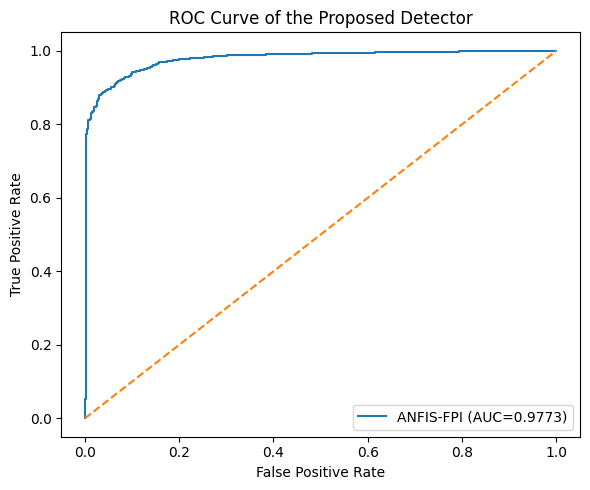

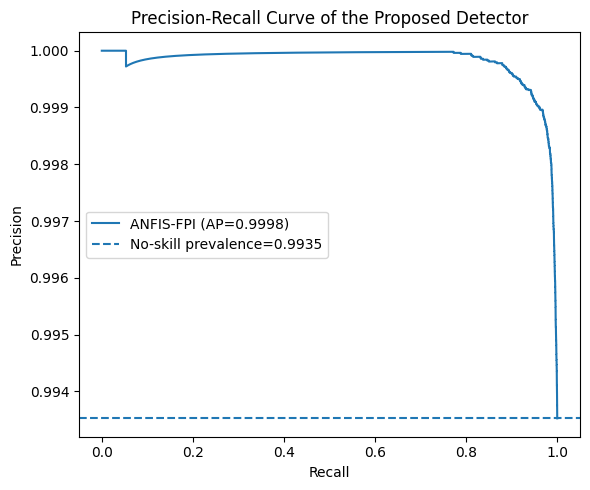

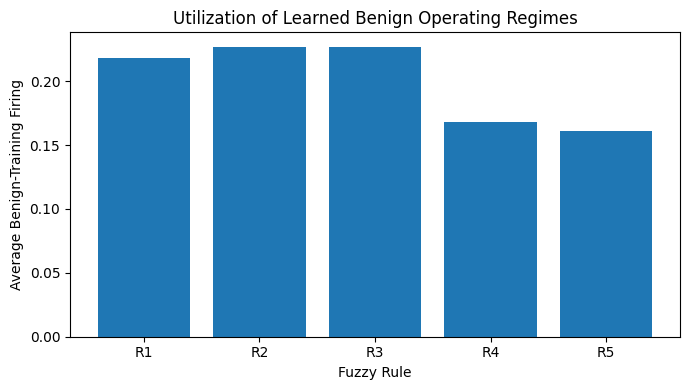

Saved figures:
/kaggle/working/revised_anfis_roc.pdf
/kaggle/working/revised_anfis_pr.pdf
/kaggle/working/revised_rule_utilization.pdf


In [43]:

fpr, tpr, _ = roc_curve(y_true_binary, proposed_test_scores)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ANFIS-FPI (AUC={roc_auc_score(y_true_binary, proposed_test_scores):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of the Proposed Detector")
plt.legend()
plt.tight_layout()
roc_path = OUTPUT_DIR / "revised_anfis_roc.pdf"
plt.savefig(roc_path, dpi=600, bbox_inches="tight")
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_true_binary, proposed_test_scores)
plt.figure(figsize=(6, 5))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"ANFIS-FPI (AP={average_precision_score(y_true_binary, proposed_test_scores):.4f})",
)
plt.axhline(
    y=float(y_true_binary.mean()),
    linestyle="--",
    label=f"No-skill prevalence={y_true_binary.mean():.4f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve of the Proposed Detector")
plt.legend()
plt.tight_layout()
pr_path = OUTPUT_DIR / "revised_anfis_pr.pdf"
plt.savefig(pr_path, dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar([f"R{rule + 1}" for rule in range(model.n_rules)], average_training_firing)
plt.xlabel("Fuzzy Rule")
plt.ylabel("Average Benign-Training Firing")
plt.title("Utilization of Learned Benign Operating Regimes")
plt.tight_layout()
rule_path = OUTPUT_DIR / "revised_rule_utilization.pdf"
plt.savefig(rule_path, dpi=600, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(roc_path)
print(pr_path)
print(rule_path)

In [44]:

import platform
import time


def fuzzy_probabilistic_scores_vectorized(
    X_np,
    firing_matrix,
    gaussians=rule_gaussians,
    top_k=N_TOP_RULES_FOR_SCORE,
):
    X64 = np.asarray(
        X_np,
        dtype=np.float64,
    )
    firing_matrix = np.asarray(
        firing_matrix,
        dtype=np.float64,
    )

    distances = np.column_stack([
        rule_mahalanobis_squared(
            X64,
            gaussian,
        )
        for gaussian in gaussians
    ])

    retained = min(
        int(top_k),
        len(gaussians),
    )

    selected_rules = np.argpartition(
        firing_matrix,
        kth=(
            firing_matrix.shape[1]
            - retained
        ),
        axis=1,
    )[
        :,
        -retained:
    ]

    selected_weights = np.take_along_axis(
        firing_matrix,
        selected_rules,
        axis=1,
    )

    selected_distances = np.take_along_axis(
        distances,
        selected_rules,
        axis=1,
    )

    log_components = (
        np.log(
            np.clip(
                selected_weights,
                1e-300,
                None,
            )
        )
        - 0.5
        * selected_distances
    )

    return -logsumexp(
        log_components,
        axis=1,
    )


verification_size = min(
    2000,
    len(X_test_np),
)

vectorized_verification = (
    fuzzy_probabilistic_scores_vectorized(
        X_test_np[
            :verification_size
        ],
        test_firing[
            :verification_size
        ],
    )
)

assert np.allclose(
    vectorized_verification,
    proposed_test_scores[
        :verification_size
    ],
    rtol=1e-10,
    atol=1e-10,
), (
    "The optimized vectorized score differs "
    "from the original score."
)


def synchronize_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


def proposed_full_forward_and_score(
    X_batch_np,
):
    batch_tensor = torch.tensor(
        X_batch_np,
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        _, batch_firing = model(
            batch_tensor
        )

    firing_np = (
        batch_firing
        .detach()
        .cpu()
        .numpy()
    )

    return (
        fuzzy_probabilistic_scores_vectorized(
            X_batch_np,
            firing_np,
        )
    )


def proposed_score_only(
    X_batch_np,
):
    batch_tensor = torch.tensor(
        X_batch_np,
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        batch_firing = (
            model.firing_strengths(
                batch_tensor
            )
        )

    firing_np = (
        batch_firing
        .detach()
        .cpu()
        .numpy()
    )

    return (
        fuzzy_probabilistic_scores_vectorized(
            X_batch_np,
            firing_np,
        )
    )


def dae_inference(
    X_batch_np,
):
    batch_tensor = torch.tensor(
        X_batch_np,
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        reconstruction, _ = (
            deep_autoencoder(
                batch_tensor
            )
        )

        scores = torch.mean(
            (
                reconstruction
                - batch_tensor
            ).square(),
            dim=1,
        )

    return (
        scores
        .detach()
        .cpu()
        .numpy()
    )


def svdd_inference(
    X_batch_np,
):
    batch_tensor = torch.tensor(
        X_batch_np,
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        representation = deep_svdd(
            batch_tensor
        )

        scores = torch.sum(
            (
                representation
                - svdd_center
            ).square(),
            dim=1,
        )

    return (
        scores
        .detach()
        .cpu()
        .numpy()
    )


def benchmark_callable(
    method_name,
    inference_function,
    X_batch_np,
    warmup_runs,
    measured_runs,
):
    for _ in range(warmup_runs):
        _ = inference_function(
            X_batch_np
        )

    synchronize_device()

    elapsed_seconds = []

    for _ in range(measured_runs):
        synchronize_device()
        start = time.perf_counter()

        _ = inference_function(
            X_batch_np
        )

        synchronize_device()
        elapsed_seconds.append(
            time.perf_counter()
            - start
        )

    elapsed_seconds = np.asarray(
        elapsed_seconds,
        dtype=np.float64,
    )

    batch_size = len(X_batch_np)
    median_batch_seconds = float(
        np.median(
            elapsed_seconds
        )
    )

    return {
        "Method": method_name,
        "Batch size": batch_size,
        "Median batch latency ms": (
            1000.0
            * median_batch_seconds
        ),
        "Median per-sample latency ms": (
            1000.0
            * median_batch_seconds
            / batch_size
        ),
        "P95 batch latency ms": (
            1000.0
            * np.quantile(
                elapsed_seconds,
                0.95,
            )
        ),
        "Throughput samples/s": (
            batch_size
            / median_batch_seconds
        ),
        "Measured runs": measured_runs,
    }


timing_methods = {
    "Proposed: full ANFIS forward + score": (
        proposed_full_forward_and_score
    ),
    "Proposed: firing-only optimized score": (
        proposed_score_only
    ),
    "Deep Autoencoder": dae_inference,
    "Deep SVDD": svdd_inference,
}

batch_sizes = [
    1,
    32,
    256,
    1024,
]

timing_rows = []

for batch_size in batch_sizes:
    effective_batch_size = min(
        batch_size,
        len(X_test_np),
    )

    X_batch_np = X_test_np[
        :effective_batch_size
    ]

    measured_runs = (
        100
        if effective_batch_size == 1
        else 30
    )

    for method_name, function in (
        timing_methods.items()
    ):
        timing_rows.append(
            benchmark_callable(
                method_name,
                function,
                X_batch_np,
                warmup_runs=5,
                measured_runs=measured_runs,
            )
        )

inference_timing_df = pd.DataFrame(
    timing_rows
)

model_size_rows = []

for model_name, torch_model in {
    "ANFIS reconstructor": model,
    "Deep Autoencoder": deep_autoencoder,
    "Deep SVDD": deep_svdd,
}.items():
    parameter_count = sum(
        parameter.numel()
        for parameter in (
            torch_model.parameters()
        )
    )

    trainable_parameter_count = sum(
        parameter.numel()
        for parameter in (
            torch_model.parameters()
        )
        if parameter.requires_grad
    )

    parameter_bytes = sum(
        parameter.numel()
        * parameter.element_size()
        for parameter in (
            torch_model.parameters()
        )
    )

    model_size_rows.append({
        "Model": model_name,
        "Parameters": parameter_count,
        "Trainable parameters": (
            trainable_parameter_count
        ),
        "Parameter memory MB": (
            parameter_bytes
            / (1024 ** 2)
        ),
    })

model_size_df = pd.DataFrame(
    model_size_rows
)

environment_df = pd.DataFrame([
    {
        "Python": platform.python_version(),
        "Platform": platform.platform(),
        "PyTorch": torch.__version__,
        "Device": str(DEVICE),
        "CUDA available": (
            torch.cuda.is_available()
        ),
        "CUDA device": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "N/A"
        ),
    }
])

print("Inference timing:")
print(
    inference_timing_df
    .round(6)
    .to_string(index=False)
)

print("\nModel size:")
print(
    model_size_df
    .round(6)
    .to_string(index=False)
)

print("\nEnvironment:")
print(
    environment_df.to_string(
        index=False
    )
)

timing_path = (
    OUTPUT_DIR
    / "inference_timing.csv"
)

model_size_path = (
    OUTPUT_DIR
    / "model_size.csv"
)

environment_path = (
    OUTPUT_DIR
    / "timing_environment.csv"
)

inference_timing_df.to_csv(
    timing_path,
    index=False,
)

model_size_df.to_csv(
    model_size_path,
    index=False,
)

environment_df.to_csv(
    environment_path,
    index=False,
)

print("\nSaved:", timing_path)
print("Saved:", model_size_path)
print("Saved:", environment_path)


Inference timing:
                               Method  Batch size  Median batch latency ms  Median per-sample latency ms  P95 batch latency ms  Throughput samples/s  Measured runs
 Proposed: full ANFIS forward + score           1                 0.801143                      0.801143              0.905993          1.248216e+03            100
Proposed: firing-only optimized score           1                 0.683994                      0.683994              0.727412          1.462001e+03            100
                     Deep Autoencoder           1                 0.112441                      0.112441              0.141695          8.893553e+03            100
                            Deep SVDD           1                 0.068779                      0.068779              0.089093          1.453932e+04            100
 Proposed: full ANFIS forward + score          32                 5.503091                      0.171972              5.881952          5.814914e+03             3